SECTION 0 — Imports + Global Settings

In [20]:
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt


In [21]:
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


SECTION 1 — Load Panels + Cleaning

In [22]:
PANEL_DIR = Path(r"D:\Thesis\Old\Codes\New\panel_data")

panel_return = pd.read_parquet(PANEL_DIR / "panel_return.parquet").sort_index()
panel_risk   = pd.read_parquet(PANEL_DIR / "panel_risk.parquet").sort_index()

def clean_return_panel(panel: pd.DataFrame) -> pd.DataFrame:
    panel = panel.copy()
    panel = panel.dropna(subset=["y"])
    feat_cols = [c for c in panel.columns if c != "y"]
    panel[feat_cols] = (
        panel[feat_cols]
        .groupby(level="Ticker", group_keys=False)
        .apply(lambda df: df.ffill())
    )
    panel = panel.dropna()
    return panel

def clean_risk_panel(panel: pd.DataFrame) -> pd.DataFrame:
    return panel.dropna().copy()

panel_return_clean = clean_return_panel(panel_return)
panel_risk_clean   = clean_risk_panel(panel_risk)

print("panel_return_clean:", panel_return_clean.shape)
print("panel_risk_clean  :", panel_risk_clean.shape)


panel_return_clean: (220653, 15)
panel_risk_clean  : (236800, 6)


SECTION 2 — CV Fold Generator by Date

✅ Primary: Expanding window CV (5 folds)

✅ Secondary: Rolling window CV (5 folds)

In [23]:
def get_unique_dates(panel):
    return np.array(sorted(panel.index.get_level_values("Date").unique()))

def expanding_window_folds(panel, n_splits=5, min_train_frac=0.6):
    dates = get_unique_dates(panel)
    n_dates = len(dates)
    min_train = int(n_dates * min_train_frac)

    step = (n_dates - min_train) // n_splits
    folds = []
    for k in range(n_splits):
        train_end = min_train + k * step
        test_end  = min_train + (k + 1) * step
        train_dates = dates[:train_end]
        test_dates  = dates[train_end:test_end]
        if len(test_dates) == 0:
            continue
        folds.append((train_dates, test_dates))
    return folds


def rolling_window_folds(panel, n_splits=5, train_window_frac=0.4):
    dates = get_unique_dates(panel)
    n_dates = len(dates)
    train_window = int(n_dates * train_window_frac)

    step = (n_dates - train_window) // n_splits
    folds = []

    for k in range(n_splits):
        train_start = k * step
        train_end   = train_start + train_window
        test_end    = train_end + step

        train_dates = dates[train_start:train_end]
        test_dates  = dates[train_end:test_end]

        if len(test_dates) == 0:
            continue

        folds.append((train_dates, test_dates))
    return folds

def slice_by_dates(panel, train_dates, test_dates):
    idx_dates = panel.index.get_level_values("Date")
    train = panel.loc[idx_dates.isin(train_dates)].copy()
    test  = panel.loc[idx_dates.isin(test_dates)].copy()
    return train, test


SECTION 3 — Tensor Builders + Scaling (Tabular + Sequence)

In [24]:
def make_tabular_tensors(train: pd.DataFrame, test: pd.DataFrame):
    X_train = train.drop(columns=["y"]).astype(float).values
    y_train = train["y"].astype(float).values
    X_test  = test.drop(columns=["y"]).astype(float).values
    y_test  = test["y"].astype(float).values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, y_train, X_test, y_test

def make_sequence_tensors(train: pd.DataFrame, test: pd.DataFrame, lookback=20):
    feat_cols = [c for c in train.columns if c != "y"]

    def build(panel):
        Xs, ys = [], []
        for ticker, df in panel.groupby(level="Ticker"):
            df = df.droplevel("Ticker").sort_index()
            Xv = df[feat_cols].values.astype(float)
            yv = df["y"].values.astype(float)

            if len(df) <= lookback:
                continue

            for i in range(lookback, len(df)):
                Xs.append(Xv[i-lookback:i])
                ys.append(yv[i])

        return np.array(Xs), np.array(ys)

    Xtr, ytr = build(train)
    Xte, yte = build(test)

    n_feat = Xtr.shape[-1]
    scaler = StandardScaler()

    Xtr = scaler.fit_transform(Xtr.reshape(-1, n_feat)).reshape(-1, lookback, n_feat)
    Xte = scaler.transform(Xte.reshape(-1, n_feat)).reshape(-1, lookback, n_feat)

    return Xtr, ytr, Xte, yte


SECTION 4 — Training + Curves (per fold)

In [25]:
def fit_keras_model(model, X_train, y_train, X_val, y_val,
                    epochs=50, batch_size=1024, patience=5, verbose=0):
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose
    )
    return hist

def plot_fold_curve(history, title):
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.ylim(0, 0.05)  # adjust after seeing typical scale
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()



SECTION 5 — Generic CV Runner (Expanding primary / Rolling robustness)

This runs:

build tensors

split train fold into train/val (last 10% of fold = validation)

fit model

compute test RMSE

plot curves per fold

In [26]:
def run_dl_cv(panel_clean, model_name, build_fn,
              scheme="expanding", n_splits=5,
              data_mode="tabular", lookback=20,
              epochs=50, batch_size=1024, patience=5,
              seed=42, plot_curves=True):

    set_seed(seed)

    if scheme == "expanding":
        folds = expanding_window_folds(panel_clean, n_splits=n_splits)
    elif scheme == "rolling":
        folds = rolling_window_folds(panel_clean, n_splits=n_splits)
    else:
        raise ValueError("scheme must be 'expanding' or 'rolling'")

    fold_results = []

    for i, (train_dates, test_dates) in enumerate(folds, start=1):
        train_fold, test_fold = slice_by_dates(panel_clean, train_dates, test_dates)

        # build tensors
        if data_mode == "tabular":
            Xtr, ytr, Xte, yte = make_tabular_tensors(train_fold, test_fold)
        else:
            Xtr, ytr, Xte, yte = make_sequence_tensors(train_fold, test_fold, lookback=lookback)

        # train/val split inside train fold
        n = len(Xtr)
        cut = int(n * 0.9)
        X_train, y_train = Xtr[:cut], ytr[:cut]
        X_val,   y_val   = Xtr[cut:], ytr[cut:]

        # build & train
        model = build_fn(input_shape=X_train.shape[1:])
        hist = fit_keras_model(model, X_train, y_train, X_val, y_val,
                               epochs=epochs, batch_size=batch_size, patience=patience, verbose=0)

        # evaluate on test fold
        pred = model.predict(Xte, verbose=0).ravel()
        fold_rmse = rmse(yte, pred)

        fold_results.append({"fold": i, "rmse": fold_rmse, "n_train": len(X_train), "n_test": len(Xte)})

        if plot_curves:
            plot_fold_curve(hist, f"{model_name} | {scheme.upper()} | Fold {i} | RMSE={fold_rmse:.6f}")

        print(f"[{model_name}][{scheme}] fold {i}/{len(folds)} RMSE={fold_rmse:.6f}")

    df = pd.DataFrame(fold_results)
    print("\nSummary:", model_name, scheme)
    print(df)
    print("Mean RMSE:", df["rmse"].mean(), "Std RMSE:", df["rmse"].std())
    return df


**SECTION 6 — Model Builders (8 DL models)**

6.1 MLP/DNN

In [27]:
def build_mlp(input_shape, hidden=(64,32), dropout=0.2, lr=1e-3):
    input_dim = input_shape[0]
    model = keras.Sequential([layers.Input((input_dim,))])
    for h in hidden:
        model.add(layers.Dense(h, activation="relu"))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


6.2 LSTM

In [37]:
def build_lstm(input_shape, units=64, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(input_shape),
        layers.LSTM(units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


6.3 GRU

In [29]:
def build_gru(input_shape, units=64, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(input_shape),
        layers.GRU(units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


6.4 1D-CNN

In [30]:
def build_cnn1d(input_shape, filters=32, kernel_size=3, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(input_shape),
        layers.Conv1D(filters, kernel_size, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


6.5 Transformer/Attention

In [31]:
def build_transformer(input_shape, heads=2, key_dim=16, ff=64, dropout=0.1, lr=1e-3):
    inp = layers.Input(shape=input_shape)
    x = layers.LayerNormalization()(inp)
    x = layers.MultiHeadAttention(num_heads=heads, key_dim=key_dim, dropout=dropout)(x, x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(ff, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


6.6 BNN (MC Dropout Approximation)

In [32]:
def build_bnn_mc_dropout(input_shape, hidden=(64,32), dropout=0.3, lr=1e-3):
    input_dim = input_shape[0]
    inp = layers.Input((input_dim,))
    x = inp
    for h in hidden:
        x = layers.Dense(h, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


6.7 AE / VAE (Feature learning — evaluated as downstream Ridge)

(We’ll implement this as a separate runnable section next, because it has 2 stages.)

6.7 AE / VAE (Feature learning — evaluated as downstream Ridge)

(We’ll implement this as a separate runnable section next, because it has 2 stages.)

**SECTION 7 — Hyperparameter tuning “lists” (small, not huge)**

In [33]:
MLP_GRID = [
    lambda input_shape: build_mlp(input_shape, hidden=(64,32), dropout=0.2, lr=1e-3),
    lambda input_shape: build_mlp(input_shape, hidden=(128,64), dropout=0.3, lr=1e-3),
    lambda input_shape: build_mlp(input_shape, hidden=(64,64,32), dropout=0.2, lr=5e-4),
]

LSTM_GRID = [
    lambda input_shape: build_lstm(input_shape, units=32, dropout=0.2, lr=1e-3),
    lambda input_shape: build_lstm(input_shape, units=64, dropout=0.2, lr=1e-3),
    lambda input_shape: build_lstm(input_shape, units=64, dropout=0.3, lr=5e-4),
]

GRU_GRID = [
    lambda input_shape: build_gru(input_shape, units=32, dropout=0.2, lr=1e-3),
    lambda input_shape: build_gru(input_shape, units=64, dropout=0.2, lr=1e-3),
    lambda input_shape: build_gru(input_shape, units=64, dropout=0.3, lr=5e-4),
]

CNN_GRID = [
    lambda input_shape: build_cnn1d(input_shape, filters=16, kernel_size=3, dropout=0.2, lr=1e-3),
    lambda input_shape: build_cnn1d(input_shape, filters=32, kernel_size=5, dropout=0.3, lr=1e-3),
]

TRF_GRID = [
    lambda input_shape: build_transformer(input_shape, heads=2, key_dim=16, ff=64, dropout=0.1, lr=1e-3),
    lambda input_shape: build_transformer(input_shape, heads=4, key_dim=16, ff=128, dropout=0.1, lr=5e-4),
]

BNN_GRID = [
    lambda input_shape: build_bnn_mc_dropout(input_shape, hidden=(64,32), dropout=0.3, lr=1e-3),
    lambda input_shape: build_bnn_mc_dropout(input_shape, hidden=(128,64), dropout=0.4, lr=1e-3),
]


SECTION 8 — Run Expanding CV (PRIMARY) with curves


MLP config 1


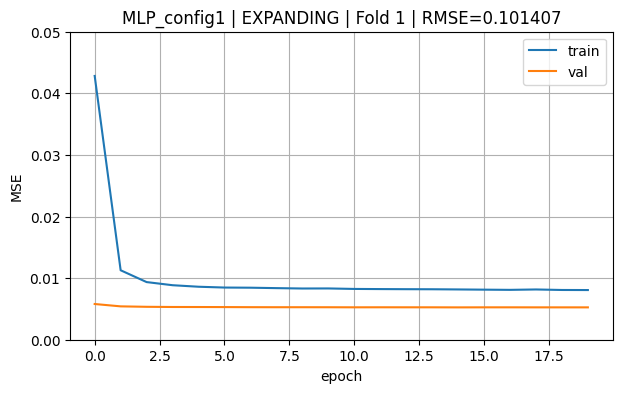

[MLP_config1][expanding] fold 1/5 RMSE=0.101407


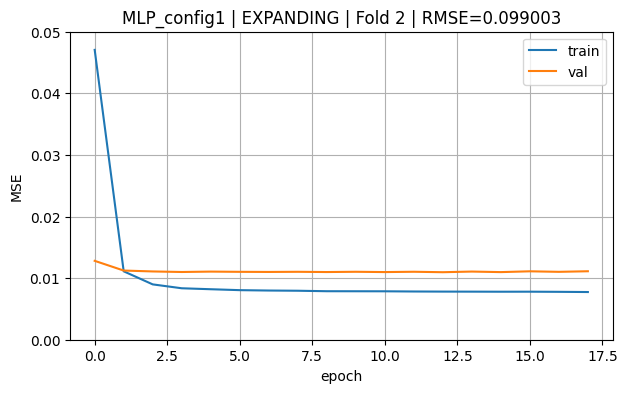

[MLP_config1][expanding] fold 2/5 RMSE=0.099003


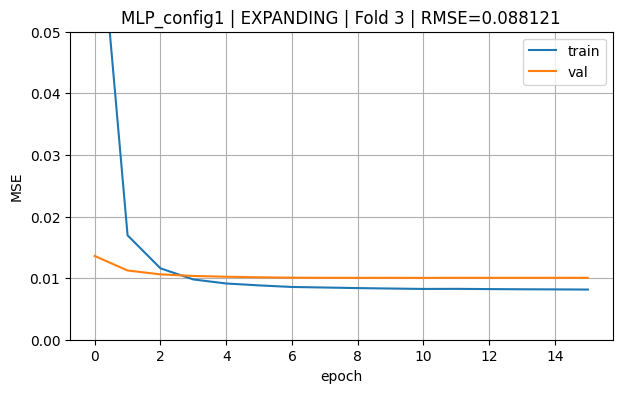

[MLP_config1][expanding] fold 3/5 RMSE=0.088121


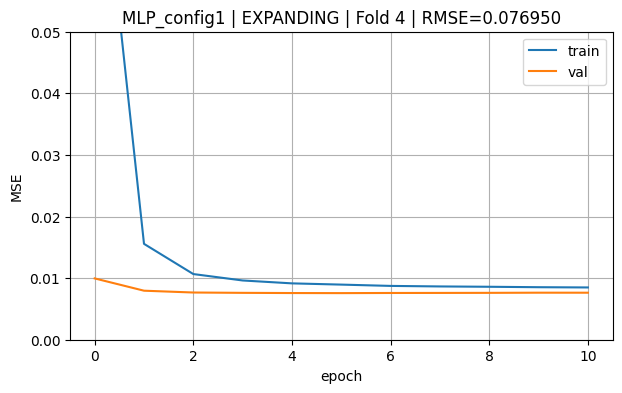

[MLP_config1][expanding] fold 4/5 RMSE=0.076950


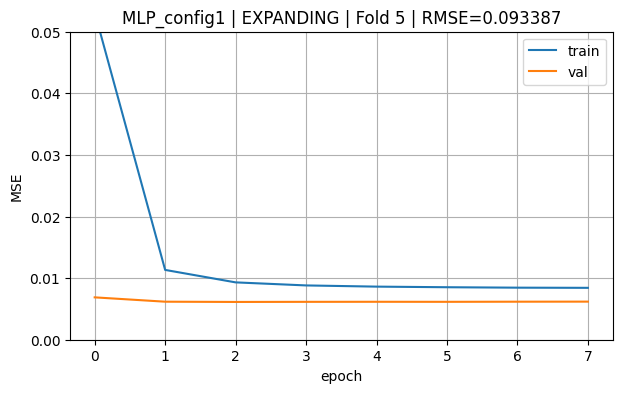

[MLP_config1][expanding] fold 5/5 RMSE=0.093387

Summary: MLP_config1 expanding
   fold      rmse  n_train  n_test
0     1  0.101407   118400   17721
1     2  0.099003   134349   17721
2     3  0.088121   150298   17721
3     4  0.076950   166247   17834
4     5  0.093387   182297   17900
Mean RMSE: 0.09177356996825384 Std RMSE: 0.00975621590964569

MLP config 2


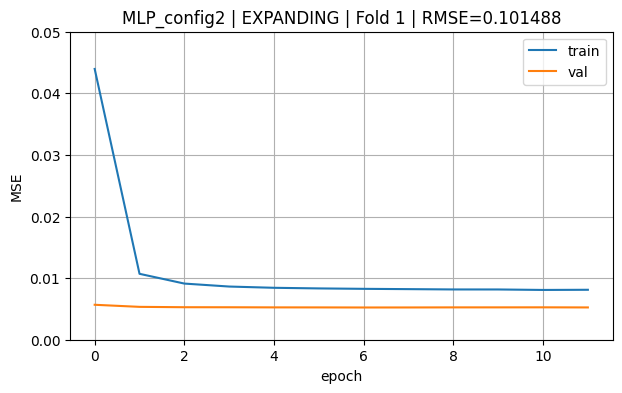

[MLP_config2][expanding] fold 1/5 RMSE=0.101488


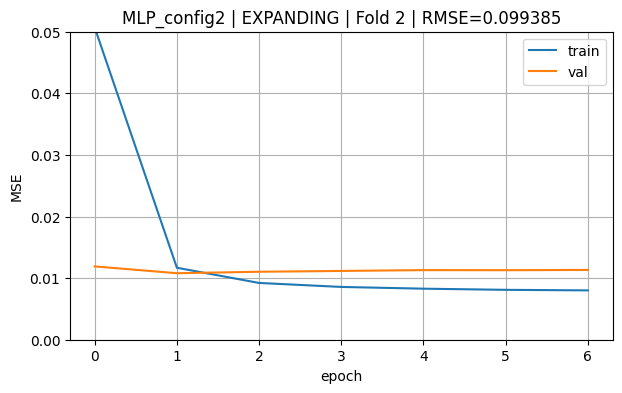

[MLP_config2][expanding] fold 2/5 RMSE=0.099385


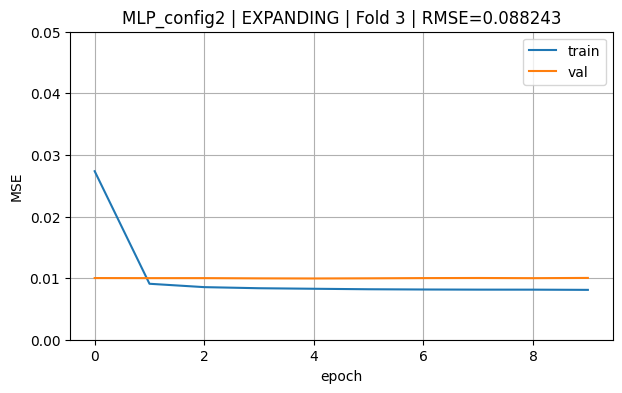

[MLP_config2][expanding] fold 3/5 RMSE=0.088243


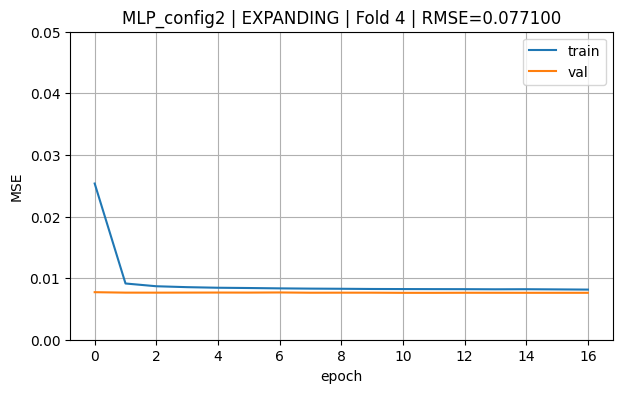

[MLP_config2][expanding] fold 4/5 RMSE=0.077100


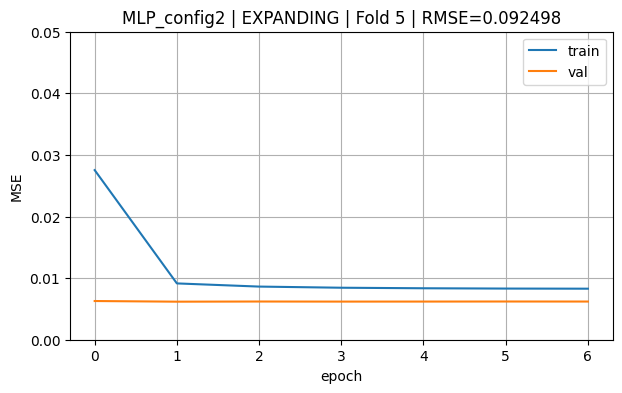

[MLP_config2][expanding] fold 5/5 RMSE=0.092498

Summary: MLP_config2 expanding
   fold      rmse  n_train  n_test
0     1  0.101488   118400   17721
1     2  0.099385   134349   17721
2     3  0.088243   150298   17721
3     4  0.077100   166247   17834
4     5  0.092498   182297   17900
Mean RMSE: 0.09174268340791672 Std RMSE: 0.009754565031518886

MLP config 3


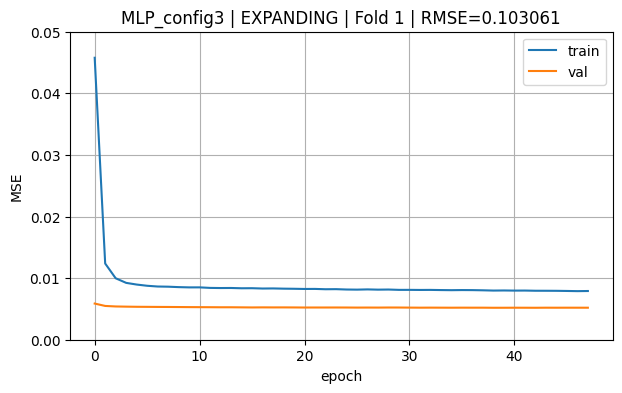

[MLP_config3][expanding] fold 1/5 RMSE=0.103061


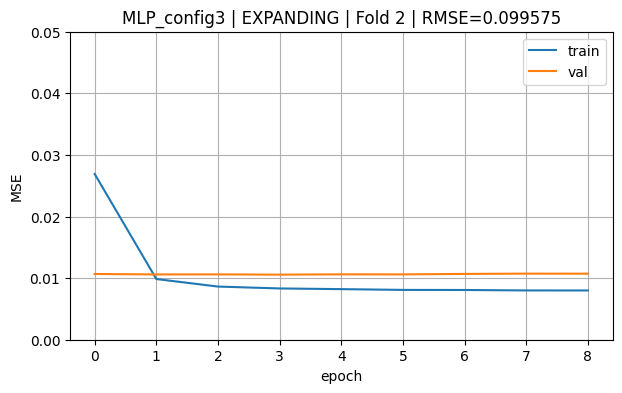

[MLP_config3][expanding] fold 2/5 RMSE=0.099575


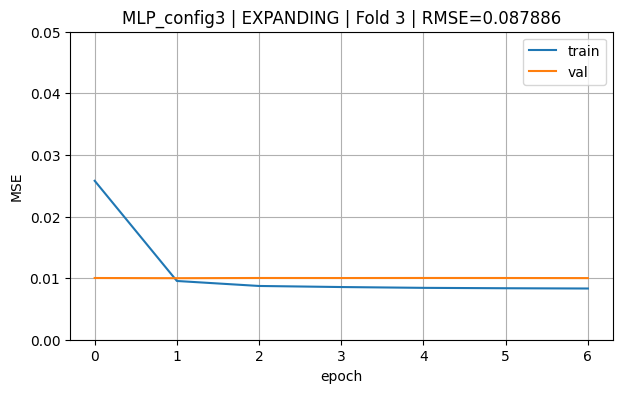

[MLP_config3][expanding] fold 3/5 RMSE=0.087886


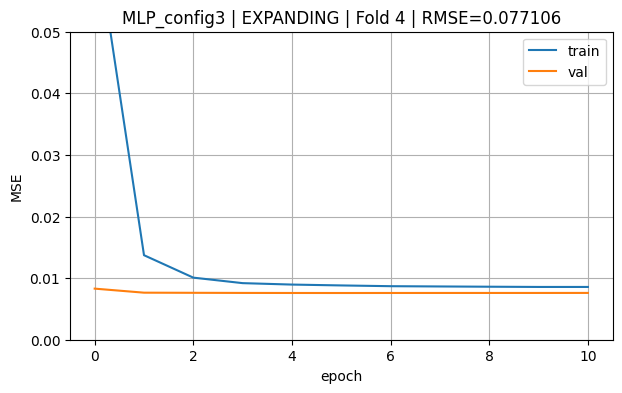

[MLP_config3][expanding] fold 4/5 RMSE=0.077106


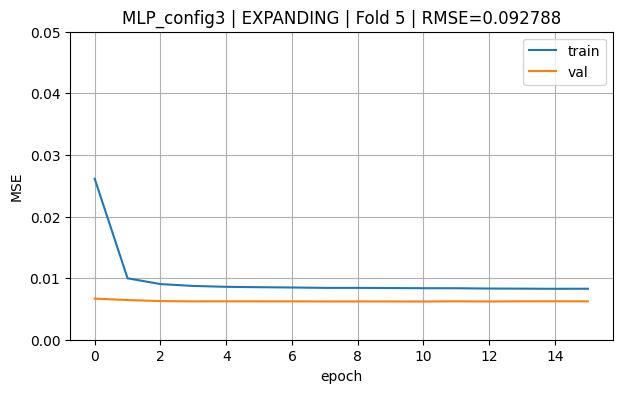

[MLP_config3][expanding] fold 5/5 RMSE=0.092788

Summary: MLP_config3 expanding
   fold      rmse  n_train  n_test
0     1  0.103061   118400   17721
1     2  0.099575   134349   17721
2     3  0.087886   150298   17721
3     4  0.077106   166247   17834
4     5  0.092788   182297   17900
Mean RMSE: 0.09208306193538163 Std RMSE: 0.010235413531052636


,config,mean_rmse,std_rmse
1,2,0.091743,0.009755
0,1,0.091774,0.009756
2,3,0.092083,0.010235


In [34]:
folds = []
for j, builder in enumerate(MLP_GRID, start=1):
    print("\n=======================")
    print(f"MLP config {j}")
    print("=======================")

    df = run_dl_cv(
        panel_return_clean,
        model_name=f"MLP_config{j}",
        build_fn=builder,
        scheme="expanding",
        n_splits=5,
        data_mode="tabular",
        epochs=50,
        batch_size=1024,
        patience=5,
        plot_curves=True
    )
    folds.append((j, df["rmse"].mean(), df["rmse"].std()))
    
pd.DataFrame(folds, columns=["config","mean_rmse","std_rmse"]).sort_values("mean_rmse")


SECTION 9 — Run Rolling CV (SECONDARY robustness check)

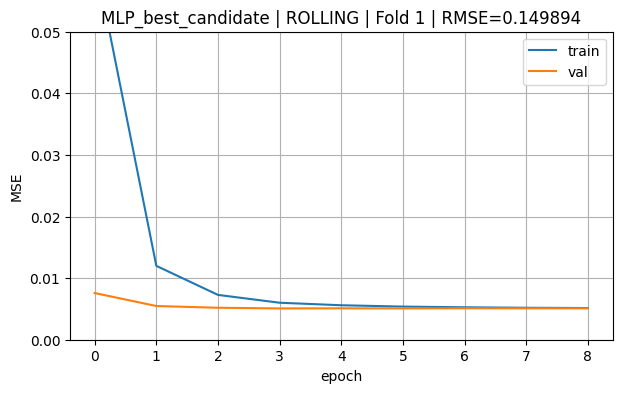

[MLP_best_candidate][rolling] fold 1/5 RMSE=0.149894


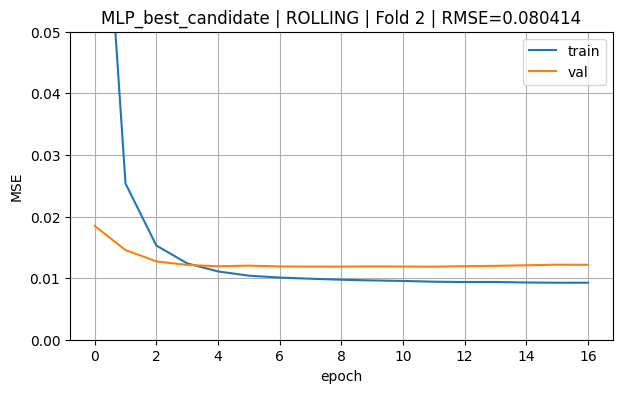

[MLP_best_candidate][rolling] fold 2/5 RMSE=0.080414


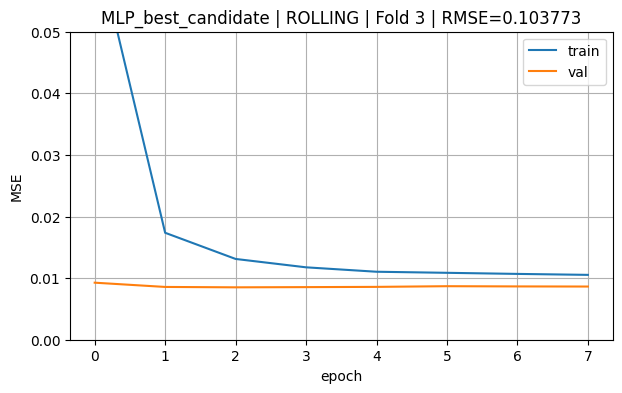

[MLP_best_candidate][rolling] fold 3/5 RMSE=0.103773


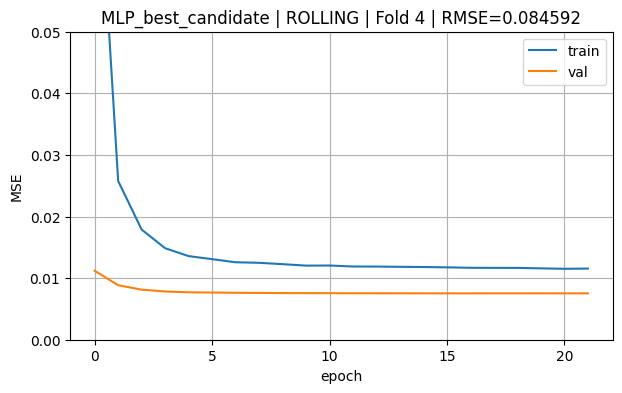

[MLP_best_candidate][rolling] fold 4/5 RMSE=0.084592


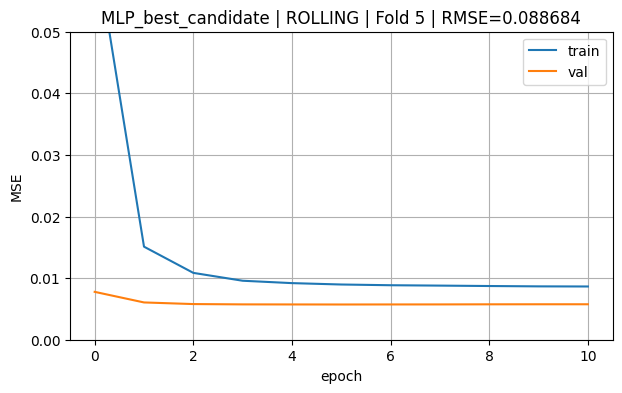

[MLP_best_candidate][rolling] fold 5/5 RMSE=0.088684

Summary: MLP_best_candidate rolling
   fold      rmse  n_train  n_test
0     1  0.149894    78685   26407
1     2  0.080414    78967   26631
2     3  0.103773    79309   26631
3     4  0.084592    79551   26656
4     5  0.088684    79816   26900
Mean RMSE: 0.10147145675125917 Std RMSE: 0.028468837934142132


In [35]:
df_robust = run_dl_cv(
    panel_return_clean,
    model_name="MLP_best_candidate",
    build_fn=MLP_GRID[0],     # replace with winner config
    scheme="rolling",
    n_splits=5,
    data_mode="tabular",
    epochs=50,
    batch_size=1024,
    patience=5,
    plot_curves=True
)


Risk:


MLP RISK config 1


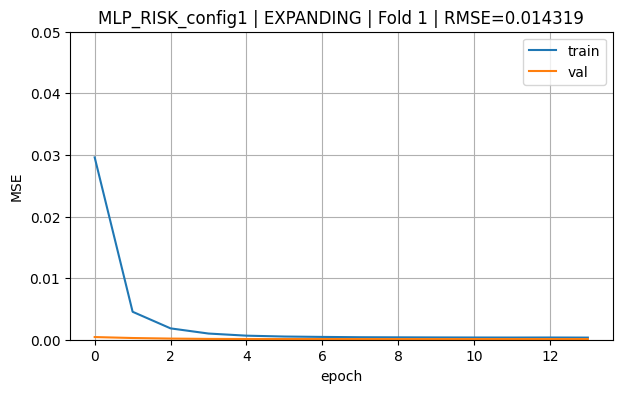

[MLP_RISK_config1][expanding] fold 1/5 RMSE=0.014319


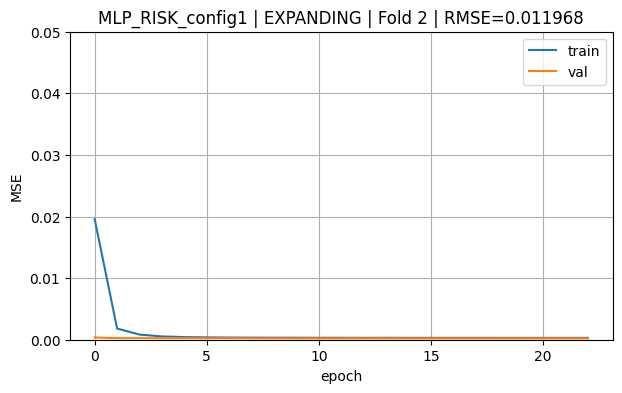

[MLP_RISK_config1][expanding] fold 2/5 RMSE=0.011968


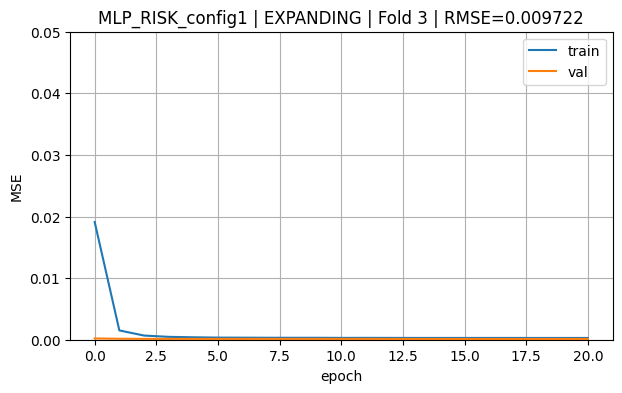

[MLP_RISK_config1][expanding] fold 3/5 RMSE=0.009722


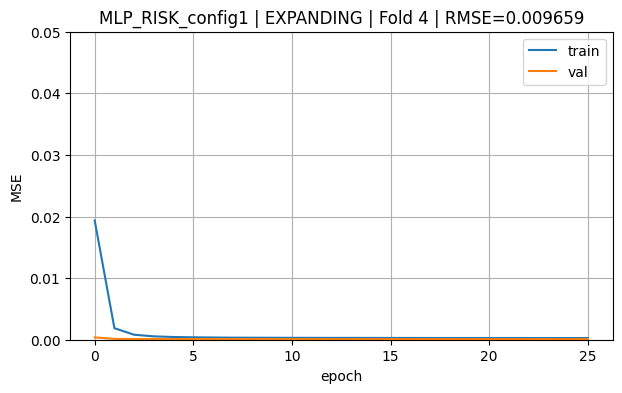

[MLP_RISK_config1][expanding] fold 4/5 RMSE=0.009659


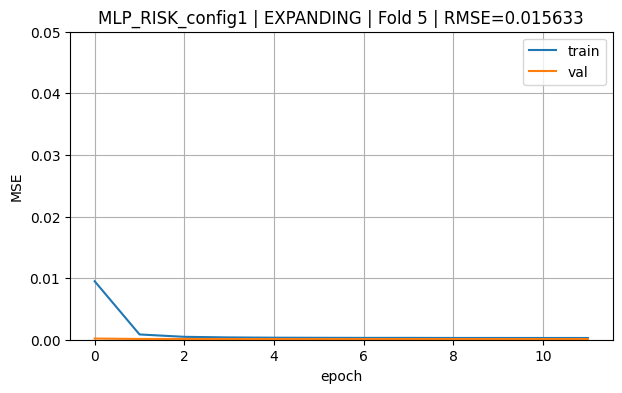

[MLP_RISK_config1][expanding] fold 5/5 RMSE=0.015633

Summary: MLP_RISK_config1 expanding
   fold      rmse  n_train  n_test
0     1  0.014319   127800   18900
1     2  0.011968   144810   18900
2     3  0.009722   161820   18900
3     4  0.009659   178830   18900
4     5  0.015633   195840   18900
Mean RMSE: 0.0122601646203041 Std RMSE: 0.0026879984020710896

MLP RISK config 2


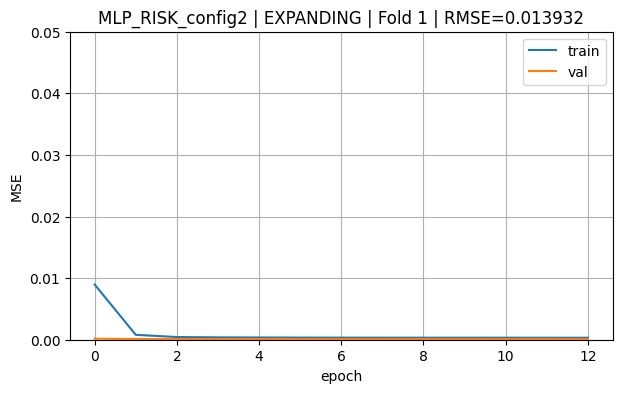

[MLP_RISK_config2][expanding] fold 1/5 RMSE=0.013932


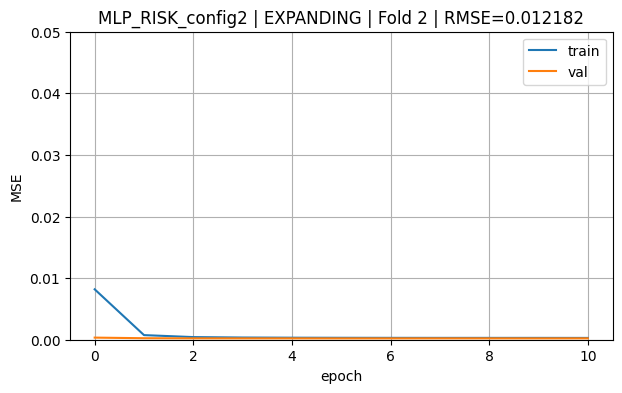

[MLP_RISK_config2][expanding] fold 2/5 RMSE=0.012182


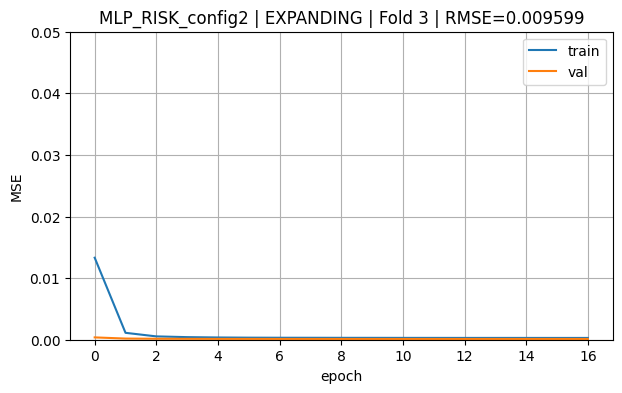

[MLP_RISK_config2][expanding] fold 3/5 RMSE=0.009599


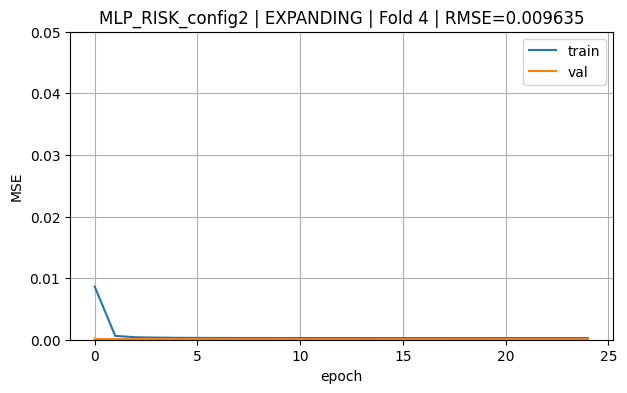

[MLP_RISK_config2][expanding] fold 4/5 RMSE=0.009635


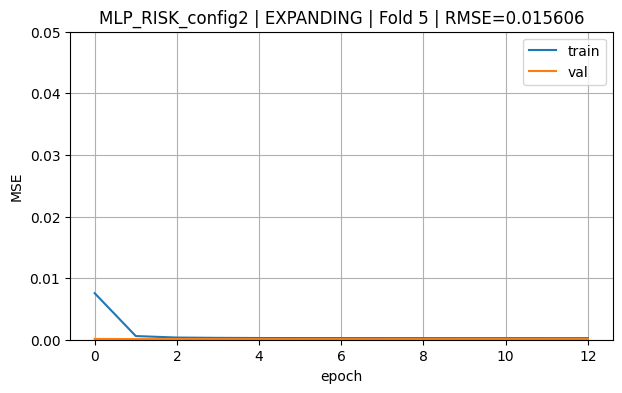

[MLP_RISK_config2][expanding] fold 5/5 RMSE=0.015606

Summary: MLP_RISK_config2 expanding
   fold      rmse  n_train  n_test
0     1  0.013932   127800   18900
1     2  0.012182   144810   18900
2     3  0.009599   161820   18900
3     4  0.009635   178830   18900
4     5  0.015606   195840   18900
Mean RMSE: 0.012190752382716025 Std RMSE: 0.0026430594743603055

MLP RISK config 3


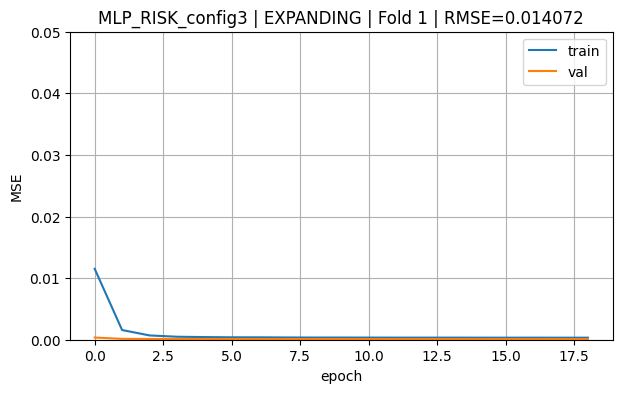

[MLP_RISK_config3][expanding] fold 1/5 RMSE=0.014072


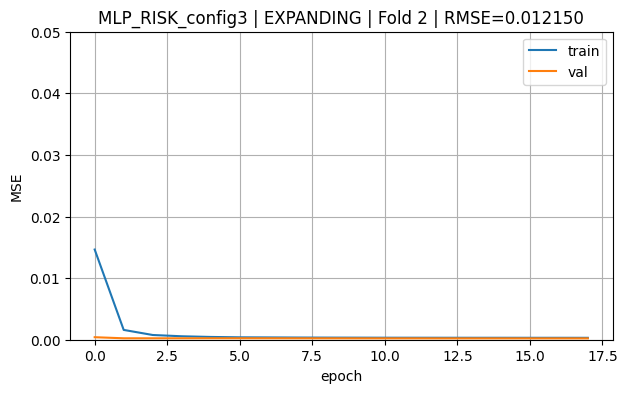

[MLP_RISK_config3][expanding] fold 2/5 RMSE=0.012150


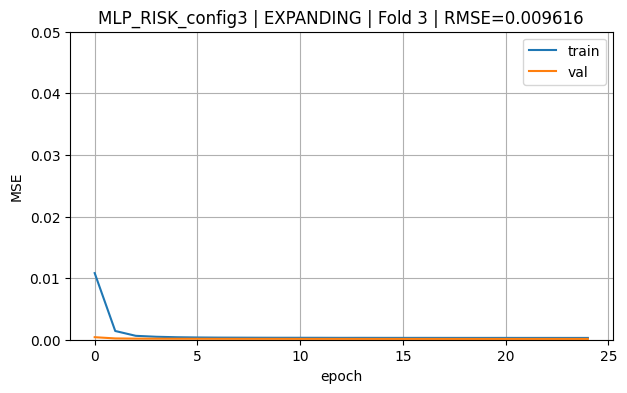

[MLP_RISK_config3][expanding] fold 3/5 RMSE=0.009616


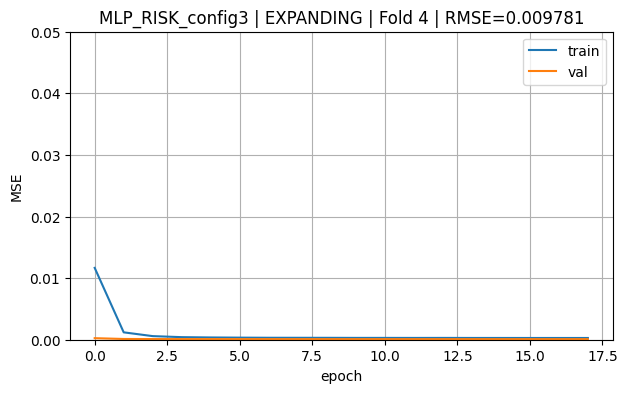

[MLP_RISK_config3][expanding] fold 4/5 RMSE=0.009781


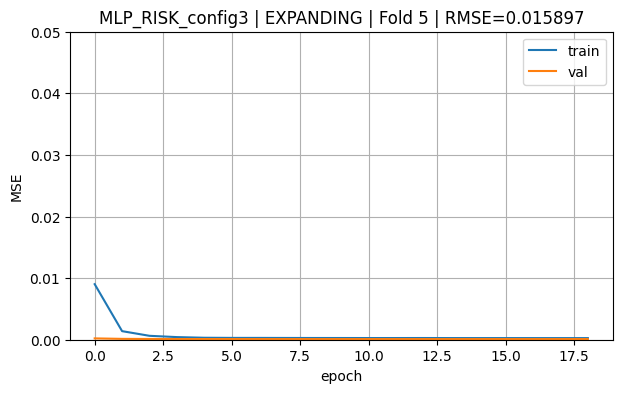

[MLP_RISK_config3][expanding] fold 5/5 RMSE=0.015897

Summary: MLP_RISK_config3 expanding
   fold      rmse  n_train  n_test
0     1  0.014072   127800   18900
1     2  0.012150   144810   18900
2     3  0.009616   161820   18900
3     4  0.009781   178830   18900
4     5  0.015897   195840   18900
Mean RMSE: 0.012303378267643252 Std RMSE: 0.002722727156317718

=== MLP Risk Tuning Summary (Expanding CV) ===


,config,mean_rmse,std_rmse
1,2,0.012191,0.002643
0,1,0.012260,0.002688
2,3,0.012303,0.002723


In [50]:
# =========================
# MLP tuning on RISK / CVaR (PRIMARY: Expanding CV)
# =========================

mlp_risk_results = []

for j, builder in enumerate(MLP_GRID, start=1):
    print("\n" + "="*80)
    print(f"MLP RISK config {j}")
    print("="*80)

    df = run_dl_cv(
        panel_risk_clean,
        model_name=f"MLP_RISK_config{j}",
        build_fn=builder,
        scheme="expanding",
        n_splits=5,
        data_mode="tabular",     # MLP uses tabular
        epochs=50,
        batch_size=1024,
        patience=5,
        plot_curves=True
    )

    mlp_risk_results.append({
        "config": j,
        "mean_rmse": df["rmse"].mean(),
        "std_rmse": df["rmse"].std()
    })

mlp_risk_summary = pd.DataFrame(mlp_risk_results).sort_values("mean_rmse")
print("\n=== MLP Risk Tuning Summary (Expanding CV) ===")
display(mlp_risk_summary)


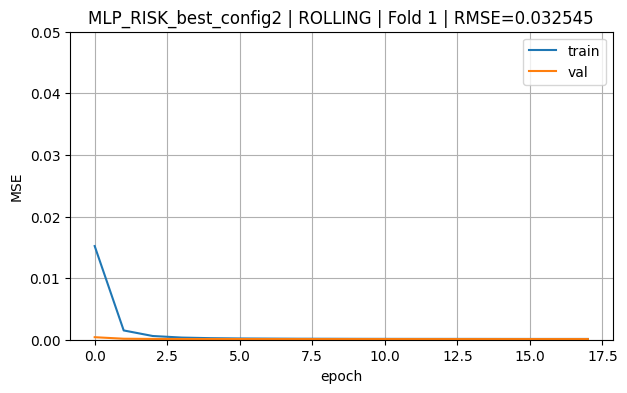

[MLP_RISK_best_config2][rolling] fold 1/5 RMSE=0.032545


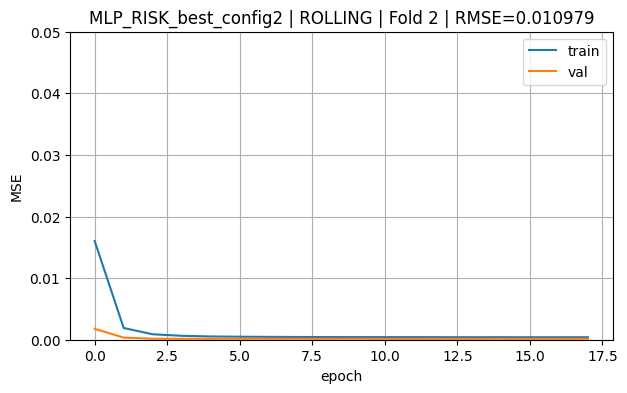

[MLP_RISK_best_config2][rolling] fold 2/5 RMSE=0.010979


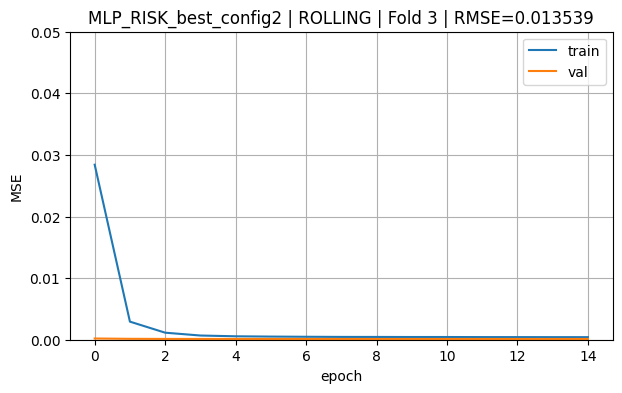

[MLP_RISK_best_config2][rolling] fold 3/5 RMSE=0.013539


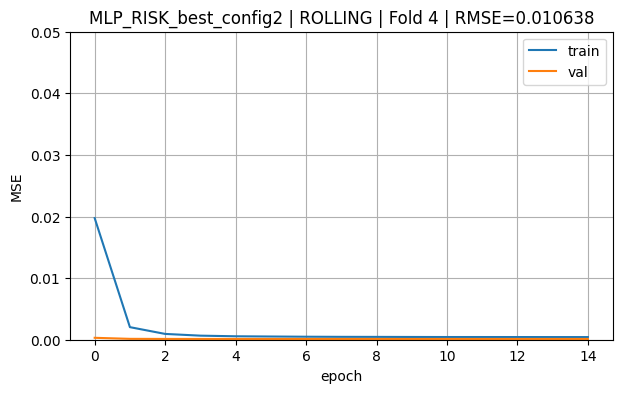

[MLP_RISK_best_config2][rolling] fold 4/5 RMSE=0.010638


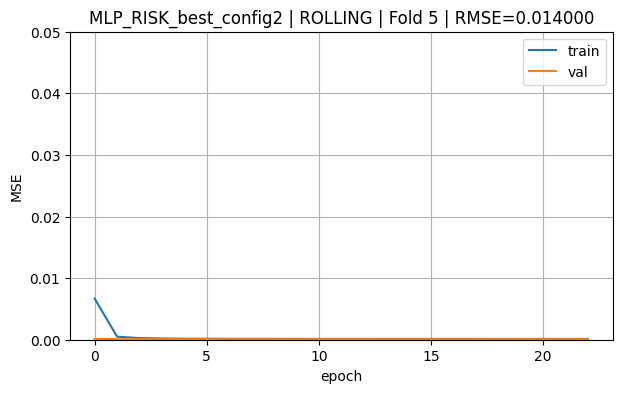

[MLP_RISK_best_config2][rolling] fold 5/5 RMSE=0.014000

Summary: MLP_RISK_best_config2 rolling
   fold      rmse  n_train  n_test
0     1  0.032545    85230   28400
1     2  0.010979    85230   28400
2     3  0.013539    85230   28400
3     4  0.010638    85230   28400
4     5  0.014000    85230   28400
Mean RMSE: 0.01634005598035885 Std RMSE: 0.009181029747342119

Rolling CV Mean RMSE: 0.01634005598035885 Std RMSE: 0.009181029747342119


In [51]:
# =========================
# MLP risk robustness (SECONDARY: Rolling CV) using best config
# =========================

best_cfg_id = int(mlp_risk_summary.iloc[0]["config"])
best_builder = MLP_GRID[best_cfg_id - 1]

df_mlp_risk_rolling = run_dl_cv(
    panel_risk_clean,
    model_name=f"MLP_RISK_best_config{best_cfg_id}",
    build_fn=best_builder,
    scheme="rolling",
    n_splits=5,
    data_mode="tabular",
    epochs=50,
    batch_size=1024,
    patience=5,
    plot_curves=True
)

print("\nRolling CV Mean RMSE:", df_mlp_risk_rolling["rmse"].mean(),
      "Std RMSE:", df_mlp_risk_rolling["rmse"].std())


**2. LSTM**

LSTM model builder

In [38]:
# =========================
# LSTM: model builder
# =========================
def build_lstm_model(input_shape, units=64, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model


Train/Evaluate one fold + curve

In [40]:
# =========================
# LSTM: train one fold + training curve
# =========================
def fit_lstm_one_fold(
    Xtr, ytr, Xte, yte,
    units=64, dropout=0.2, lr=1e-3,
    epochs=50, batch_size=512, patience=5,
    seed=42, verbose=0,
    plot=True, title=""
):
    set_seed(seed)

    # fold-internal train/val split (last 10% = val)
    n = len(Xtr)
    cut = int(n * 0.9)
    X_train, y_train = Xtr[:cut], ytr[:cut]
    X_val,   y_val   = Xtr[cut:], ytr[cut:]

    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=units,
        dropout=dropout,
        lr=lr
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose
    )

    pred = model.predict(Xte, verbose=0).ravel()
    fold_rmse = rmse(yte, pred)

    if plot:
        plot_fold_curve(hist, f"{title} | RMSE={fold_rmse:.6f}")

    return fold_rmse


Run LSTM CV (Expanding primary / Rolling secondary)

In [41]:
# =========================
# LSTM: run CV on a panel
# scheme: "expanding" (PRIMARY) or "rolling" (ROBUSTNESS)
# =========================
def run_lstm_cv(
    panel_clean,
    scheme="expanding",
    n_splits=5,
    lookback=20,
    units=64, dropout=0.2, lr=1e-3,
    epochs=50, batch_size=512, patience=5,
    seed=42,
    plot_curves=True
):
    # choose fold scheme
    if scheme == "expanding":
        folds = expanding_window_folds(panel_clean, n_splits=n_splits)  # uses your fixed min_train_frac=0.6
    elif scheme == "rolling":
        folds = rolling_window_folds(panel_clean, n_splits=n_splits)
    else:
        raise ValueError("scheme must be 'expanding' or 'rolling'")

    fold_rows = []

    for k, (train_dates, test_dates) in enumerate(folds, start=1):
        train_fold, test_fold = slice_by_dates(panel_clean, train_dates, test_dates)

        # sequence tensors PER FOLD (scaling is inside make_sequence_tensors)
        Xtr, ytr, Xte, yte = make_sequence_tensors(train_fold, test_fold, lookback=lookback)

        fold_rmse = fit_lstm_one_fold(
            Xtr, ytr, Xte, yte,
            units=units, dropout=dropout, lr=lr,
            epochs=epochs, batch_size=batch_size, patience=patience,
            seed=seed,
            verbose=0,
            plot=plot_curves,
            title=f"LSTM | {scheme.upper()} | Fold {k} | lookback={lookback}, units={units}, drop={dropout}, lr={lr}"
        )

        fold_rows.append({
            "fold": k,
            "rmse": fold_rmse,
            "n_train": len(Xtr),
            "n_test": len(Xte)
        })

        print(f"[LSTM][{scheme}] fold {k}/{len(folds)} RMSE={fold_rmse:.6f}")

    df = pd.DataFrame(fold_rows)
    print("\nSummary: LSTM", scheme)
    display(df)
    print("Mean RMSE:", df["rmse"].mean(), "Std RMSE:", df["rmse"].std())
    return df


Hyperparameter tuning grid (small, clean)

In [42]:
# =========================
# LSTM tuning grid (small, practical)
# =========================
LSTM_GRID = [
    {"lookback": 20, "units": 32, "dropout": 0.2, "lr": 1e-3},
    {"lookback": 20, "units": 64, "dropout": 0.2, "lr": 1e-3},
    {"lookback": 20, "units": 64, "dropout": 0.3, "lr": 5e-4},
    {"lookback": 30, "units": 64, "dropout": 0.2, "lr": 1e-3},
]


Tuning runner (Expanding CV only)

In [43]:
# =========================
# Tune LSTM using Expanding CV (PRIMARY)
# =========================
def tune_lstm_expanding(
    panel_clean,
    n_splits=5,
    epochs=50, batch_size=512, patience=5,
    seed=42
):
    results = []

    for i, cfg in enumerate(LSTM_GRID, start=1):
        print("\n" + "="*90)
        print(f"LSTM config {i}: {cfg}")
        print("="*90)

        df = run_lstm_cv(
            panel_clean,
            scheme="expanding",
            n_splits=n_splits,
            lookback=cfg["lookback"],
            units=cfg["units"],
            dropout=cfg["dropout"],
            lr=cfg["lr"],
            epochs=epochs,
            batch_size=batch_size,
            patience=patience,
            seed=seed,
            plot_curves=True
        )

        results.append({
            "config_id": i,
            **cfg,
            "mean_rmse": df["rmse"].mean(),
            "std_rmse": df["rmse"].std()
        })

    summary = pd.DataFrame(results).sort_values("mean_rmse")
    print("\n=== LSTM Tuning Summary (Expanding CV) ===")
    display(summary)
    return summary


Run on RETURN (start here)


LSTM config 1: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'lr': 0.001}


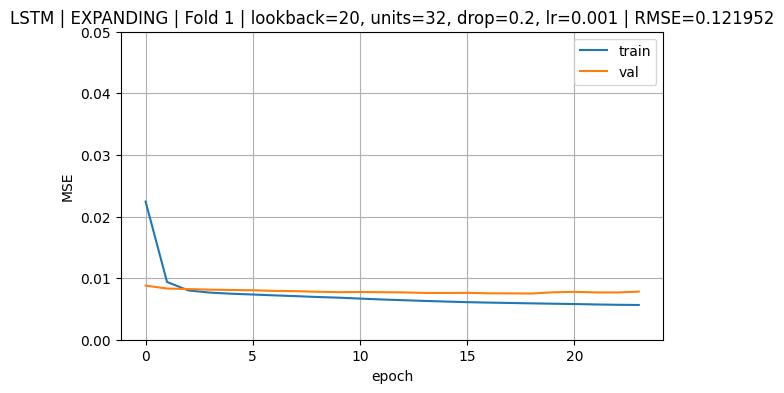

[LSTM][expanding] fold 1/5 RMSE=0.121952


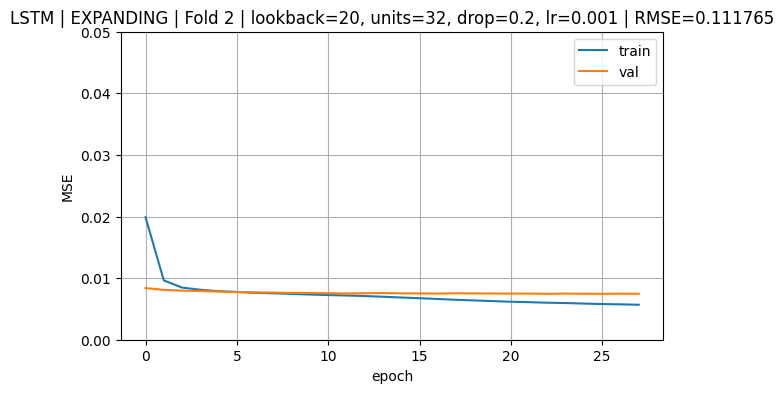

[LSTM][expanding] fold 2/5 RMSE=0.111765


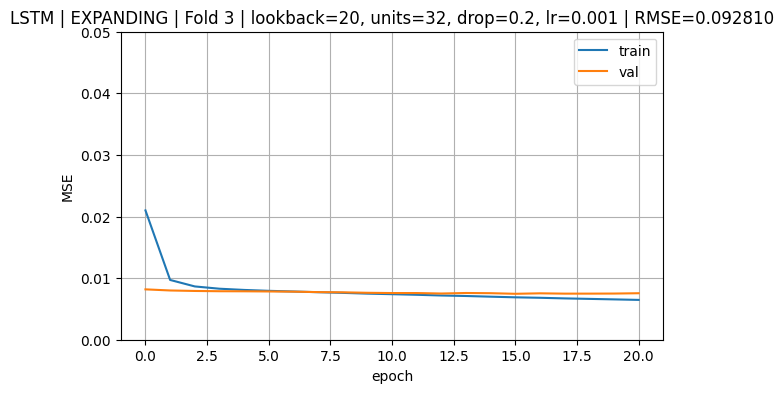

[LSTM][expanding] fold 3/5 RMSE=0.092810


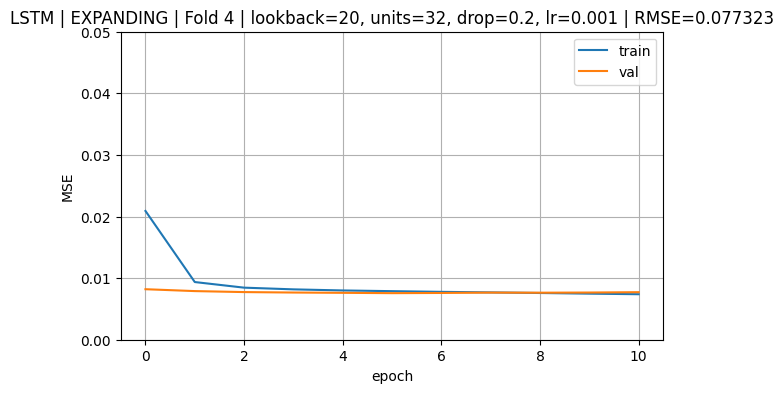

[LSTM][expanding] fold 4/5 RMSE=0.077323


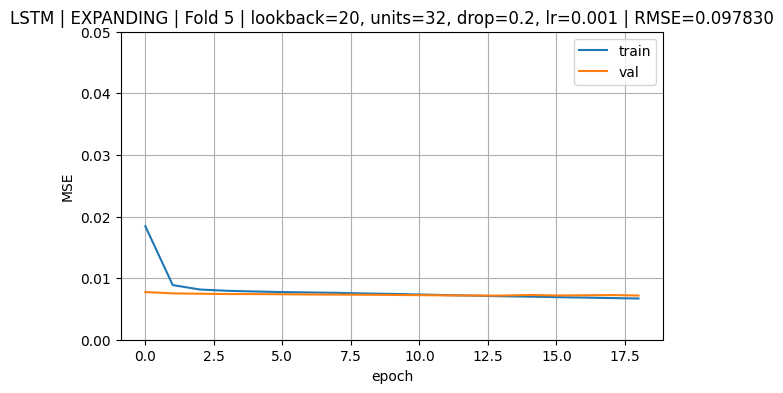

[LSTM][expanding] fold 5/5 RMSE=0.097830

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.121952,129576,15741
1,2,0.111765,147297,15741
2,3,0.092810,165018,15741
3,4,0.077323,182739,15834
4,5,0.097830,200553,15900


Mean RMSE: 0.10033602125616145 Std RMSE: 0.017251079805019713

LSTM config 2: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


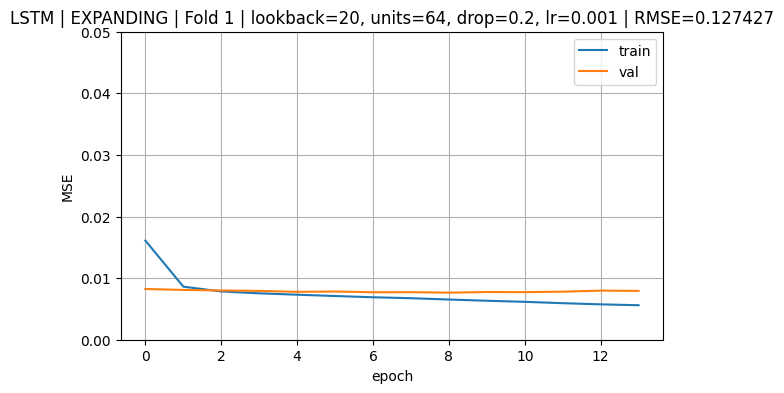

[LSTM][expanding] fold 1/5 RMSE=0.127427


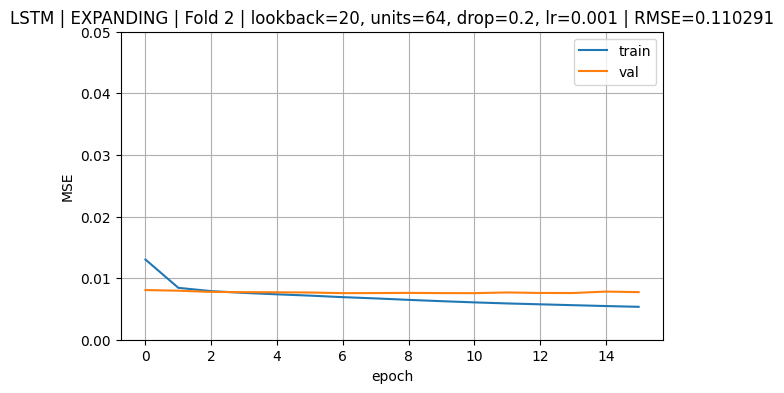

[LSTM][expanding] fold 2/5 RMSE=0.110291


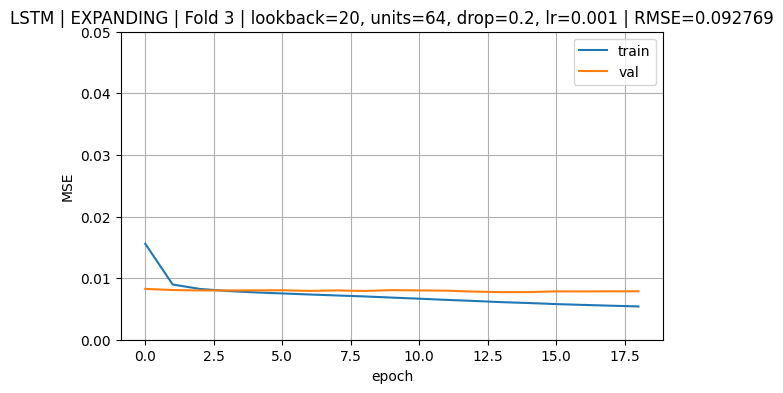

[LSTM][expanding] fold 3/5 RMSE=0.092769


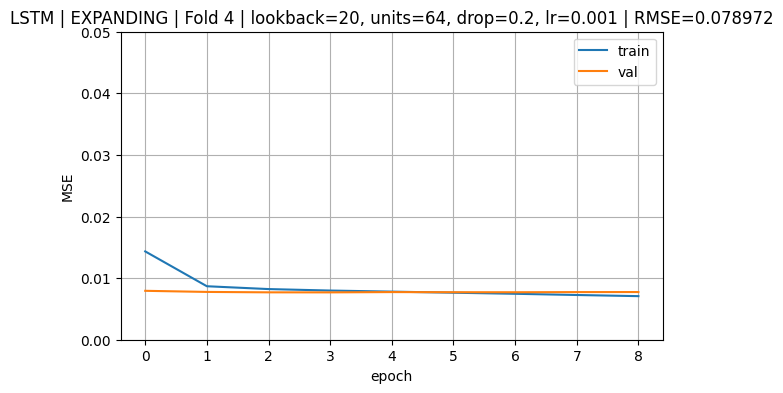

[LSTM][expanding] fold 4/5 RMSE=0.078972


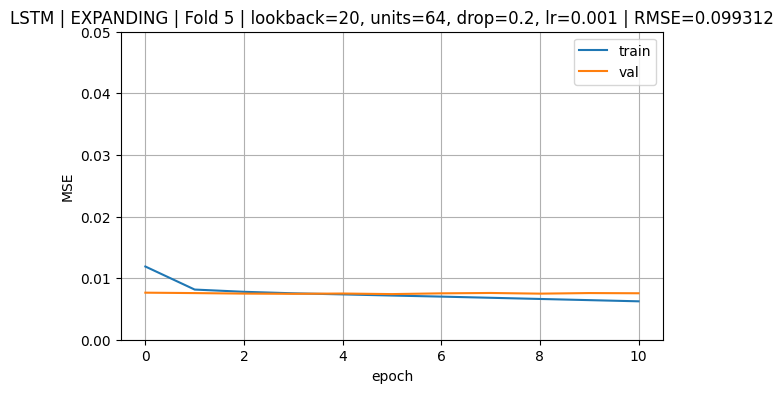

[LSTM][expanding] fold 5/5 RMSE=0.099312

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.127427,129576,15741
1,2,0.110291,147297,15741
2,3,0.092769,165018,15741
3,4,0.078972,182739,15834
4,5,0.099312,200553,15900


Mean RMSE: 0.10175398855111215 Std RMSE: 0.018287280017066705

LSTM config 3: {'lookback': 20, 'units': 64, 'dropout': 0.3, 'lr': 0.0005}


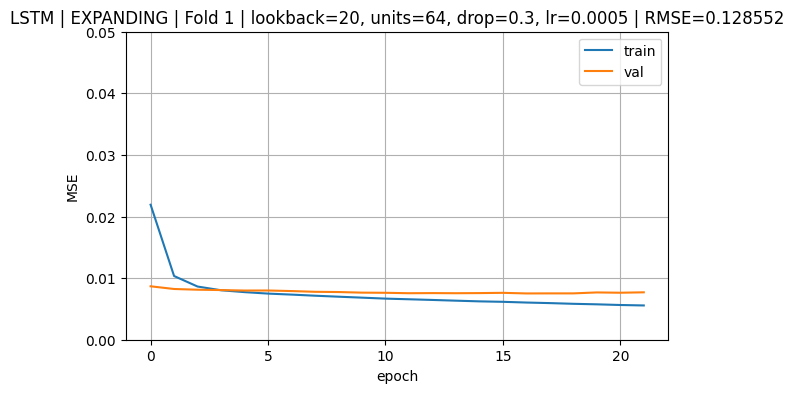

[LSTM][expanding] fold 1/5 RMSE=0.128552


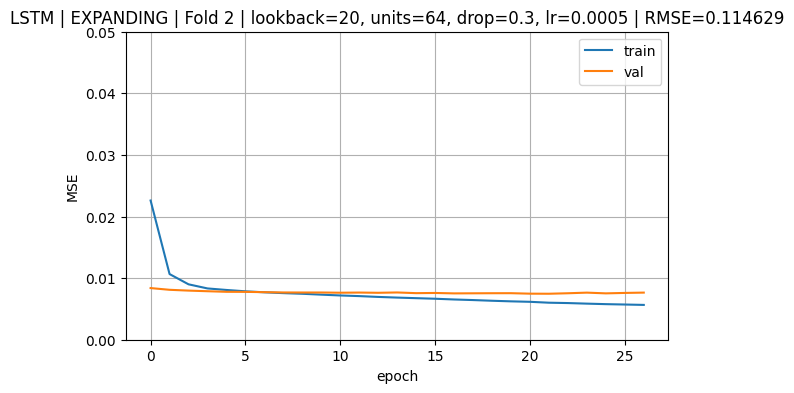

[LSTM][expanding] fold 2/5 RMSE=0.114629


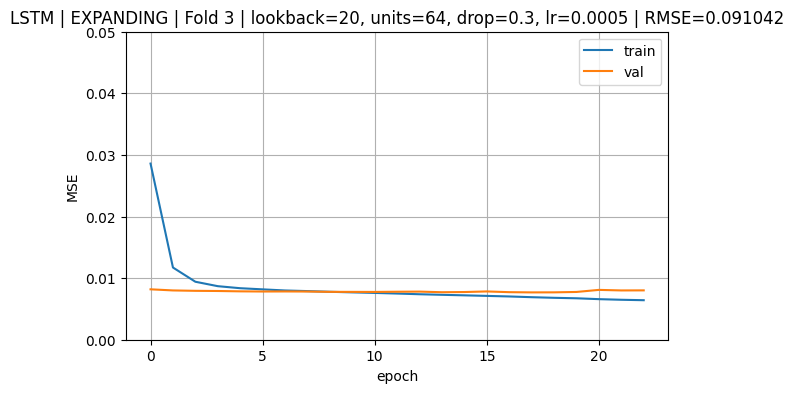

[LSTM][expanding] fold 3/5 RMSE=0.091042


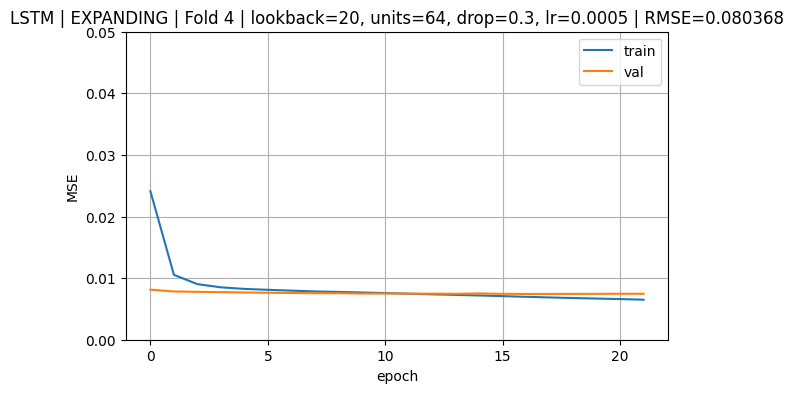

[LSTM][expanding] fold 4/5 RMSE=0.080368


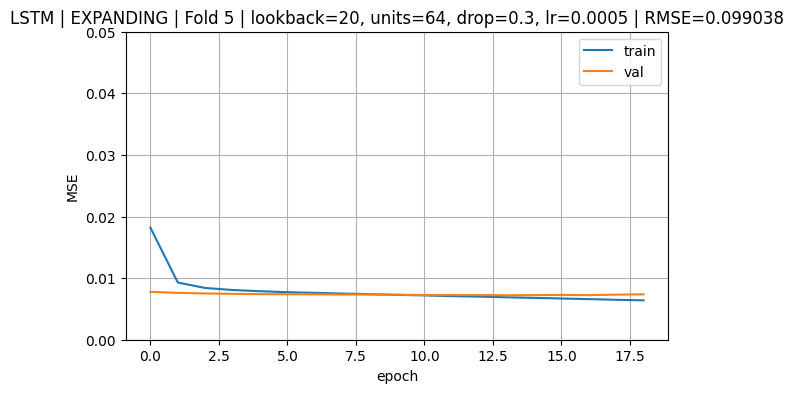

[LSTM][expanding] fold 5/5 RMSE=0.099038

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.128552,129576,15741
1,2,0.114629,147297,15741
2,3,0.091042,165018,15741
3,4,0.080368,182739,15834
4,5,0.099038,200553,15900


Mean RMSE: 0.10272578557939097 Std RMSE: 0.019096306811848113

LSTM config 4: {'lookback': 30, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


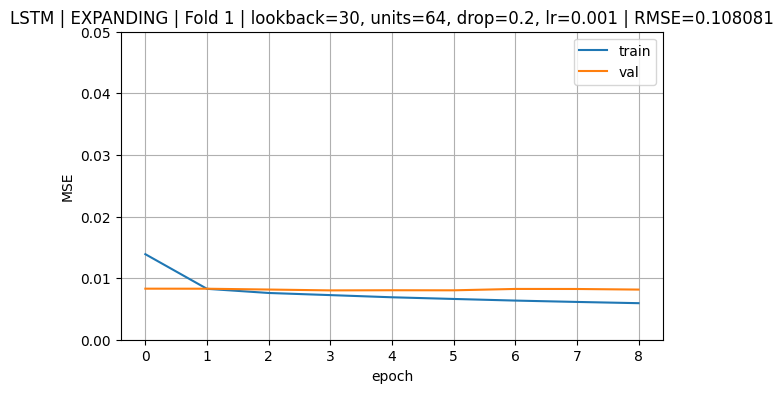

[LSTM][expanding] fold 1/5 RMSE=0.108081


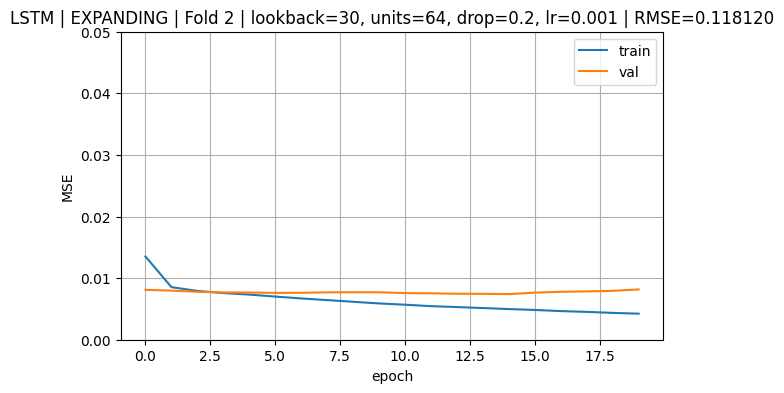

[LSTM][expanding] fold 2/5 RMSE=0.118120


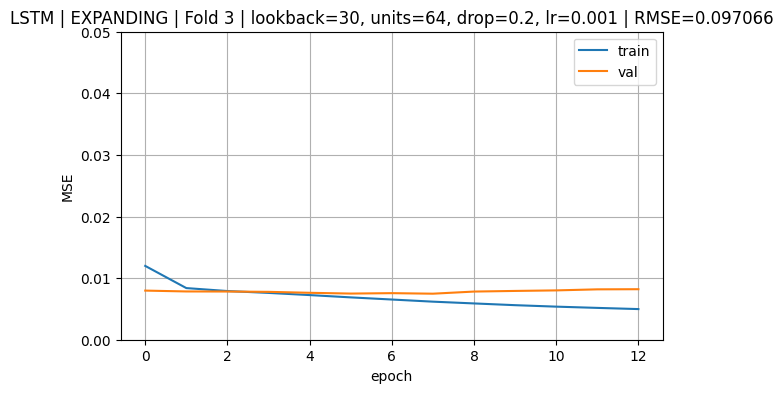

[LSTM][expanding] fold 3/5 RMSE=0.097066


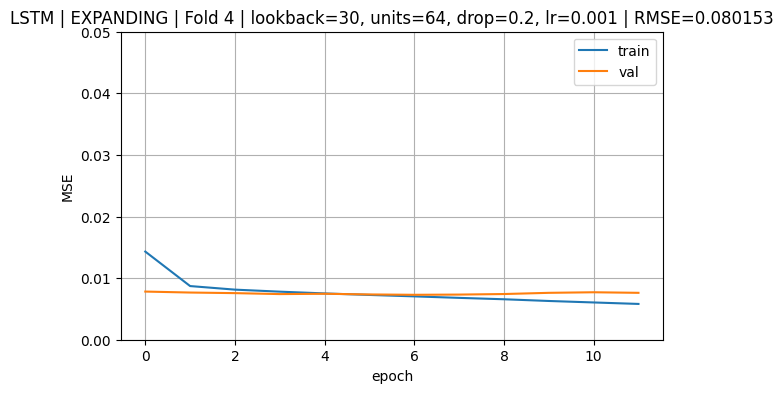

[LSTM][expanding] fold 4/5 RMSE=0.080153


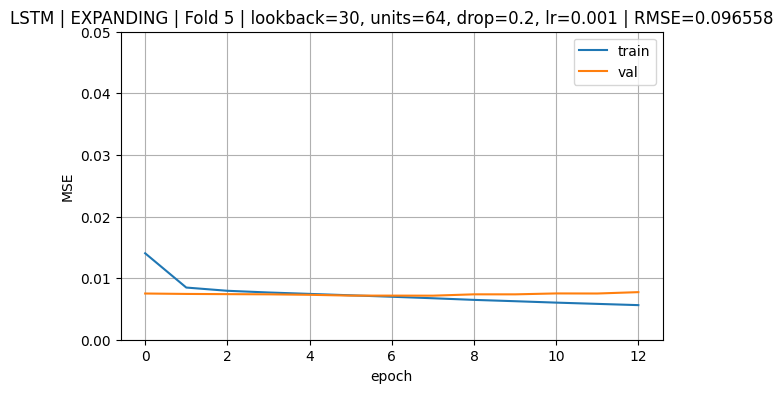

[LSTM][expanding] fold 5/5 RMSE=0.096558

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.108081,128586,14751
1,2,0.118120,146307,14751
2,3,0.097066,164028,14751
3,4,0.080153,181749,14834
4,5,0.096558,199553,14900


Mean RMSE: 0.09999574933224525 Std RMSE: 0.014212432817645133

=== LSTM Tuning Summary (Expanding CV) ===


,config_id,lookback,units,dropout,lr,mean_rmse,std_rmse
3,4,30,64,0.2,0.0010,0.099996,0.014212
0,1,20,32,0.2,0.0010,0.100336,0.017251
1,2,20,64,0.2,0.0010,0.101754,0.018287
2,3,20,64,0.3,0.0005,0.102726,0.019096


In [44]:
# =========================
# Run LSTM tuning on RETURN
# =========================
lstm_summary_return = tune_lstm_expanding(
    panel_return_clean,
    n_splits=5,
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42
)


Rolling robustness on best config (optional, after tuning)

In [45]:
best_cfg = lstm_summary_return.iloc[0].to_dict()
best_cfg


{'config_id': 4.0,
 'lookback': 30.0,
 'units': 64.0,
 'dropout': 0.2,
 'lr': 0.001,
 'mean_rmse': 0.09999574933224525,
 'std_rmse': 0.014212432817645133}

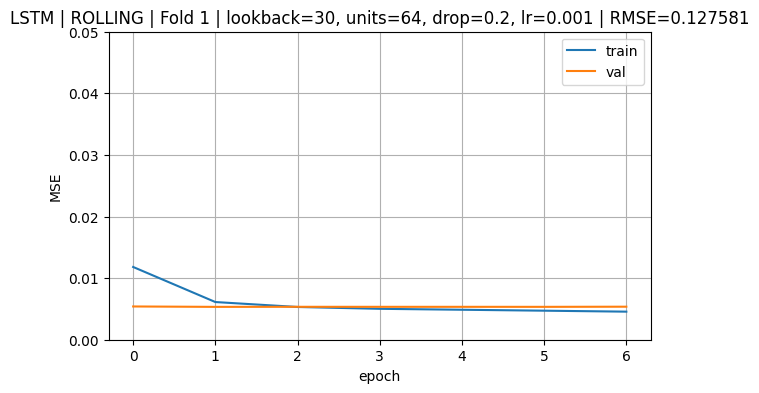

[LSTM][rolling] fold 1/5 RMSE=0.127581


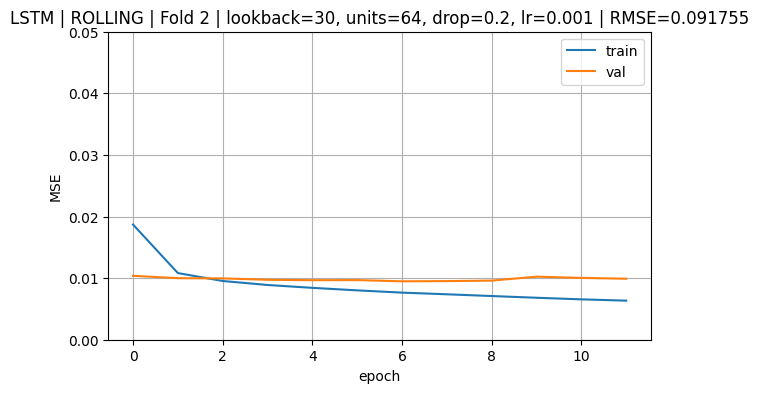

[LSTM][rolling] fold 2/5 RMSE=0.091755


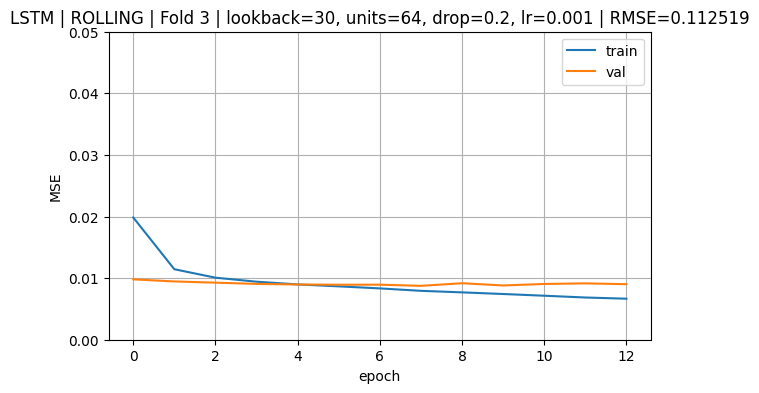

[LSTM][rolling] fold 3/5 RMSE=0.112519


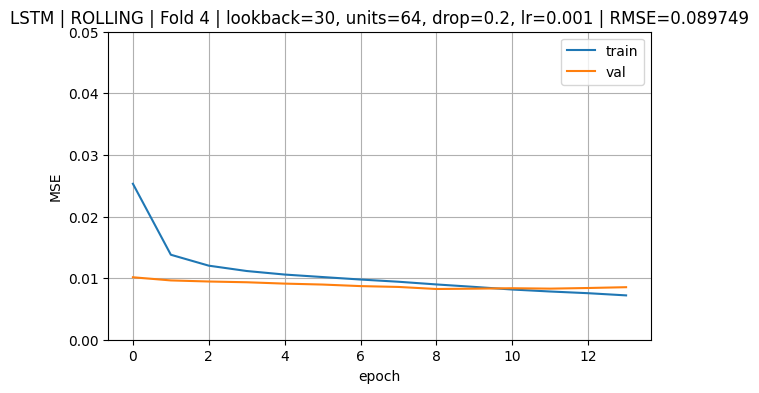

[LSTM][rolling] fold 4/5 RMSE=0.089749


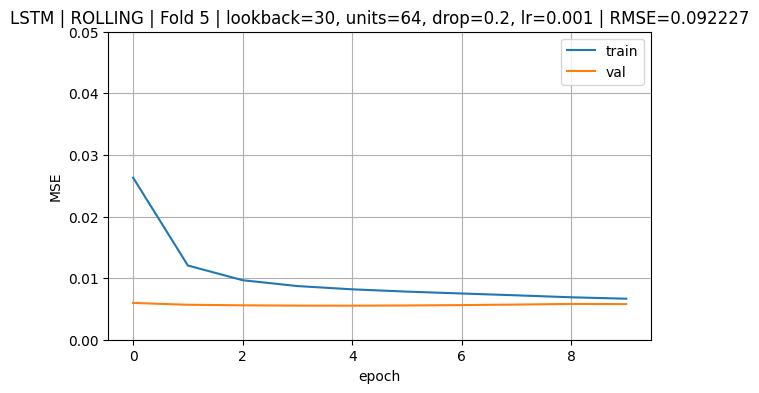

[LSTM][rolling] fold 5/5 RMSE=0.092227

Summary: LSTM rolling


,fold,rmse,n_train,n_test
0,1,0.127581,84488,23437
1,2,0.091755,84772,23661
2,3,0.112519,85152,23661
3,4,0.089749,85421,23661
4,5,0.092227,85690,23900


Mean RMSE: 0.10276618589636459 Std RMSE: 0.016678332865030746


In [46]:
df_lstm_return_rolling = run_lstm_cv(
    panel_return_clean,
    scheme="rolling",
    n_splits=5,
    lookback=int(best_cfg["lookback"]),
    units=int(best_cfg["units"]),
    dropout=float(best_cfg["dropout"]),
    lr=float(best_cfg["lr"]),
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42,
    plot_curves=True
)


Run LSTM for risk (CVaR)


LSTM config 1: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'lr': 0.001}


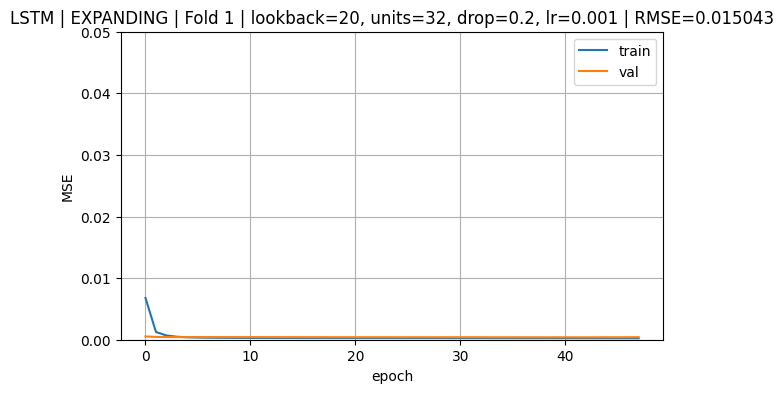

[LSTM][expanding] fold 1/5 RMSE=0.015043


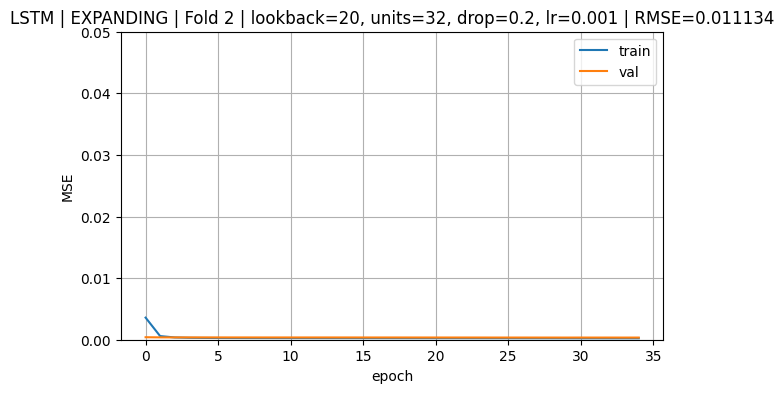

[LSTM][expanding] fold 2/5 RMSE=0.011134


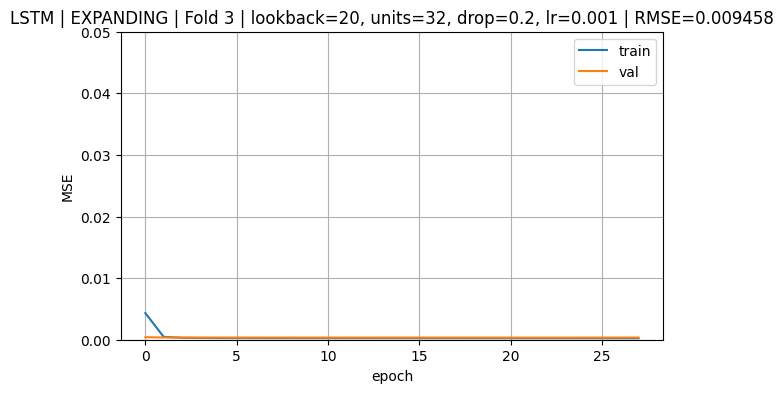

[LSTM][expanding] fold 3/5 RMSE=0.009458


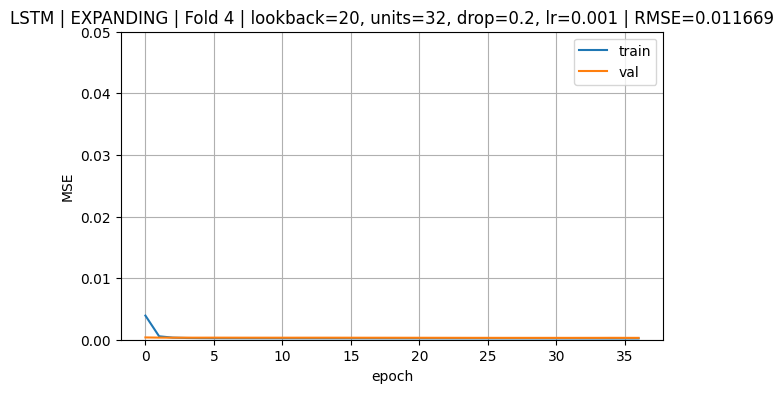

[LSTM][expanding] fold 4/5 RMSE=0.011669


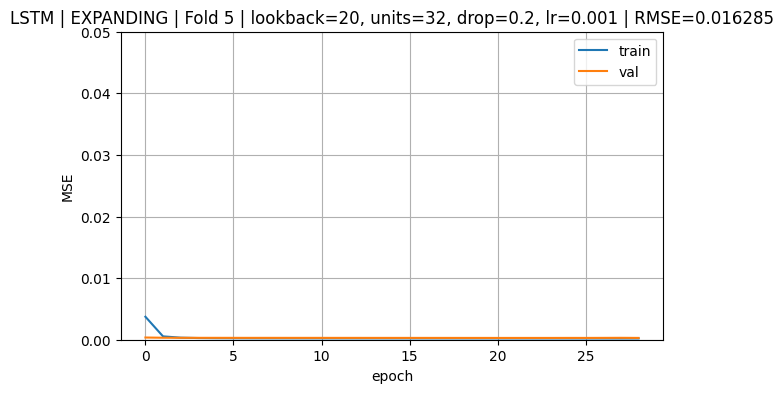

[LSTM][expanding] fold 5/5 RMSE=0.016285

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.015043,140000,16900
1,2,0.011134,158900,16900
2,3,0.009458,177800,16900
3,4,0.011669,196700,16900
4,5,0.016285,215600,16900


Mean RMSE: 0.012717826153305203 Std RMSE: 0.002844423025919146

LSTM config 2: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


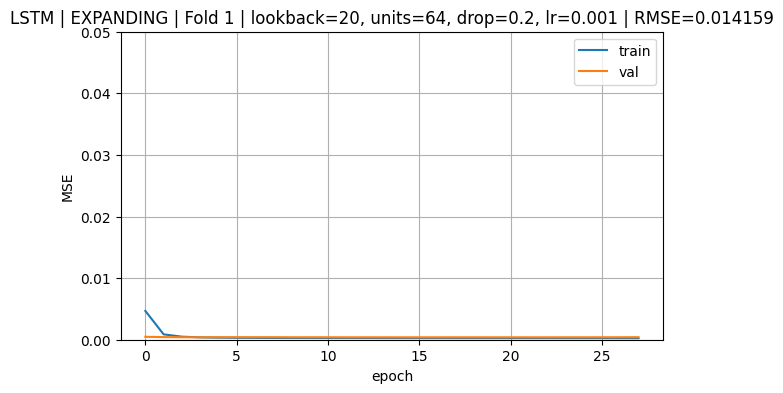

[LSTM][expanding] fold 1/5 RMSE=0.014159


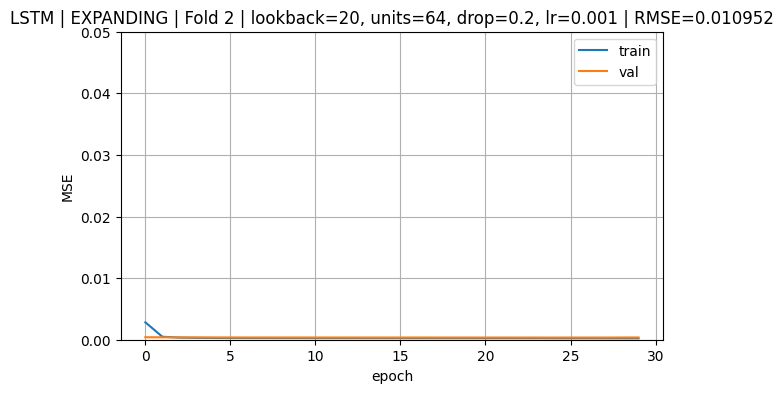

[LSTM][expanding] fold 2/5 RMSE=0.010952


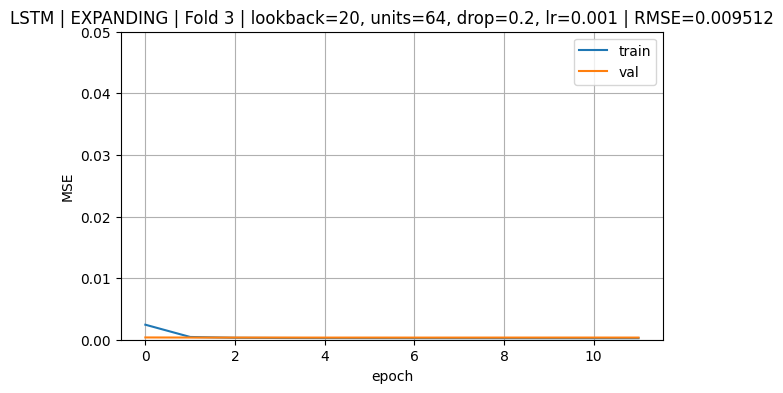

[LSTM][expanding] fold 3/5 RMSE=0.009512


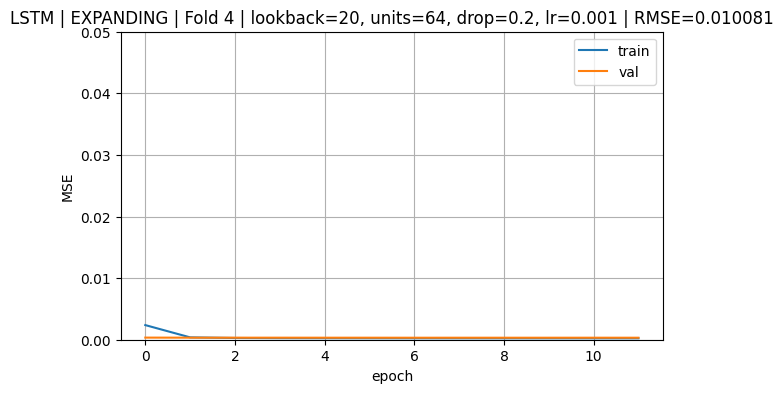

[LSTM][expanding] fold 4/5 RMSE=0.010081


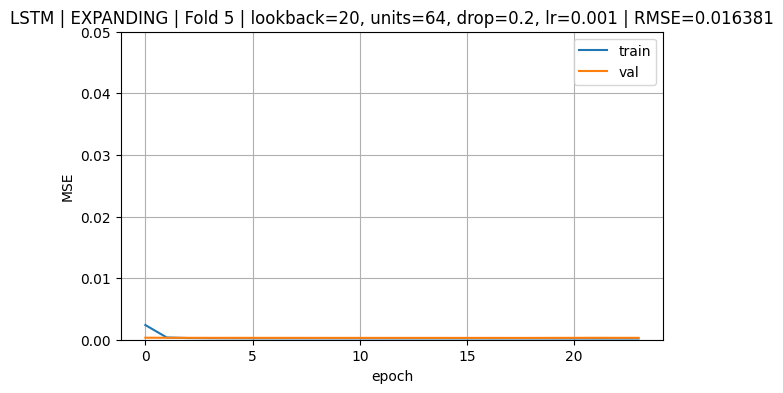

[LSTM][expanding] fold 5/5 RMSE=0.016381

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.014159,140000,16900
1,2,0.010952,158900,16900
2,3,0.009512,177800,16900
3,4,0.010081,196700,16900
4,5,0.016381,215600,16900


Mean RMSE: 0.012217096971319473 Std RMSE: 0.0029403714159531723

LSTM config 3: {'lookback': 20, 'units': 64, 'dropout': 0.3, 'lr': 0.0005}


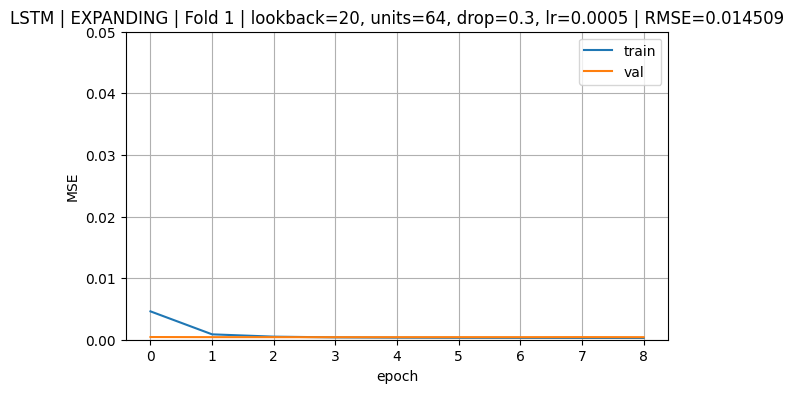

[LSTM][expanding] fold 1/5 RMSE=0.014509


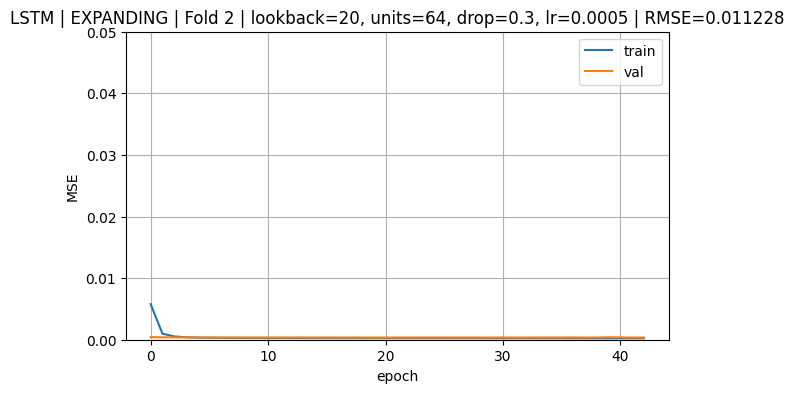

[LSTM][expanding] fold 2/5 RMSE=0.011228


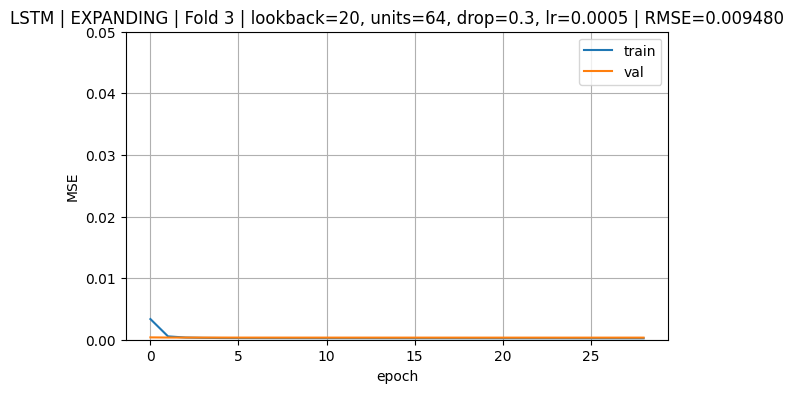

[LSTM][expanding] fold 3/5 RMSE=0.009480


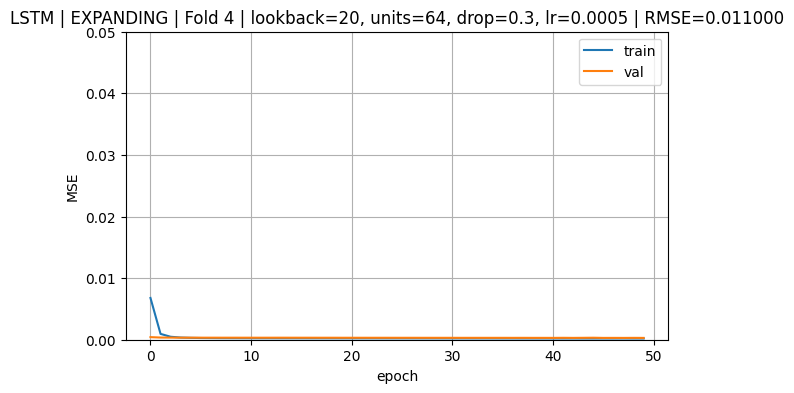

[LSTM][expanding] fold 4/5 RMSE=0.011000


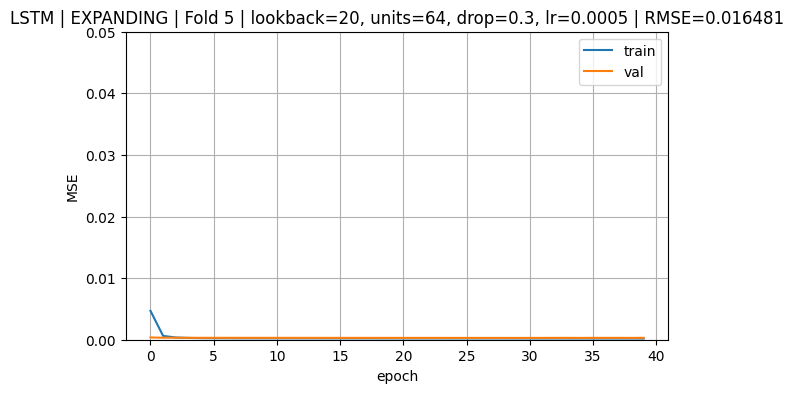

[LSTM][expanding] fold 5/5 RMSE=0.016481

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.014509,140000,16900
1,2,0.011228,158900,16900
2,3,0.009480,177800,16900
3,4,0.011000,196700,16900
4,5,0.016481,215600,16900


Mean RMSE: 0.01253966776444208 Std RMSE: 0.002866298766585238

LSTM config 4: {'lookback': 30, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


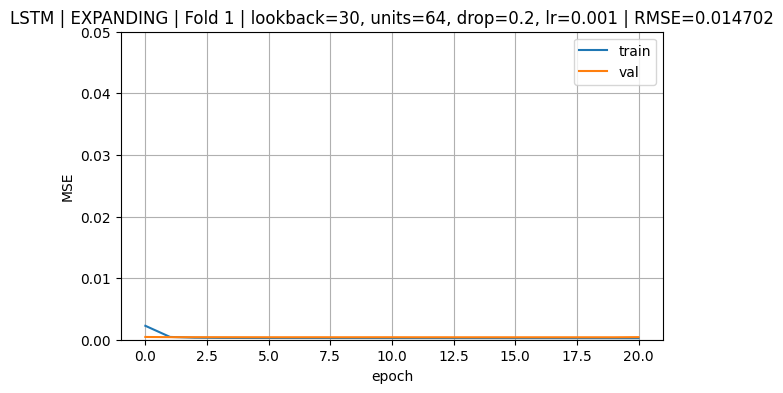

[LSTM][expanding] fold 1/5 RMSE=0.014702


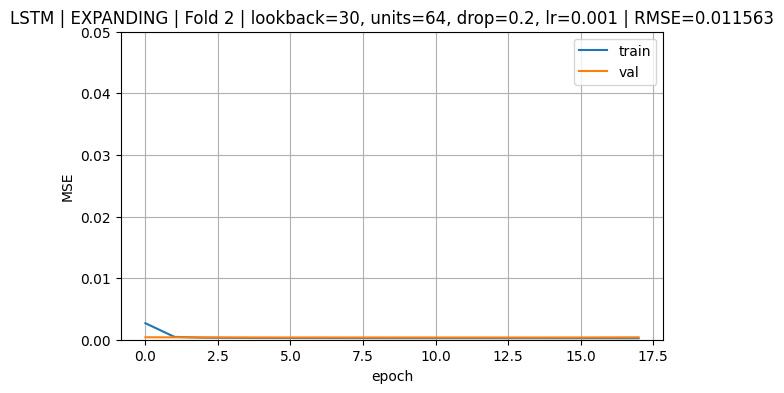

[LSTM][expanding] fold 2/5 RMSE=0.011563


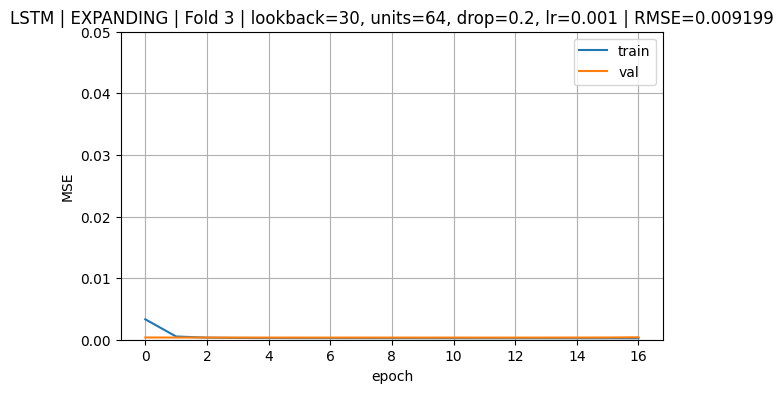

[LSTM][expanding] fold 3/5 RMSE=0.009199


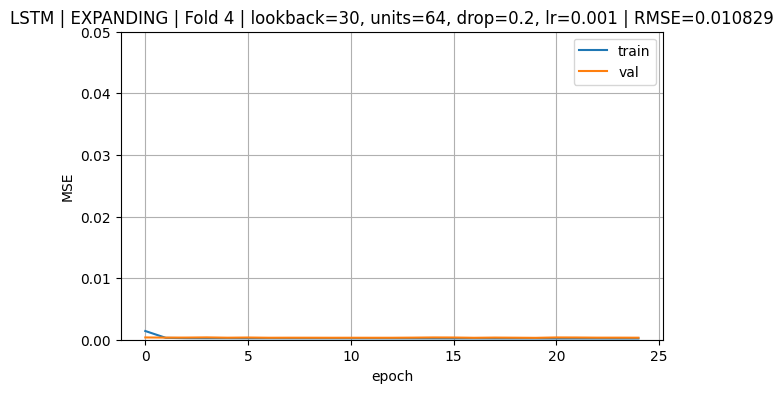

[LSTM][expanding] fold 4/5 RMSE=0.010829


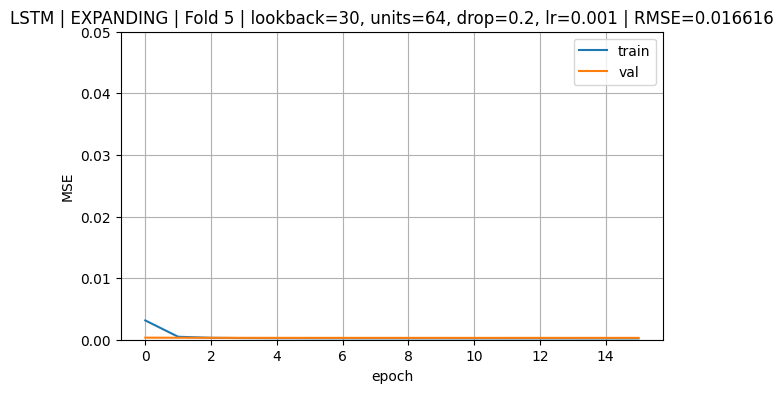

[LSTM][expanding] fold 5/5 RMSE=0.016616

Summary: LSTM expanding


,fold,rmse,n_train,n_test
0,1,0.014702,139000,15900
1,2,0.011563,157900,15900
2,3,0.009199,176800,15900
3,4,0.010829,195700,15900
4,5,0.016616,214600,15900


Mean RMSE: 0.012581720108803717 Std RMSE: 0.0030133748631634713

=== LSTM Tuning Summary (Expanding CV) ===


,config_id,lookback,units,dropout,lr,mean_rmse,std_rmse
1,2,20,64,0.2,0.0010,0.012217,0.002940
2,3,20,64,0.3,0.0005,0.012540,0.002866
3,4,30,64,0.2,0.0010,0.012582,0.003013
0,1,20,32,0.2,0.0010,0.012718,0.002844


In [47]:
# =========================
# LSTM tuning on RISK / CVaR
# =========================
lstm_summary_risk = tune_lstm_expanding(
    panel_risk_clean,
    n_splits=5,
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42
)


Rolling CV robustness for Risk

In [48]:
best_cfg_risk = lstm_summary_risk.iloc[0].to_dict()
best_cfg_risk


{'config_id': 2.0,
 'lookback': 20.0,
 'units': 64.0,
 'dropout': 0.2,
 'lr': 0.001,
 'mean_rmse': 0.012217096971319473,
 'std_rmse': 0.0029403714159531723}

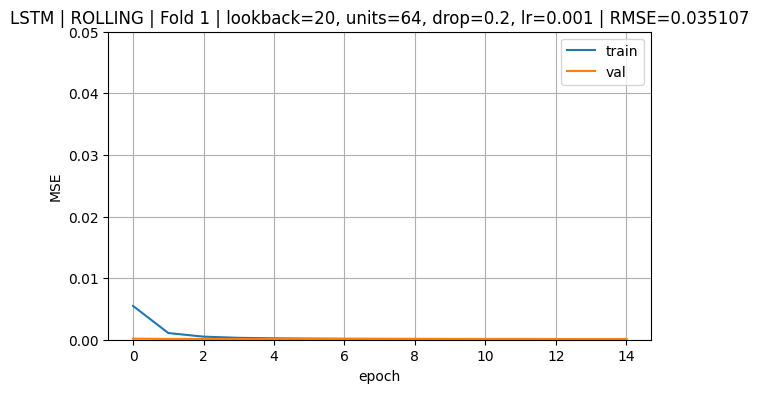

[LSTM][rolling] fold 1/5 RMSE=0.035107


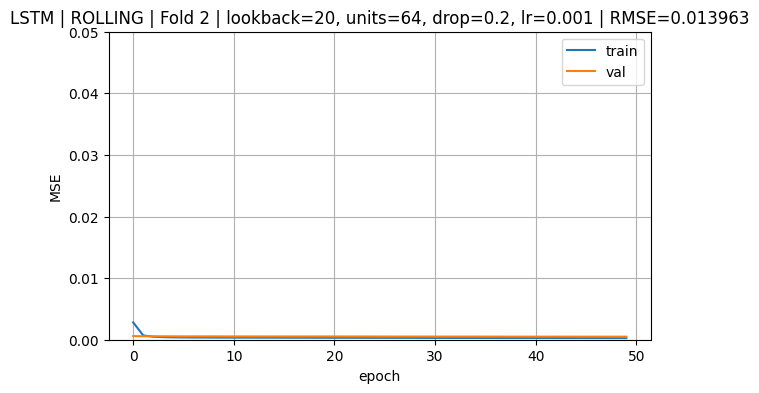

[LSTM][rolling] fold 2/5 RMSE=0.013963


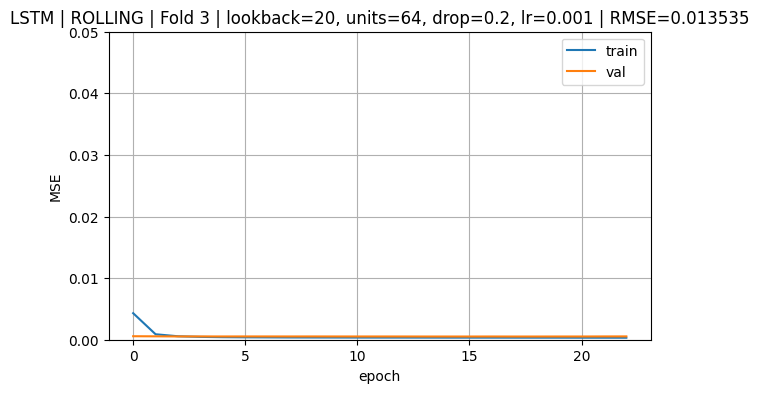

[LSTM][rolling] fold 3/5 RMSE=0.013535


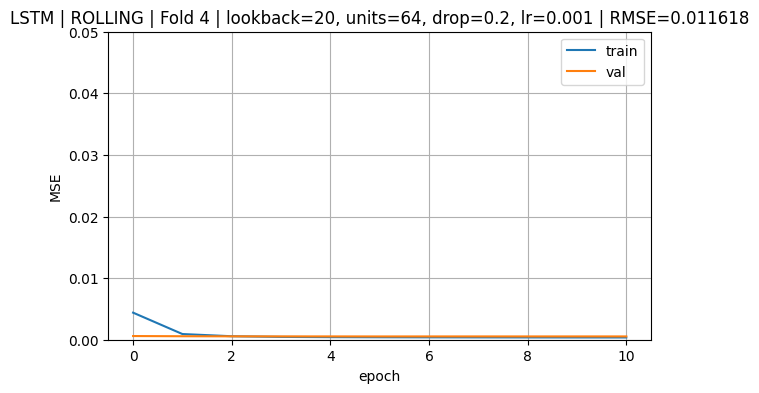

[LSTM][rolling] fold 4/5 RMSE=0.011618


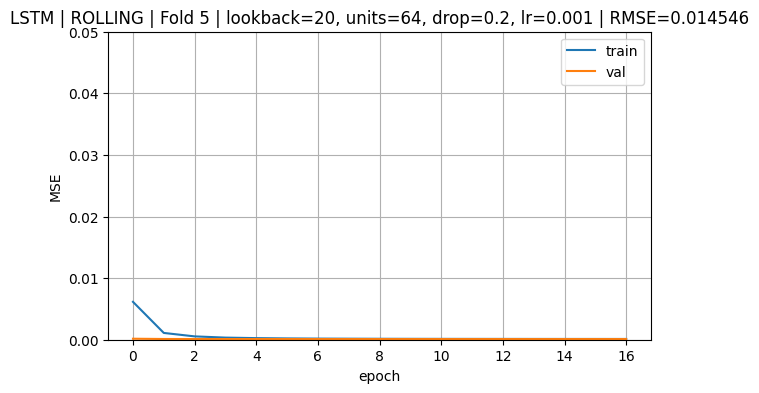

[LSTM][rolling] fold 5/5 RMSE=0.014546

Summary: LSTM rolling


,fold,rmse,n_train,n_test
0,1,0.035107,92700,26400
1,2,0.013963,92700,26400
2,3,0.013535,92700,26400
3,4,0.011618,92700,26400
4,5,0.014546,92700,26400


Mean RMSE: 0.017753721500242174 Std RMSE: 0.009762661103898219


In [49]:
# =========================
# LSTM rolling-window robustness (RISK)
# =========================
df_lstm_risk_rolling = run_lstm_cv(
    panel_risk_clean,
    scheme="rolling",
    n_splits=5,
    lookback=int(best_cfg_risk["lookback"]),
    units=int(best_cfg_risk["units"]),
    dropout=float(best_cfg_risk["dropout"]),
    lr=float(best_cfg_risk["lr"]),
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42,
    plot_curves=True
)


**3. GRU**

GRU model builder

In [52]:
# =========================
# GRU: model builder
# =========================
def build_gru_model(input_shape, units=64, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model


Fit one fold (same structure as LSTM)

In [53]:
# =========================
# GRU: train one fold + training curve
# =========================
def fit_gru_one_fold(
    Xtr, ytr, Xte, yte,
    units=64, dropout=0.2, lr=1e-3,
    epochs=50, batch_size=512, patience=5,
    seed=42, verbose=0,
    plot=True, title=""
):
    set_seed(seed)

    # fold-internal train/val split (last 10% = val)
    n = len(Xtr)
    cut = int(n * 0.9)
    X_train, y_train = Xtr[:cut], ytr[:cut]
    X_val,   y_val   = Xtr[cut:], ytr[cut:]

    model = build_gru_model(
        input_shape=X_train.shape[1:],
        units=units,
        dropout=dropout,
        lr=lr
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose
    )

    pred = model.predict(Xte, verbose=0).ravel()
    fold_rmse = rmse(yte, pred)

    if plot:
        plot_fold_curve(hist, f"{title} | RMSE={fold_rmse:.6f}")

    return fold_rmse


GRU CV runner (Expanding / Rolling)

In [54]:
# =========================
# GRU: run CV on a panel
# =========================
def run_gru_cv(
    panel_clean,
    scheme="expanding",
    n_splits=5,
    lookback=20,
    units=64, dropout=0.2, lr=1e-3,
    epochs=50, batch_size=512, patience=5,
    seed=42,
    plot_curves=True
):
    if scheme == "expanding":
        folds = expanding_window_folds(panel_clean, n_splits=n_splits)   # uses your fixed min_train_frac=0.6
    elif scheme == "rolling":
        folds = rolling_window_folds(panel_clean, n_splits=n_splits)
    else:
        raise ValueError("scheme must be 'expanding' or 'rolling'")

    fold_rows = []

    for k, (train_dates, test_dates) in enumerate(folds, start=1):
        train_fold, test_fold = slice_by_dates(panel_clean, train_dates, test_dates)

        # sequence tensors per fold
        Xtr, ytr, Xte, yte = make_sequence_tensors(train_fold, test_fold, lookback=lookback)

        fold_rmse = fit_gru_one_fold(
            Xtr, ytr, Xte, yte,
            units=units, dropout=dropout, lr=lr,
            epochs=epochs, batch_size=batch_size, patience=patience,
            seed=seed,
            verbose=0,
            plot=plot_curves,
            title=f"GRU | {scheme.upper()} | Fold {k} | lookback={lookback}, units={units}, drop={dropout}, lr={lr}"
        )

        fold_rows.append({
            "fold": k,
            "rmse": fold_rmse,
            "n_train": len(Xtr),
            "n_test": len(Xte)
        })

        print(f"[GRU][{scheme}] fold {k}/{len(folds)} RMSE={fold_rmse:.6f}")

    df = pd.DataFrame(fold_rows)
    print("\nSummary: GRU", scheme)
    display(df)
    print("Mean RMSE:", df["rmse"].mean(), "Std RMSE:", df["rmse"].std())
    return df


3-config GRU grid (same for return + risk)

In [55]:
# =========================
# GRU grid (3 configs)
# =========================
GRU_GRID = [
    {"lookback": 20, "units": 32, "dropout": 0.2, "lr": 1e-3},
    {"lookback": 20, "units": 64, "dropout": 0.2, "lr": 1e-3},
    {"lookback": 30, "units": 64, "dropout": 0.2, "lr": 1e-3},
]


Run GRU on RETURN (Expanding + Rolling)


GRU RETURN config 1: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'lr': 0.001}


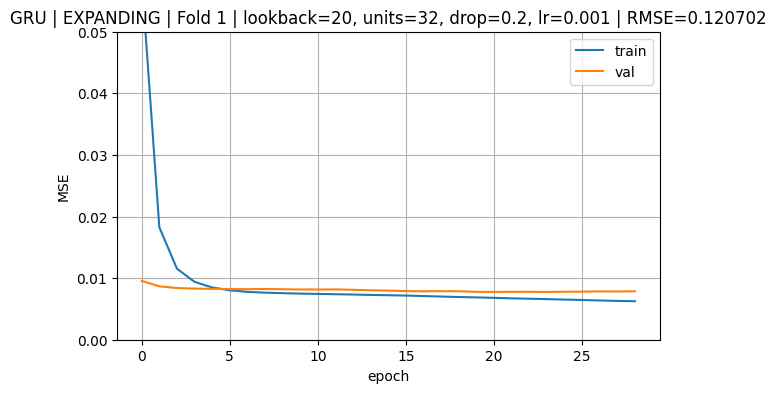

[GRU][expanding] fold 1/5 RMSE=0.120702


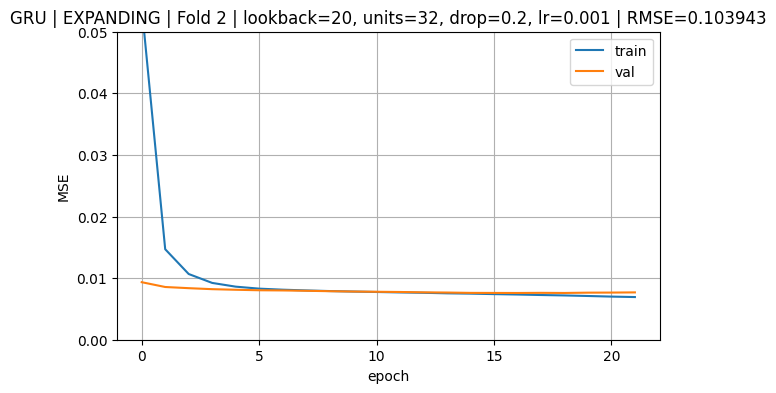

[GRU][expanding] fold 2/5 RMSE=0.103943


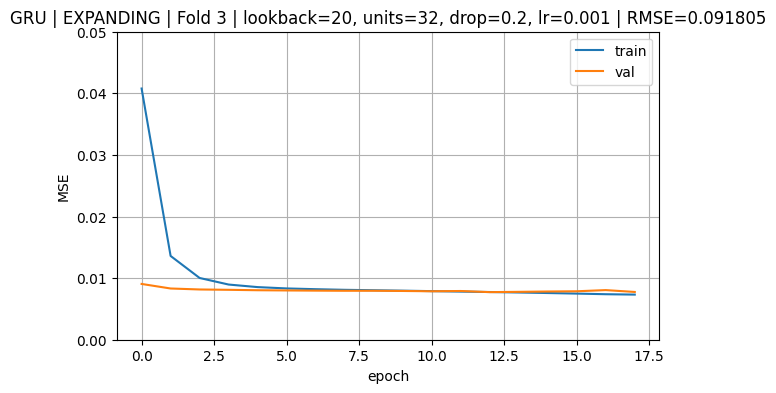

[GRU][expanding] fold 3/5 RMSE=0.091805


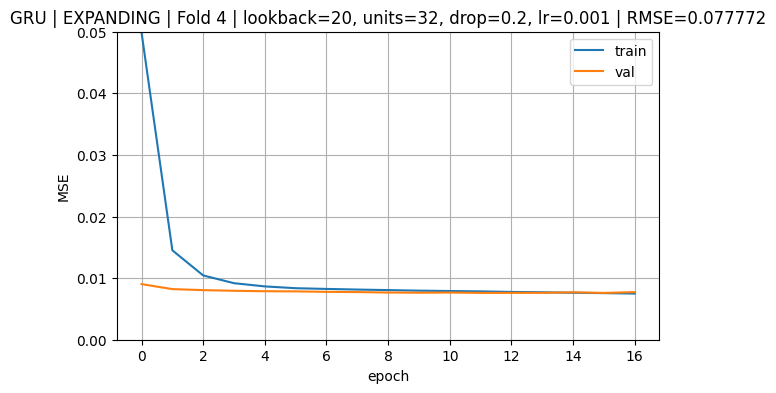

[GRU][expanding] fold 4/5 RMSE=0.077772


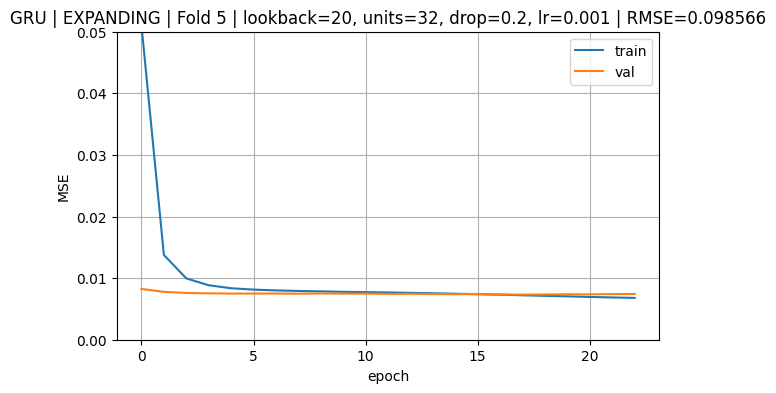

[GRU][expanding] fold 5/5 RMSE=0.098566

Summary: GRU expanding


,fold,rmse,n_train,n_test
0,1,0.120702,129576,15741
1,2,0.103943,147297,15741
2,3,0.091805,165018,15741
3,4,0.077772,182739,15834
4,5,0.098566,200553,15900


Mean RMSE: 0.09855753273463067 Std RMSE: 0.01578780871161667

GRU RETURN config 2: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


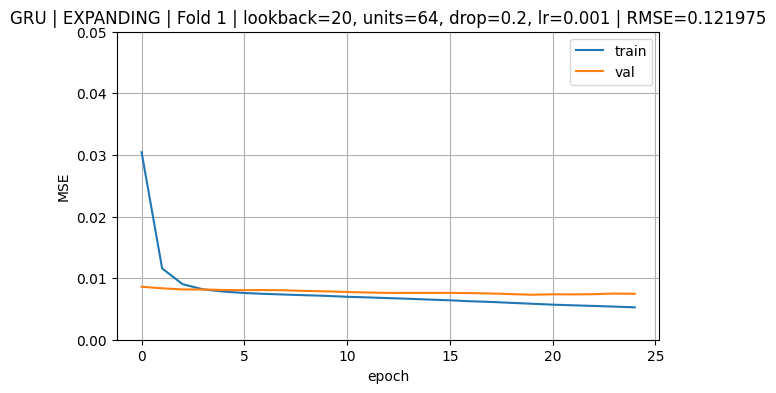

[GRU][expanding] fold 1/5 RMSE=0.121975


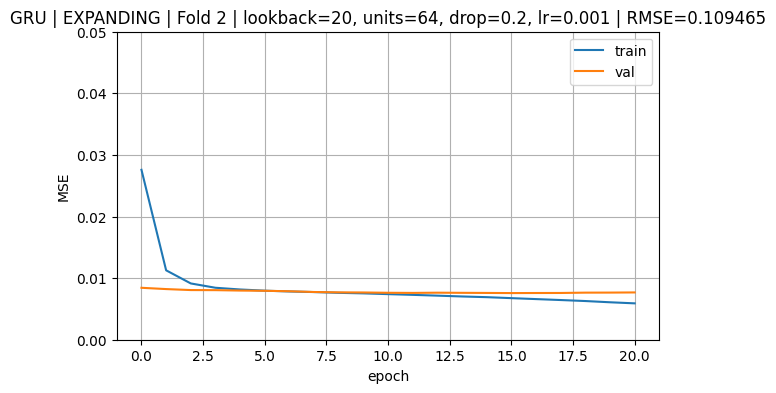

[GRU][expanding] fold 2/5 RMSE=0.109465


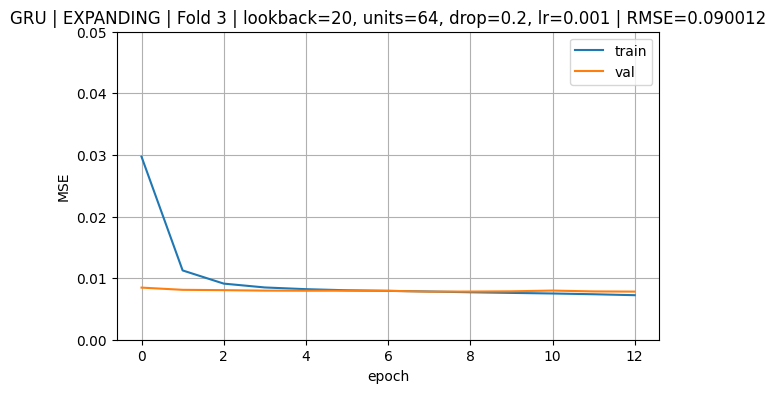

[GRU][expanding] fold 3/5 RMSE=0.090012


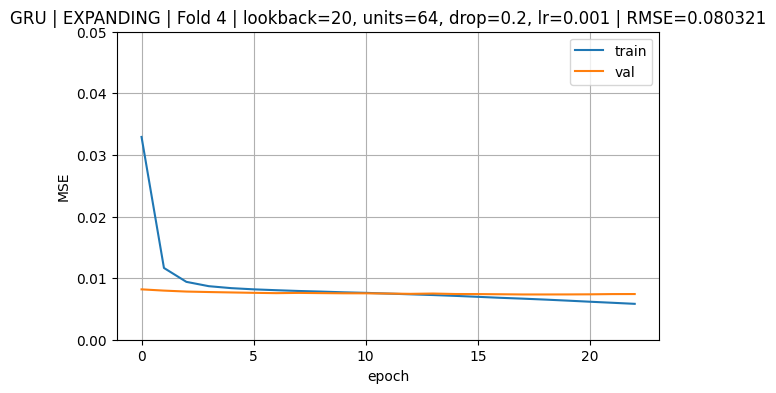

[GRU][expanding] fold 4/5 RMSE=0.080321


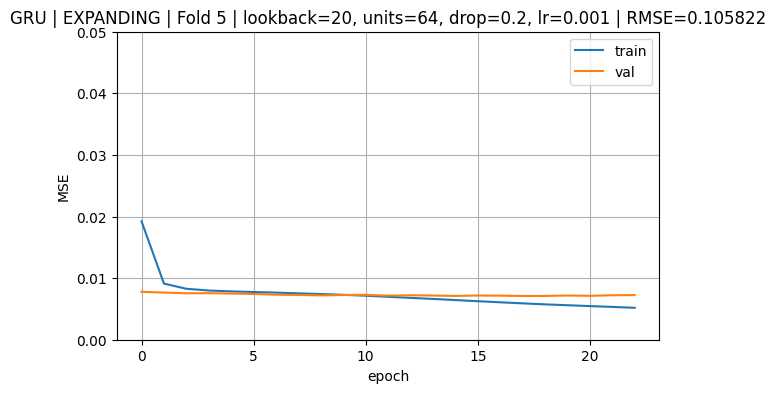

[GRU][expanding] fold 5/5 RMSE=0.105822

Summary: GRU expanding


,fold,rmse,n_train,n_test
0,1,0.121975,129576,15741
1,2,0.109465,147297,15741
2,3,0.090012,165018,15741
3,4,0.080321,182739,15834
4,5,0.105822,200553,15900


Mean RMSE: 0.10151901679124127 Std RMSE: 0.01644598171967964

GRU RETURN config 3: {'lookback': 30, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


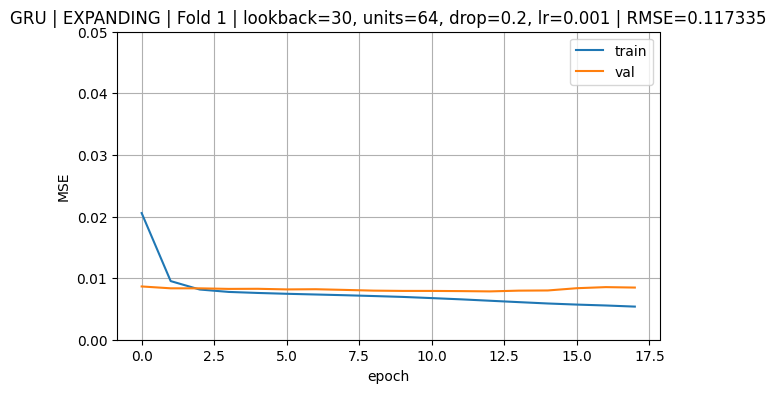

[GRU][expanding] fold 1/5 RMSE=0.117335


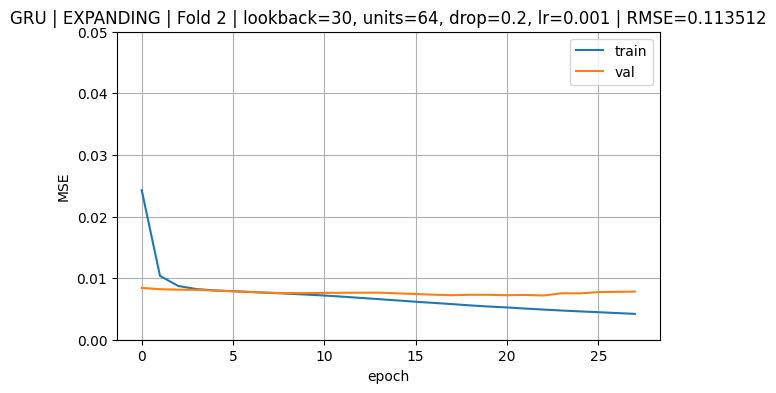

[GRU][expanding] fold 2/5 RMSE=0.113512


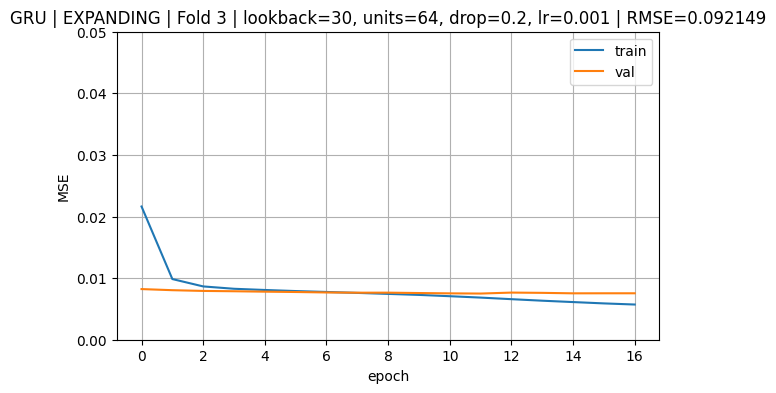

[GRU][expanding] fold 3/5 RMSE=0.092149


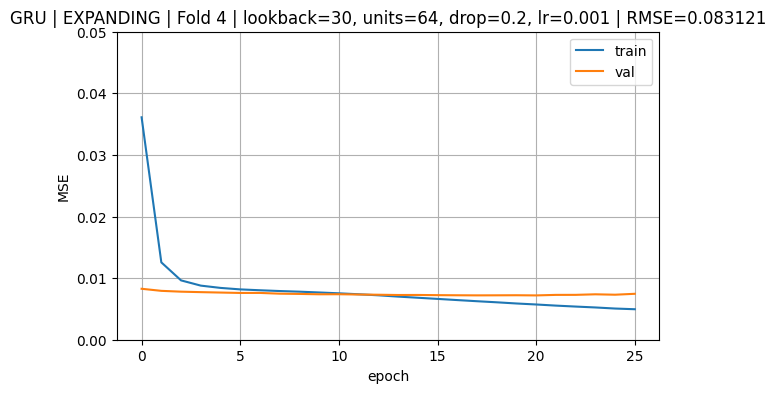

[GRU][expanding] fold 4/5 RMSE=0.083121


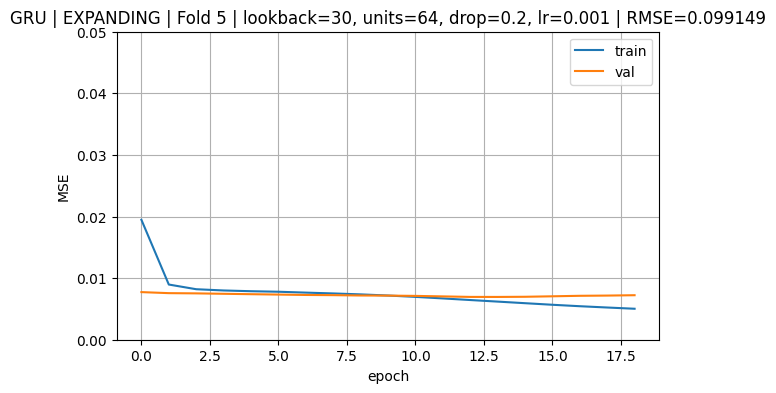

[GRU][expanding] fold 5/5 RMSE=0.099149

Summary: GRU expanding


,fold,rmse,n_train,n_test
0,1,0.117335,128586,14751
1,2,0.113512,146307,14751
2,3,0.092149,164028,14751
3,4,0.083121,181749,14834
4,5,0.099149,199553,14900


Mean RMSE: 0.10105327784884503 Std RMSE: 0.014359563530570088

=== GRU RETURN Summary (Expanding CV) ===


,config_id,lookback,units,dropout,lr,mean_rmse,std_rmse
0,1,20,32,0.2,0.001,0.098558,0.015788
2,3,30,64,0.2,0.001,0.101053,0.014360
1,2,20,64,0.2,0.001,0.101519,0.016446


In [56]:
# =========================
# GRU on RETURN — Expanding (PRIMARY)
# =========================
gru_return_results = []
for i, cfg in enumerate(GRU_GRID, start=1):
    print("\n" + "="*90)
    print(f"GRU RETURN config {i}: {cfg}")
    print("="*90)

    df = run_gru_cv(
        panel_return_clean,
        scheme="expanding",
        n_splits=5,
        lookback=cfg["lookback"],
        units=cfg["units"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        epochs=50,
        batch_size=512,
        patience=5,
        seed=42,
        plot_curves=True
    )
    gru_return_results.append({
        "config_id": i,
        **cfg,
        "mean_rmse": df["rmse"].mean(),
        "std_rmse": df["rmse"].std()
    })

gru_summary_return = pd.DataFrame(gru_return_results).sort_values("mean_rmse")
print("\n=== GRU RETURN Summary (Expanding CV) ===")
display(gru_summary_return)


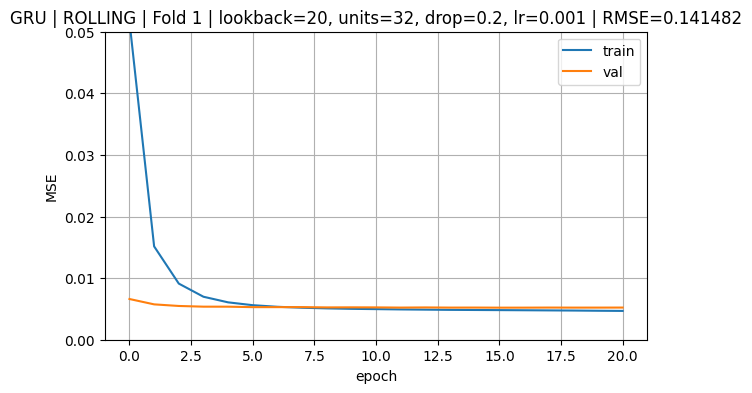

[GRU][rolling] fold 1/5 RMSE=0.141482


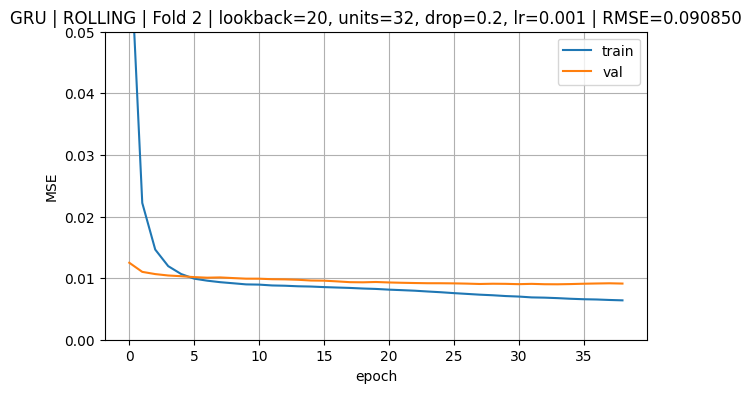

[GRU][rolling] fold 2/5 RMSE=0.090850


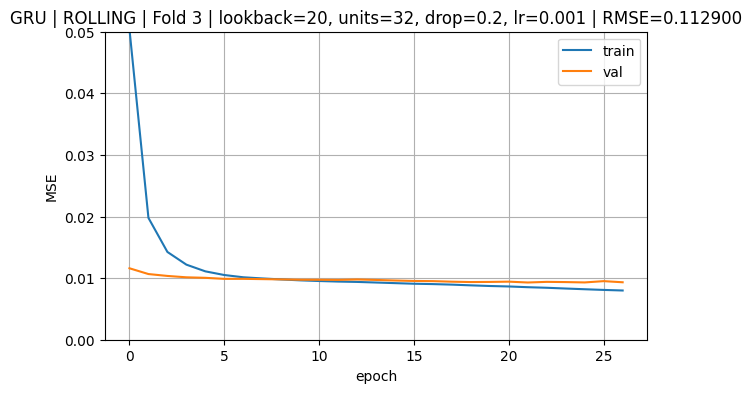

[GRU][rolling] fold 3/5 RMSE=0.112900


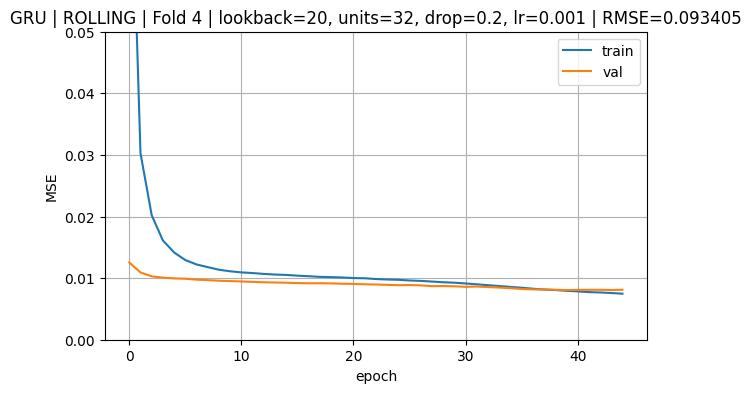

[GRU][rolling] fold 4/5 RMSE=0.093405


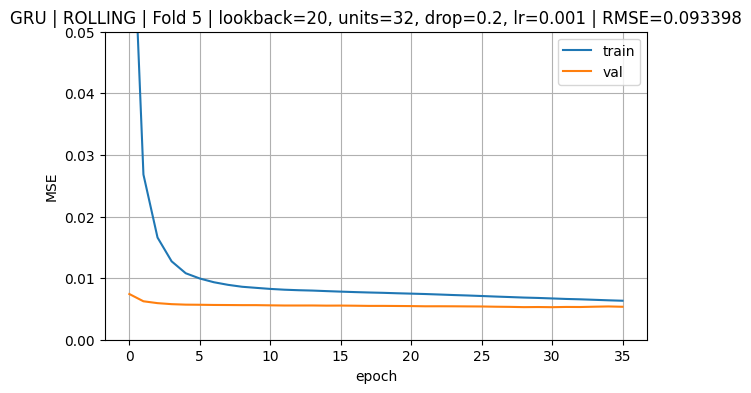

[GRU][rolling] fold 5/5 RMSE=0.093398

Summary: GRU rolling


,fold,rmse,n_train,n_test
0,1,0.141482,85468,24427
1,2,0.090850,85762,24651
2,3,0.112900,86142,24651
3,4,0.093405,86411,24656
4,5,0.093398,86685,24900


Mean RMSE: 0.10640698274149996 Std RMSE: 0.021521369720525416


In [57]:
# =========================
# GRU on RETURN — Rolling (ROBUSTNESS) using best config
# =========================
best_cfg_return = gru_summary_return.iloc[0].to_dict()

df_gru_return_rolling = run_gru_cv(
    panel_return_clean,
    scheme="rolling",
    n_splits=5,
    lookback=int(best_cfg_return["lookback"]),
    units=int(best_cfg_return["units"]),
    dropout=float(best_cfg_return["dropout"]),
    lr=float(best_cfg_return["lr"]),
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42,
    plot_curves=True
)


Run GRU on RISK (Expanding + Rolling)


GRU RISK config 1: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'lr': 0.001}


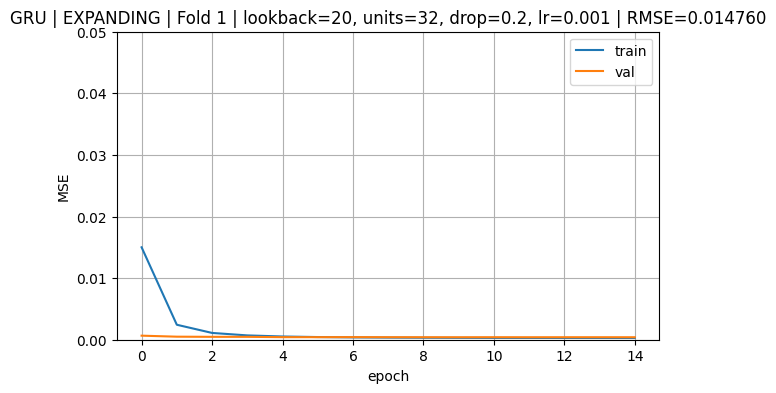

[GRU][expanding] fold 1/5 RMSE=0.014760


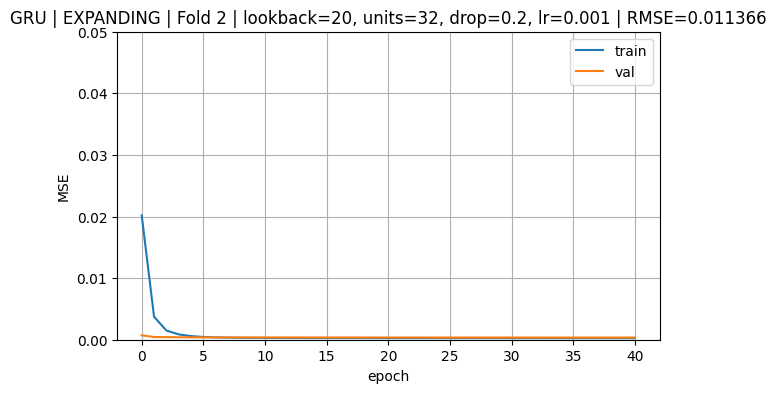

[GRU][expanding] fold 2/5 RMSE=0.011366


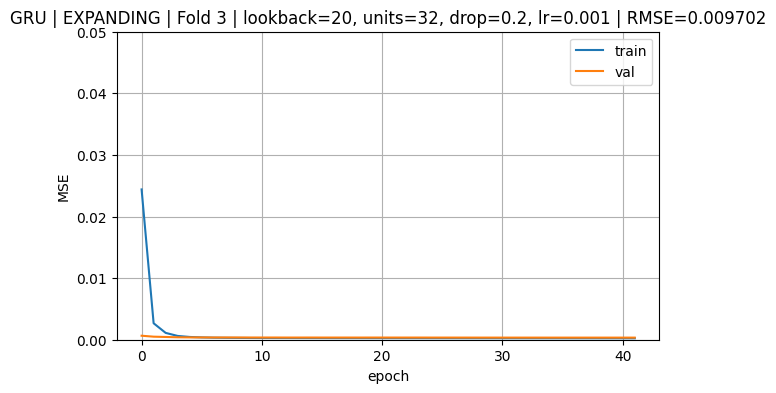

[GRU][expanding] fold 3/5 RMSE=0.009702


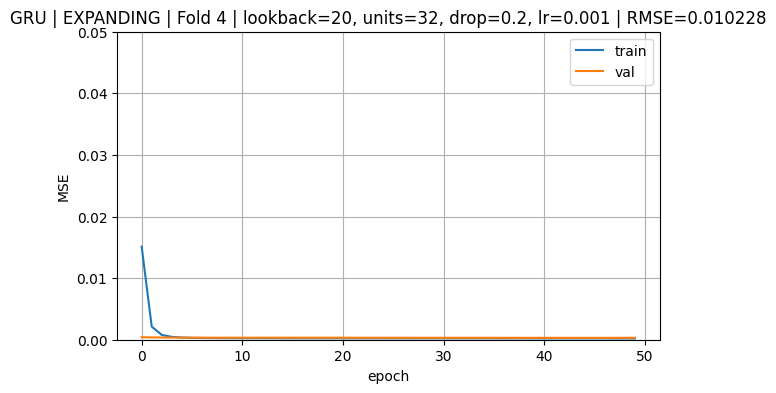

[GRU][expanding] fold 4/5 RMSE=0.010228


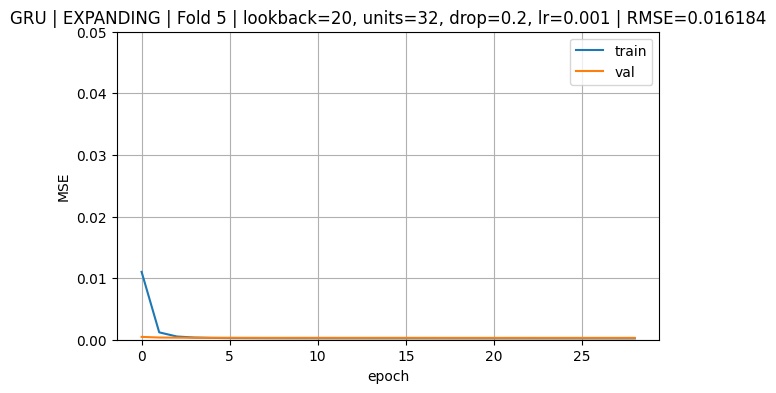

[GRU][expanding] fold 5/5 RMSE=0.016184

Summary: GRU expanding


,fold,rmse,n_train,n_test
0,1,0.014760,140000,16900
1,2,0.011366,158900,16900
2,3,0.009702,177800,16900
3,4,0.010228,196700,16900
4,5,0.016184,215600,16900


Mean RMSE: 0.012448071500963118 Std RMSE: 0.002869719613266103

GRU RISK config 2: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


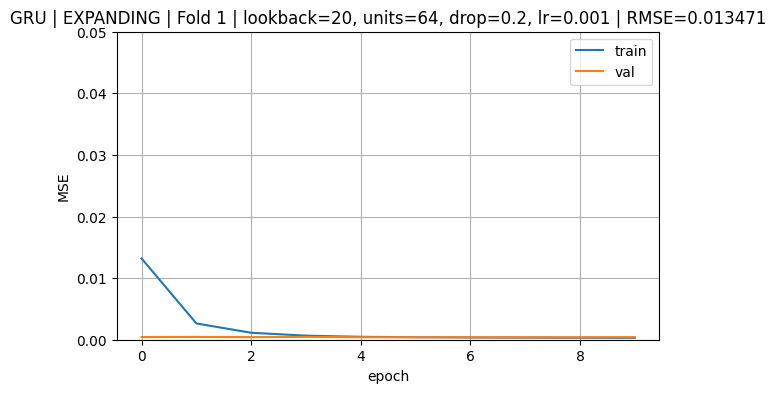

[GRU][expanding] fold 1/5 RMSE=0.013471


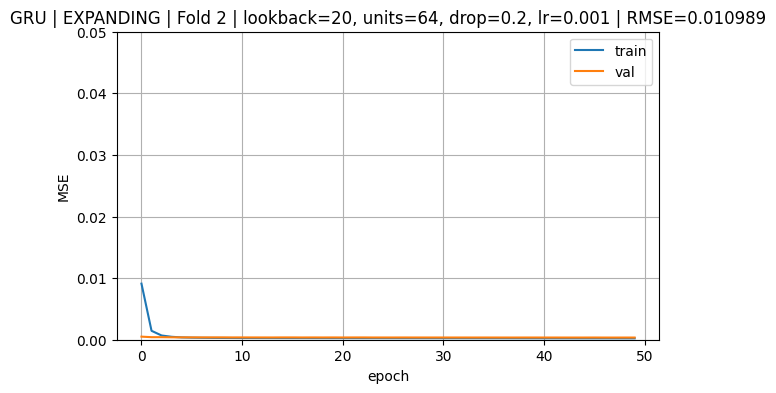

[GRU][expanding] fold 2/5 RMSE=0.010989


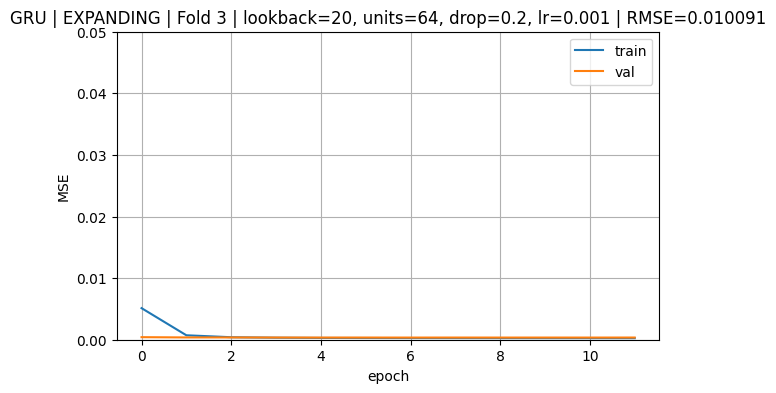

[GRU][expanding] fold 3/5 RMSE=0.010091


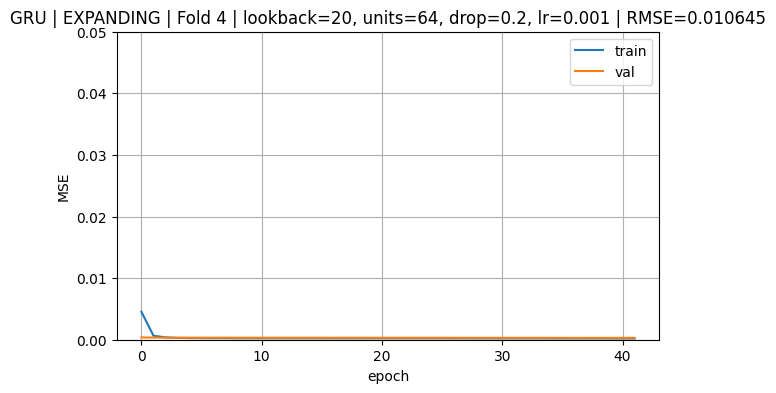

[GRU][expanding] fold 4/5 RMSE=0.010645


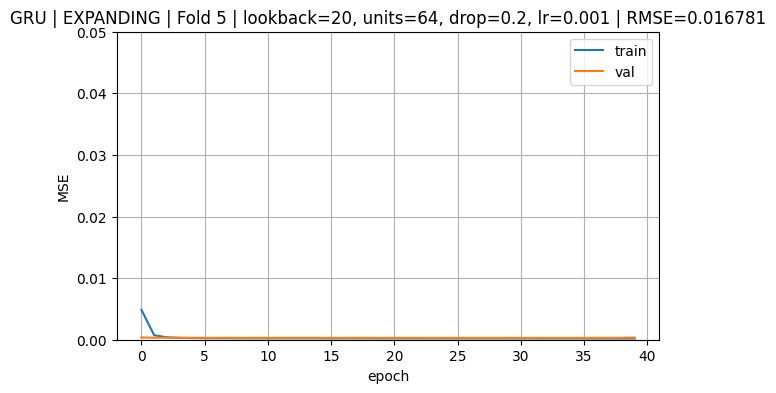

[GRU][expanding] fold 5/5 RMSE=0.016781

Summary: GRU expanding


,fold,rmse,n_train,n_test
0,1,0.013471,140000,16900
1,2,0.010989,158900,16900
2,3,0.010091,177800,16900
3,4,0.010645,196700,16900
4,5,0.016781,215600,16900


Mean RMSE: 0.01239553926566051 Std RMSE: 0.0027724195179839595

GRU RISK config 3: {'lookback': 30, 'units': 64, 'dropout': 0.2, 'lr': 0.001}


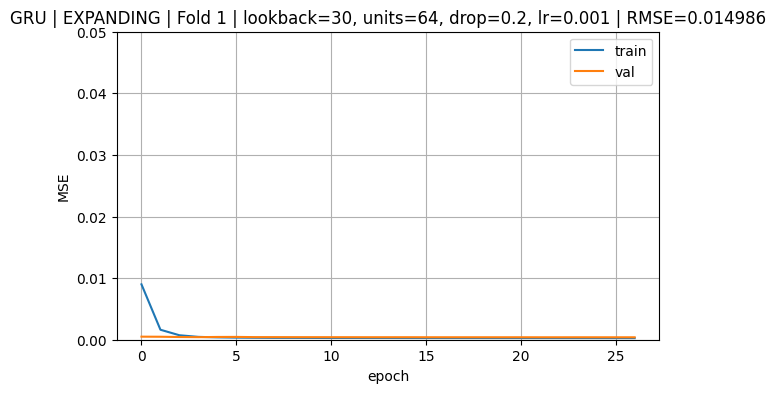

[GRU][expanding] fold 1/5 RMSE=0.014986


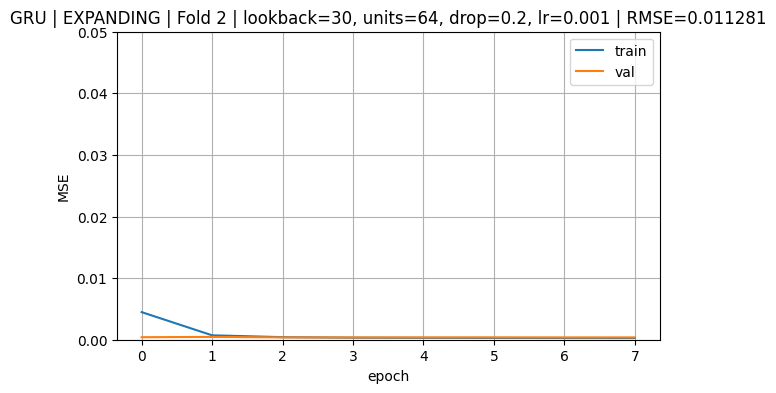

[GRU][expanding] fold 2/5 RMSE=0.011281


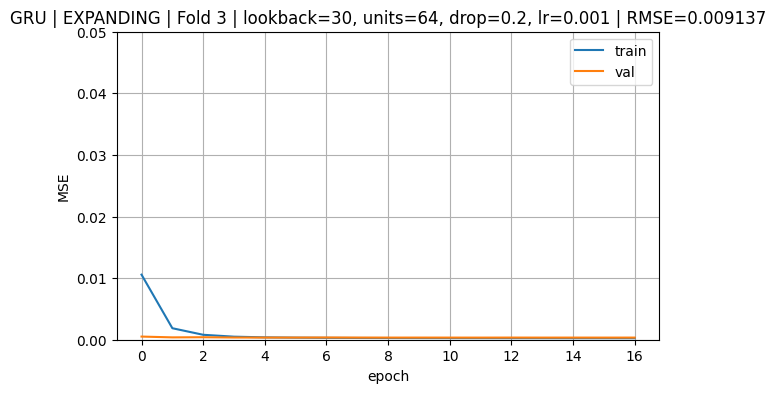

[GRU][expanding] fold 3/5 RMSE=0.009137


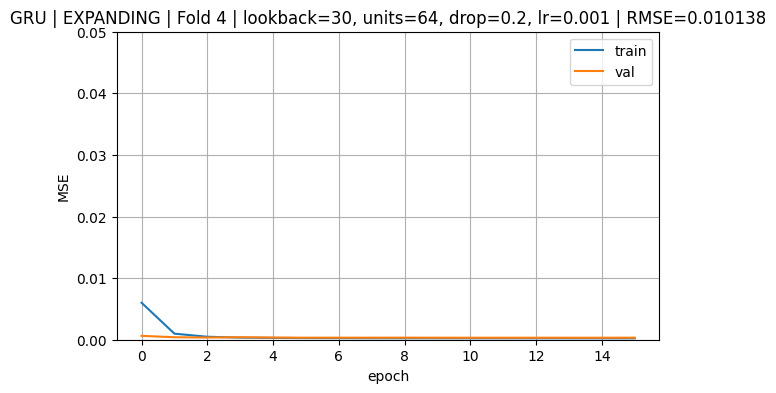

[GRU][expanding] fold 4/5 RMSE=0.010138


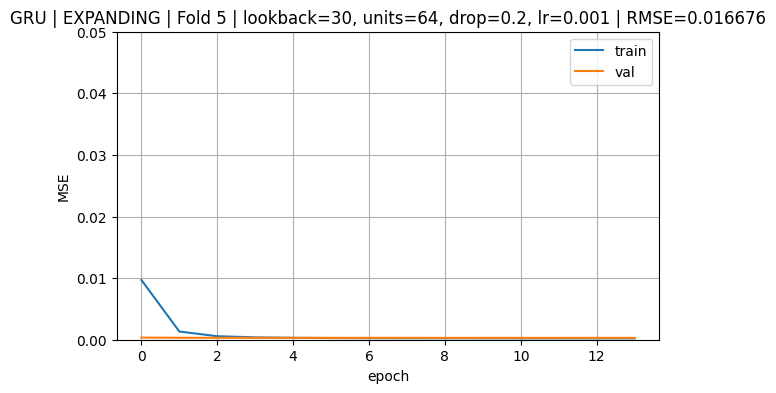

[GRU][expanding] fold 5/5 RMSE=0.016676

Summary: GRU expanding


,fold,rmse,n_train,n_test
0,1,0.014986,139000,15900
1,2,0.011281,157900,15900
2,3,0.009137,176800,15900
3,4,0.010138,195700,15900
4,5,0.016676,214600,15900


Mean RMSE: 0.01244337202825865 Std RMSE: 0.0032397317729712534

=== GRU RISK Summary (Expanding CV) ===


,config_id,lookback,units,dropout,lr,mean_rmse,std_rmse
1,2,20,64,0.2,0.001,0.012396,0.002772
2,3,30,64,0.2,0.001,0.012443,0.003240
0,1,20,32,0.2,0.001,0.012448,0.002870


In [58]:
# =========================
# GRU on RISK — Expanding (PRIMARY)
# =========================
gru_risk_results = []
for i, cfg in enumerate(GRU_GRID, start=1):
    print("\n" + "="*90)
    print(f"GRU RISK config {i}: {cfg}")
    print("="*90)

    df = run_gru_cv(
        panel_risk_clean,
        scheme="expanding",
        n_splits=5,
        lookback=cfg["lookback"],
        units=cfg["units"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        epochs=50,
        batch_size=512,
        patience=5,
        seed=42,
        plot_curves=True
    )
    gru_risk_results.append({
        "config_id": i,
        **cfg,
        "mean_rmse": df["rmse"].mean(),
        "std_rmse": df["rmse"].std()
    })

gru_summary_risk = pd.DataFrame(gru_risk_results).sort_values("mean_rmse")
print("\n=== GRU RISK Summary (Expanding CV) ===")
display(gru_summary_risk)


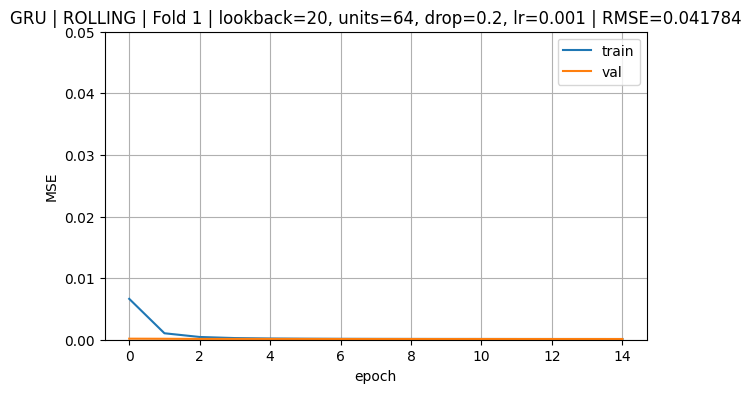

[GRU][rolling] fold 1/5 RMSE=0.041784


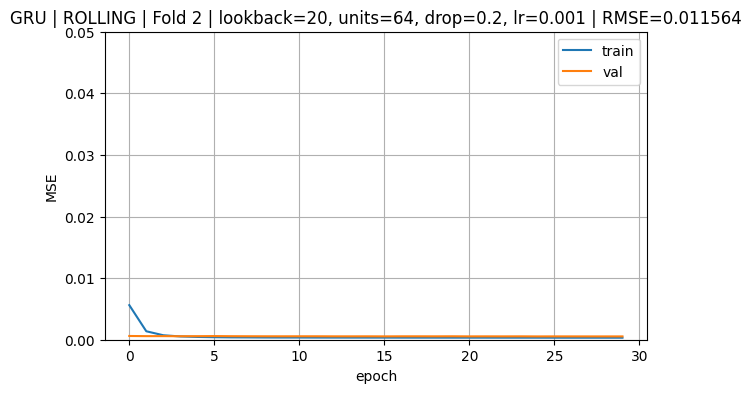

[GRU][rolling] fold 2/5 RMSE=0.011564


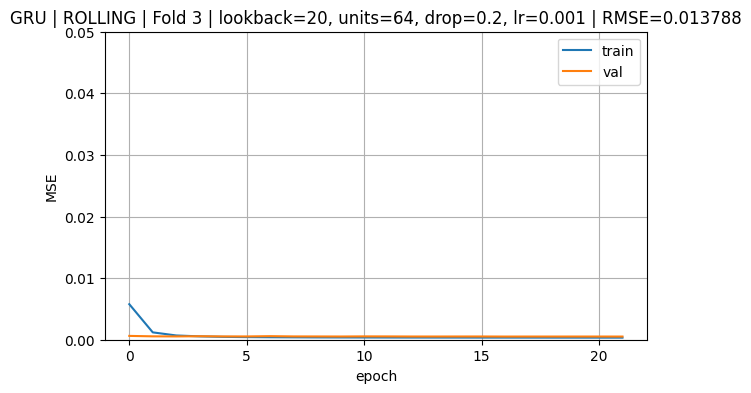

[GRU][rolling] fold 3/5 RMSE=0.013788


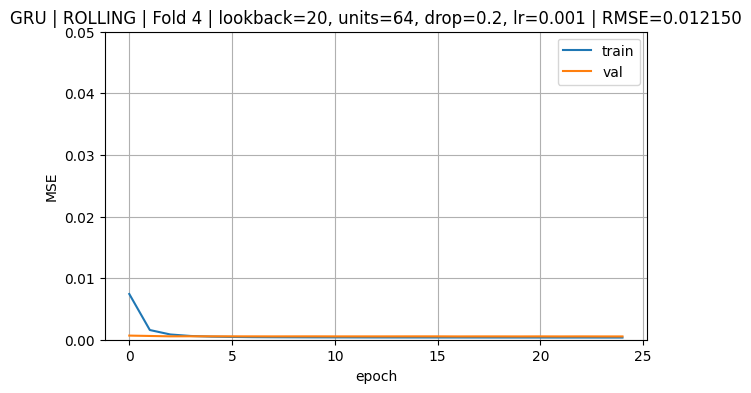

[GRU][rolling] fold 4/5 RMSE=0.012150


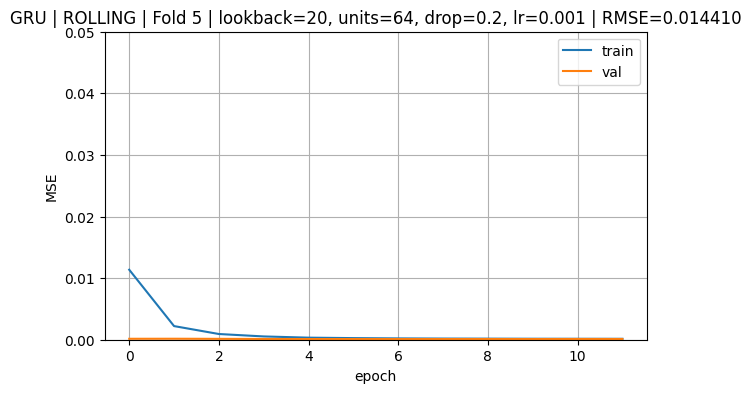

[GRU][rolling] fold 5/5 RMSE=0.014410

Summary: GRU rolling


,fold,rmse,n_train,n_test
0,1,0.041784,92700,26400
1,2,0.011564,92700,26400
2,3,0.013788,92700,26400
3,4,0.012150,92700,26400
4,5,0.014410,92700,26400


Mean RMSE: 0.018739245478504037 Std RMSE: 0.01293482442067621


In [59]:
# =========================
# GRU on RISK — Rolling (ROBUSTNESS) using best config
# =========================
best_cfg_risk = gru_summary_risk.iloc[0].to_dict()

df_gru_risk_rolling = run_gru_cv(
    panel_risk_clean,
    scheme="rolling",
    n_splits=5,
    lookback=int(best_cfg_risk["lookback"]),
    units=int(best_cfg_risk["units"]),
    dropout=float(best_cfg_risk["dropout"]),
    lr=float(best_cfg_risk["lr"]),
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42,
    plot_curves=True
)


**4. 1D-CNN**

CNN1D model builder

In [60]:
# =========================
# 1D-CNN: model builder
# =========================
def build_cnn1d_model(input_shape, filters=32, kernel_size=3, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu"),
        layers.Dropout(dropout),
        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model


Train/eval one fold + curve

In [61]:
# =========================
# 1D-CNN: train one fold + training curve
# =========================
def fit_cnn1d_one_fold(
    Xtr, ytr, Xte, yte,
    filters=32, kernel_size=3, dropout=0.2, lr=1e-3,
    epochs=50, batch_size=512, patience=5,
    seed=42, verbose=0,
    plot=True, title=""
):
    set_seed(seed)

    # fold-internal train/val split (last 10% = val)
    n = len(Xtr)
    cut = int(n * 0.9)
    X_train, y_train = Xtr[:cut], ytr[:cut]
    X_val,   y_val   = Xtr[cut:], ytr[cut:]

    model = build_cnn1d_model(
        input_shape=X_train.shape[1:],
        filters=filters,
        kernel_size=kernel_size,
        dropout=dropout,
        lr=lr
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose
    )

    pred = model.predict(Xte, verbose=0).ravel()
    fold_rmse = rmse(yte, pred)

    if plot:
        plot_fold_curve(hist, f"{title} | RMSE={fold_rmse:.6f}")

    return fold_rmse


CNN1D CV runner (Expanding / Rolling)

In [62]:
# =========================
# 1D-CNN: run CV on a panel
# =========================
def run_cnn1d_cv(
    panel_clean,
    scheme="expanding",
    n_splits=5,
    lookback=20,
    filters=32, kernel_size=3, dropout=0.2, lr=1e-3,
    epochs=50, batch_size=512, patience=5,
    seed=42,
    plot_curves=True
):
    if scheme == "expanding":
        folds = expanding_window_folds(panel_clean, n_splits=n_splits)
    elif scheme == "rolling":
        folds = rolling_window_folds(panel_clean, n_splits=n_splits)
    else:
        raise ValueError("scheme must be 'expanding' or 'rolling'")

    fold_rows = []

    for k, (train_dates, test_dates) in enumerate(folds, start=1):
        train_fold, test_fold = slice_by_dates(panel_clean, train_dates, test_dates)

        # sequence tensors per fold
        Xtr, ytr, Xte, yte = make_sequence_tensors(train_fold, test_fold, lookback=lookback)

        fold_rmse = fit_cnn1d_one_fold(
            Xtr, ytr, Xte, yte,
            filters=filters, kernel_size=kernel_size, dropout=dropout, lr=lr,
            epochs=epochs, batch_size=batch_size, patience=patience,
            seed=seed,
            verbose=0,
            plot=plot_curves,
            title=f"CNN1D | {scheme.upper()} | Fold {k} | lookback={lookback}, filt={filters}, k={kernel_size}, drop={dropout}, lr={lr}"
        )

        fold_rows.append({
            "fold": k,
            "rmse": fold_rmse,
            "n_train": len(Xtr),
            "n_test": len(Xte)
        })

        print(f"[CNN1D][{scheme}] fold {k}/{len(folds)} RMSE={fold_rmse:.6f}")

    df = pd.DataFrame(fold_rows)
    print("\nSummary: CNN1D", scheme)
    display(df)
    print("Mean RMSE:", df["rmse"].mean(), "Std RMSE:", df["rmse"].std())
    return df


CNN grid (3 configs)

In [63]:
# =========================
# 1D-CNN grid (3 configs)
# =========================
CNN_GRID = [
    {"lookback": 20, "filters": 16, "kernel_size": 3, "dropout": 0.2, "lr": 1e-3},
    {"lookback": 20, "filters": 32, "kernel_size": 3, "dropout": 0.2, "lr": 1e-3},
    {"lookback": 30, "filters": 32, "kernel_size": 5, "dropout": 0.2, "lr": 1e-3},
]


Run CNN1D on RETURN (Expanding + Rolling)


CNN1D RETURN config 1: {'lookback': 20, 'filters': 16, 'kernel_size': 3, 'dropout': 0.2, 'lr': 0.001}


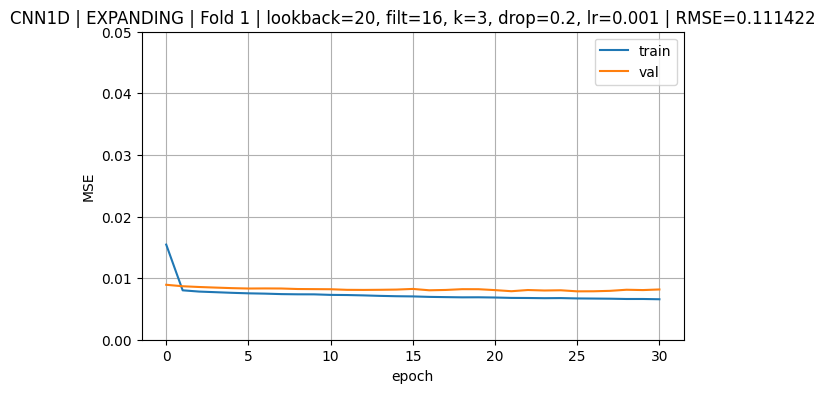

[CNN1D][expanding] fold 1/5 RMSE=0.111422


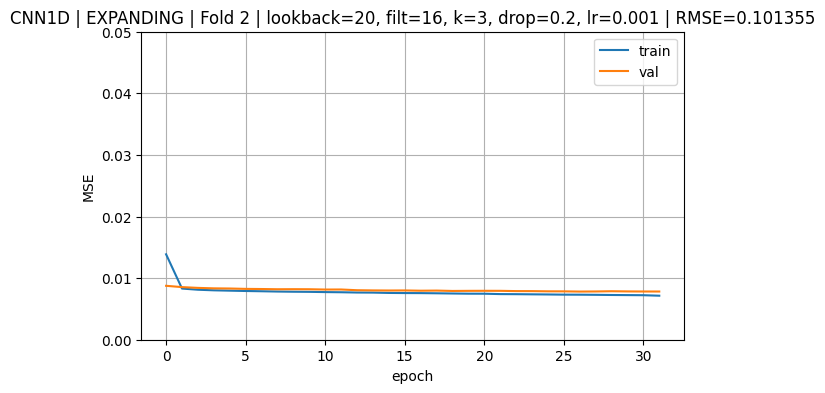

[CNN1D][expanding] fold 2/5 RMSE=0.101355


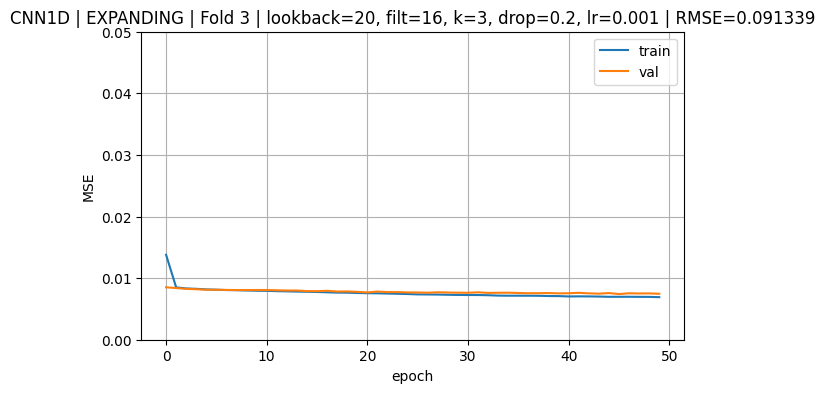

[CNN1D][expanding] fold 3/5 RMSE=0.091339


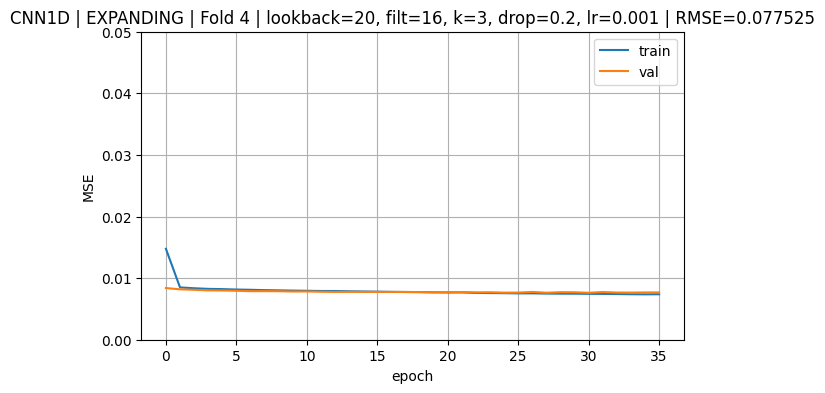

[CNN1D][expanding] fold 4/5 RMSE=0.077525


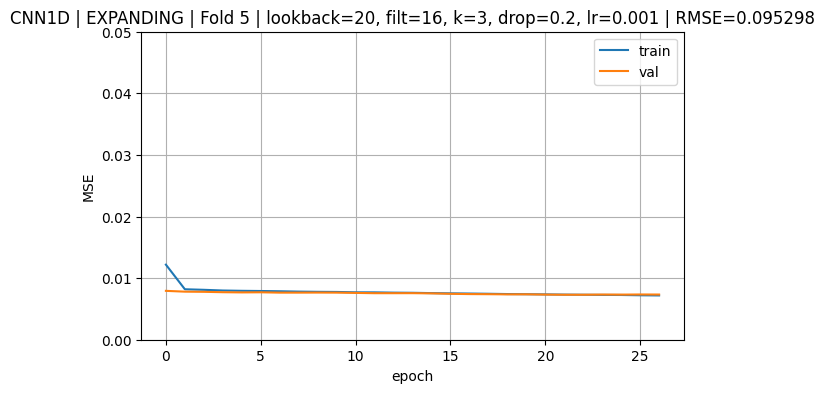

[CNN1D][expanding] fold 5/5 RMSE=0.095298

Summary: CNN1D expanding


,fold,rmse,n_train,n_test
0,1,0.111422,129576,15741
1,2,0.101355,147297,15741
2,3,0.091339,165018,15741
3,4,0.077525,182739,15834
4,5,0.095298,200553,15900


Mean RMSE: 0.09538798944849308 Std RMSE: 0.012531563094587132

CNN1D RETURN config 2: {'lookback': 20, 'filters': 32, 'kernel_size': 3, 'dropout': 0.2, 'lr': 0.001}


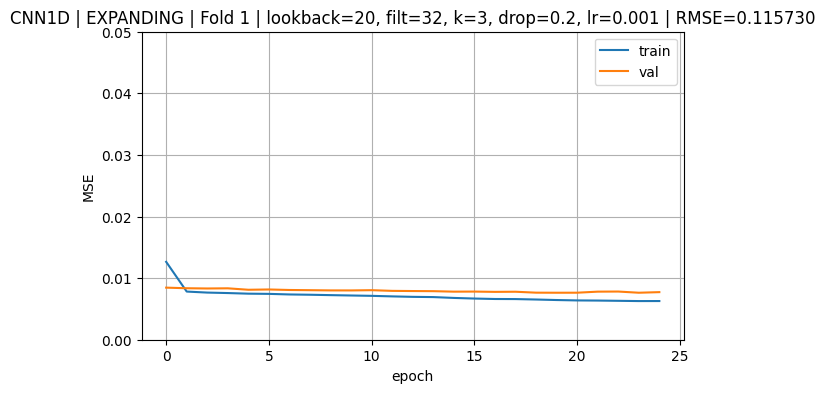

[CNN1D][expanding] fold 1/5 RMSE=0.115730


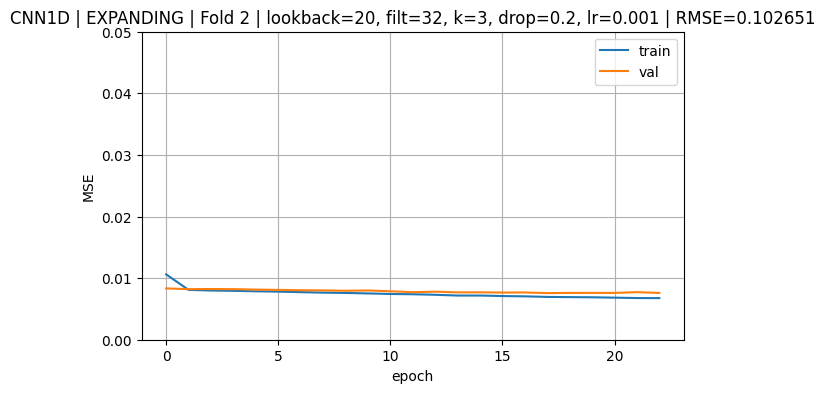

[CNN1D][expanding] fold 2/5 RMSE=0.102651


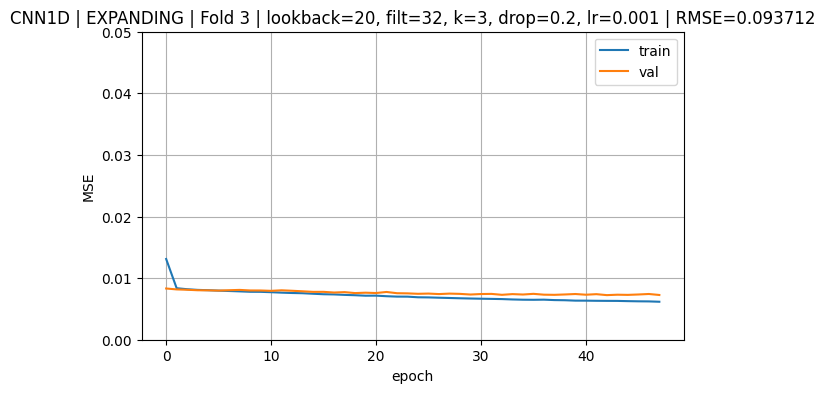

[CNN1D][expanding] fold 3/5 RMSE=0.093712


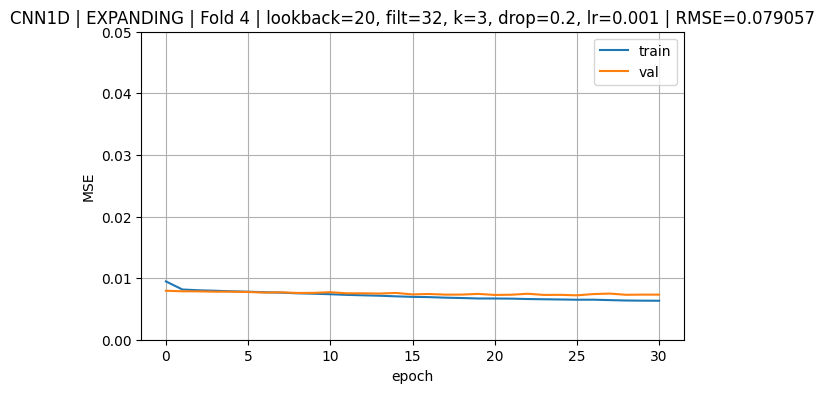

[CNN1D][expanding] fold 4/5 RMSE=0.079057


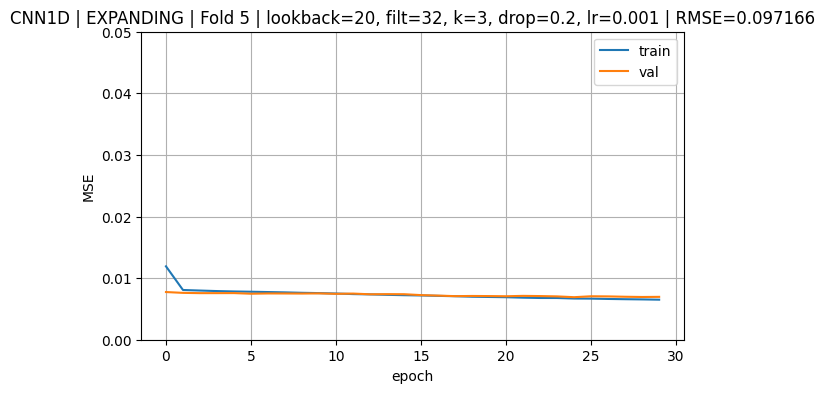

[CNN1D][expanding] fold 5/5 RMSE=0.097166

Summary: CNN1D expanding


,fold,rmse,n_train,n_test
0,1,0.115730,129576,15741
1,2,0.102651,147297,15741
2,3,0.093712,165018,15741
3,4,0.079057,182739,15834
4,5,0.097166,200553,15900


Mean RMSE: 0.09766311375236399 Std RMSE: 0.013354132190956913

CNN1D RETURN config 3: {'lookback': 30, 'filters': 32, 'kernel_size': 5, 'dropout': 0.2, 'lr': 0.001}


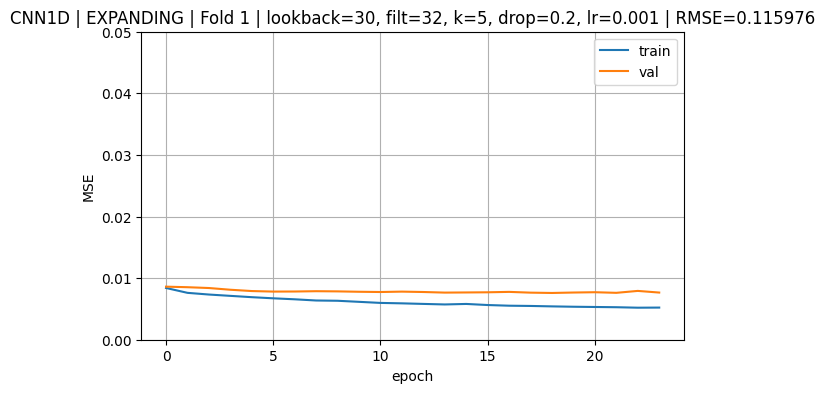

[CNN1D][expanding] fold 1/5 RMSE=0.115976


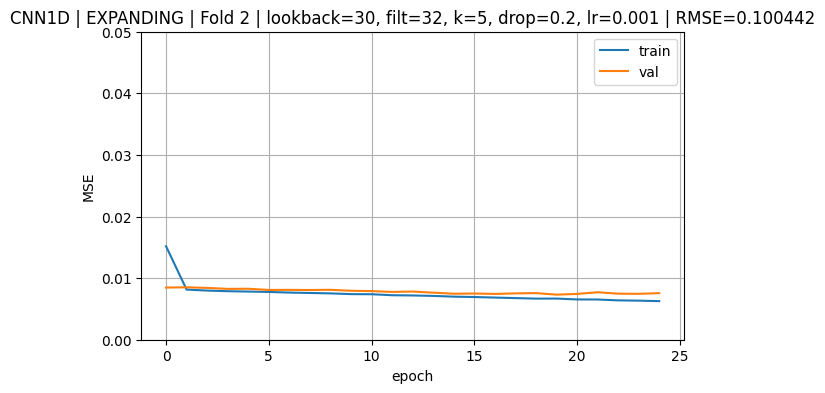

[CNN1D][expanding] fold 2/5 RMSE=0.100442


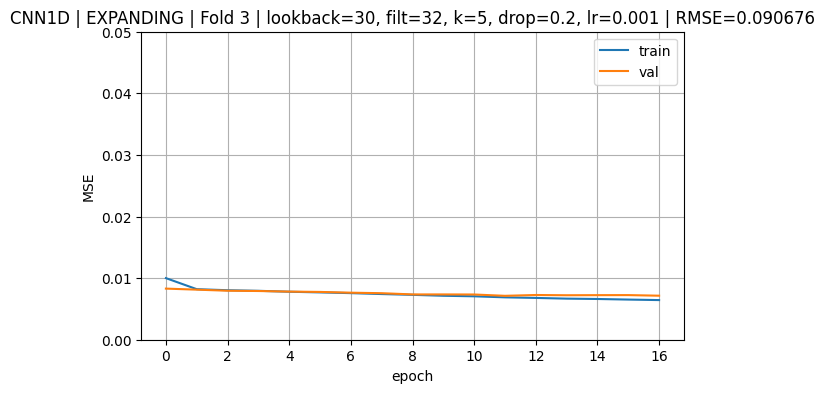

[CNN1D][expanding] fold 3/5 RMSE=0.090676


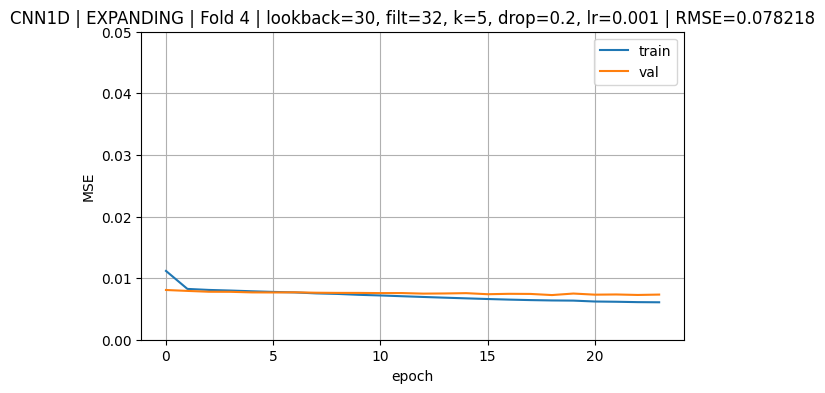

[CNN1D][expanding] fold 4/5 RMSE=0.078218


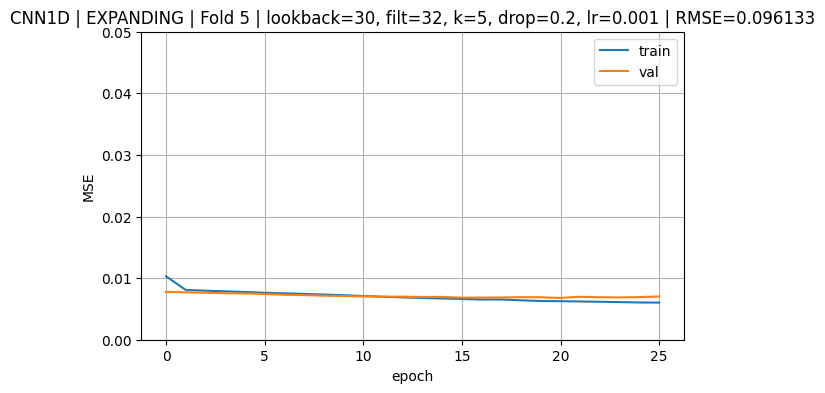

[CNN1D][expanding] fold 5/5 RMSE=0.096133

Summary: CNN1D expanding


,fold,rmse,n_train,n_test
0,1,0.115976,128586,14751
1,2,0.100442,146307,14751
2,3,0.090676,164028,14751
3,4,0.078218,181749,14834
4,5,0.096133,199553,14900


Mean RMSE: 0.09628925467692397 Std RMSE: 0.013810536679165087

=== CNN1D RETURN Summary (Expanding CV) ===


,config_id,lookback,filters,kernel_size,dropout,lr,mean_rmse,std_rmse
0,1,20,16,3,0.2,0.001,0.095388,0.012532
2,3,30,32,5,0.2,0.001,0.096289,0.013811
1,2,20,32,3,0.2,0.001,0.097663,0.013354


In [64]:
# =========================
# CNN1D on RETURN — Expanding (PRIMARY)
# =========================
cnn_return_results = []
for i, cfg in enumerate(CNN_GRID, start=1):
    print("\n" + "="*90)
    print(f"CNN1D RETURN config {i}: {cfg}")
    print("="*90)

    df = run_cnn1d_cv(
        panel_return_clean,
        scheme="expanding",
        n_splits=5,
        lookback=cfg["lookback"],
        filters=cfg["filters"],
        kernel_size=cfg["kernel_size"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        epochs=50,
        batch_size=512,
        patience=5,
        seed=42,
        plot_curves=True
    )

    cnn_return_results.append({
        "config_id": i,
        **cfg,
        "mean_rmse": df["rmse"].mean(),
        "std_rmse": df["rmse"].std()
    })

cnn_summary_return = pd.DataFrame(cnn_return_results).sort_values("mean_rmse")
print("\n=== CNN1D RETURN Summary (Expanding CV) ===")
display(cnn_summary_return)


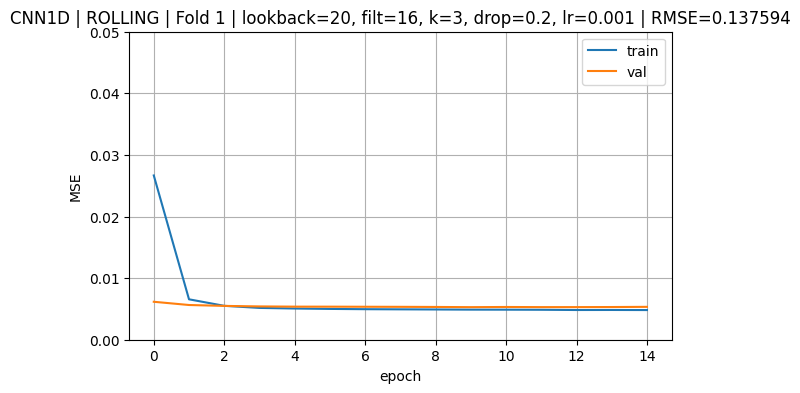

[CNN1D][rolling] fold 1/5 RMSE=0.137594


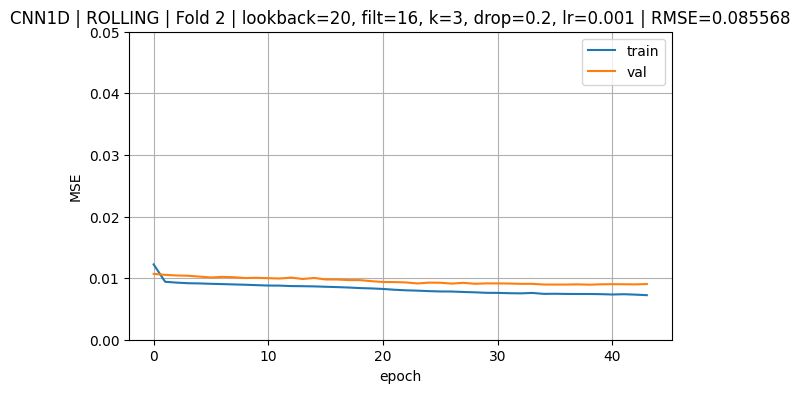

[CNN1D][rolling] fold 2/5 RMSE=0.085568


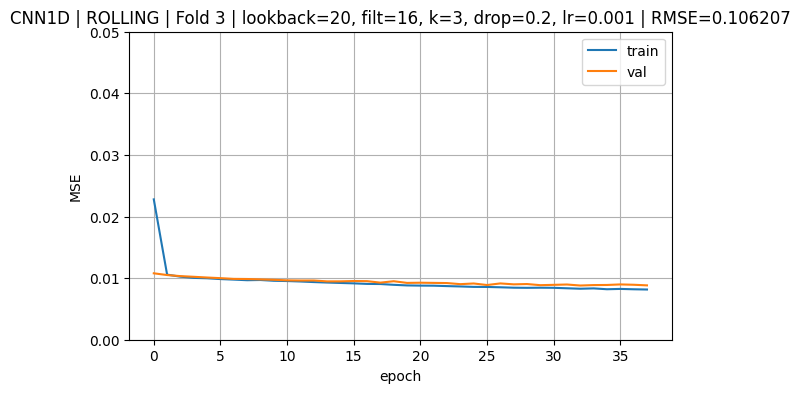

[CNN1D][rolling] fold 3/5 RMSE=0.106207


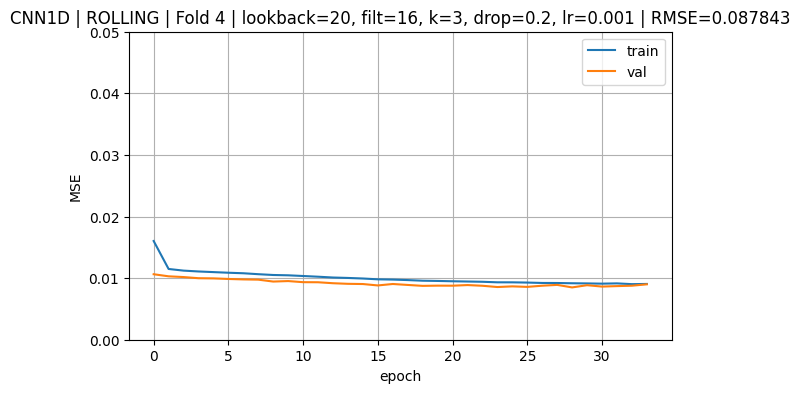

[CNN1D][rolling] fold 4/5 RMSE=0.087843


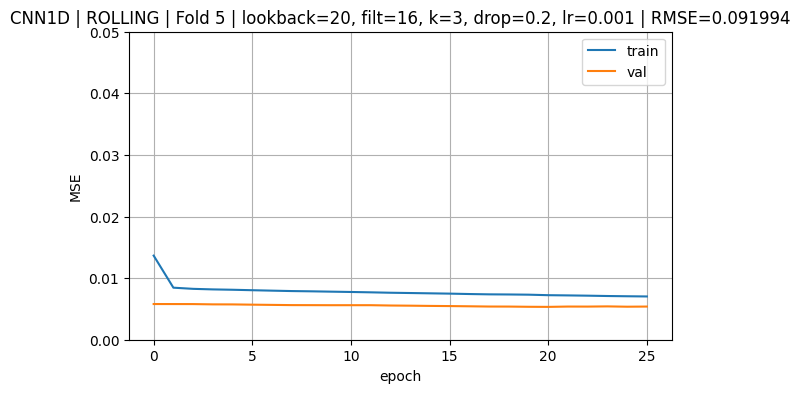

[CNN1D][rolling] fold 5/5 RMSE=0.091994

Summary: CNN1D rolling


,fold,rmse,n_train,n_test
0,1,0.137594,85468,24427
1,2,0.085568,85762,24651
2,3,0.106207,86142,24651
3,4,0.087843,86411,24656
4,5,0.091994,86685,24900


Mean RMSE: 0.10184113157982069 Std RMSE: 0.021535350899614097


In [65]:
# =========================
# CNN1D on RETURN — Rolling (ROBUSTNESS) using best config
# =========================
best_cfg_return = cnn_summary_return.iloc[0].to_dict()

df_cnn_return_rolling = run_cnn1d_cv(
    panel_return_clean,
    scheme="rolling",
    n_splits=5,
    lookback=int(best_cfg_return["lookback"]),
    filters=int(best_cfg_return["filters"]),
    kernel_size=int(best_cfg_return["kernel_size"]),
    dropout=float(best_cfg_return["dropout"]),
    lr=float(best_cfg_return["lr"]),
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42,
    plot_curves=True
)


Run CNN1D on RISK (Expanding + Rolling)


CNN1D RISK config 1: {'lookback': 20, 'filters': 16, 'kernel_size': 3, 'dropout': 0.2, 'lr': 0.001}


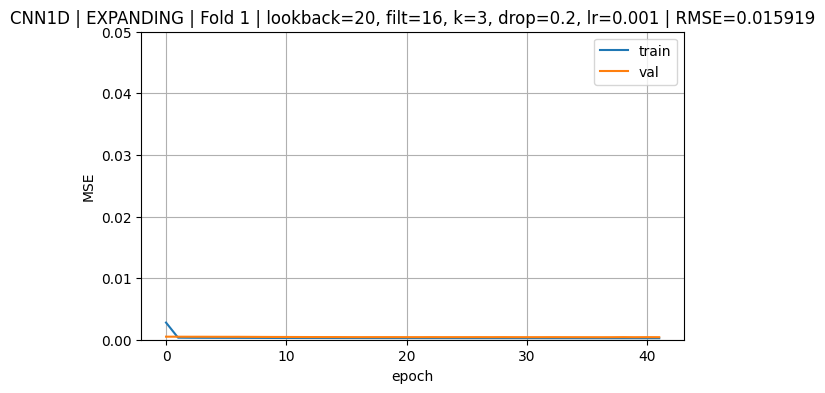

[CNN1D][expanding] fold 1/5 RMSE=0.015919


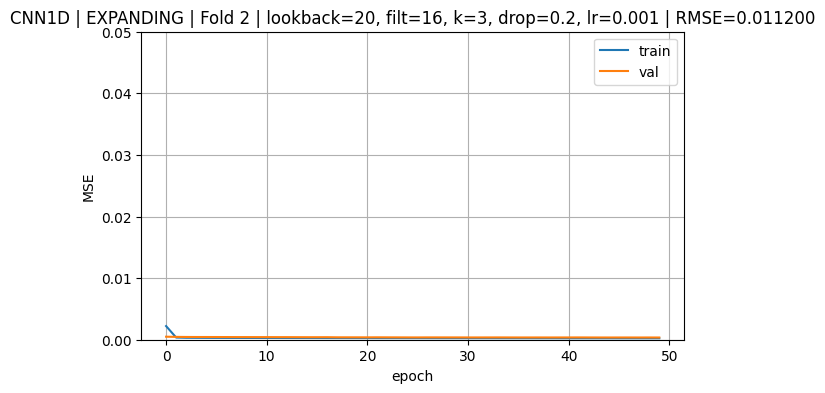

[CNN1D][expanding] fold 2/5 RMSE=0.011200


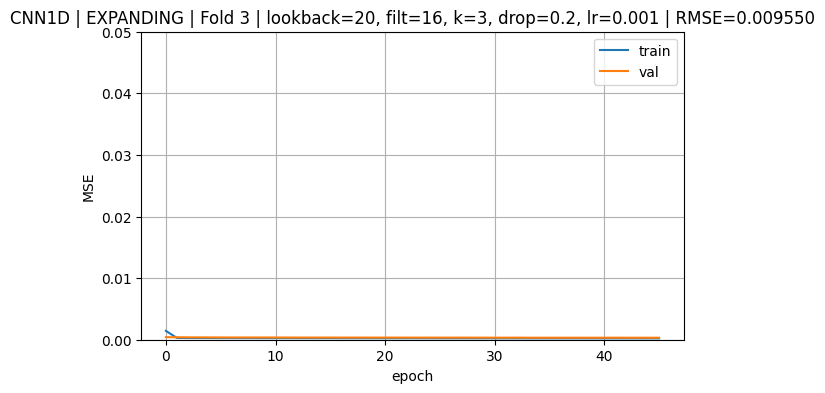

[CNN1D][expanding] fold 3/5 RMSE=0.009550


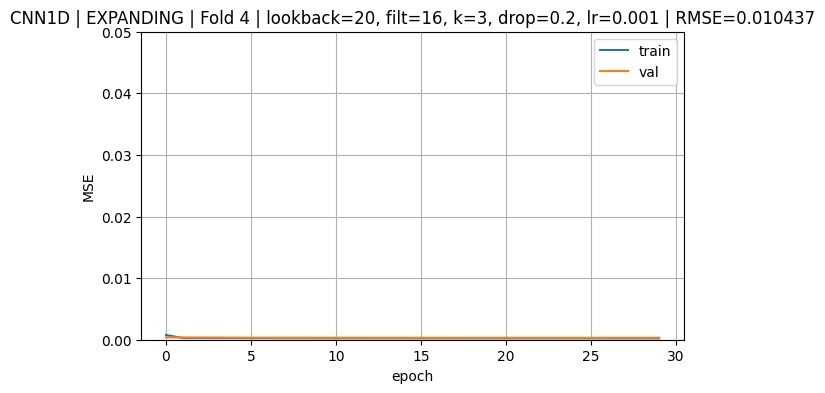

[CNN1D][expanding] fold 4/5 RMSE=0.010437


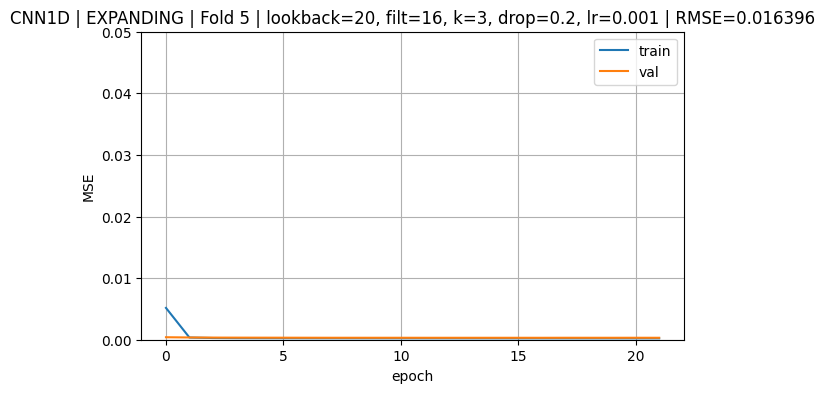

[CNN1D][expanding] fold 5/5 RMSE=0.016396

Summary: CNN1D expanding


,fold,rmse,n_train,n_test
0,1,0.015919,140000,16900
1,2,0.011200,158900,16900
2,3,0.009550,177800,16900
3,4,0.010437,196700,16900
4,5,0.016396,215600,16900


Mean RMSE: 0.012700502118665852 Std RMSE: 0.003214176437361736

CNN1D RISK config 2: {'lookback': 20, 'filters': 32, 'kernel_size': 3, 'dropout': 0.2, 'lr': 0.001}


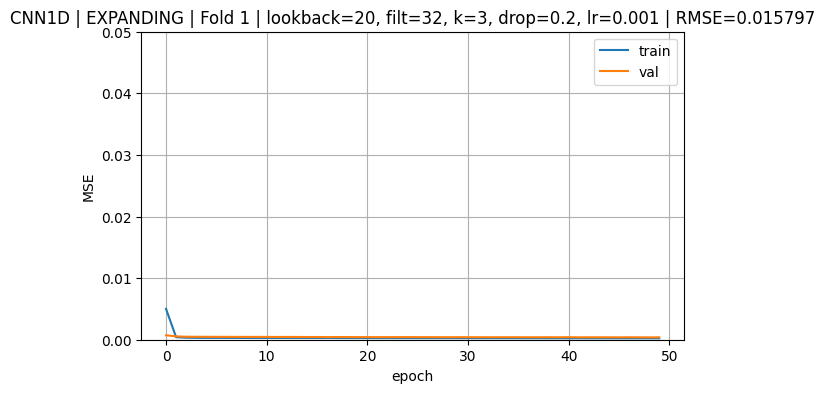

[CNN1D][expanding] fold 1/5 RMSE=0.015797


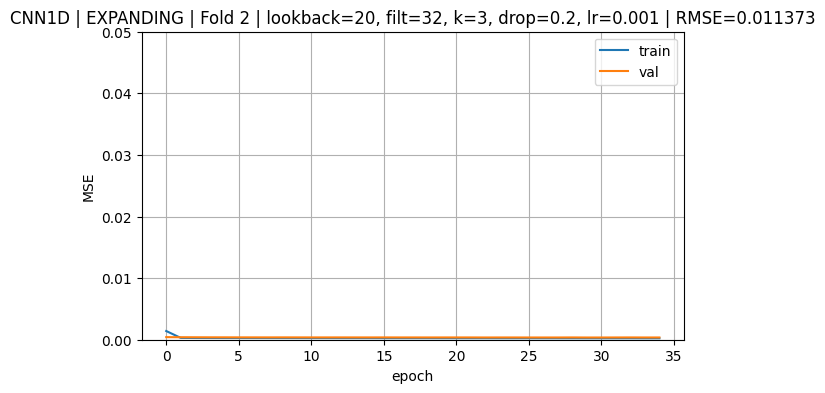

[CNN1D][expanding] fold 2/5 RMSE=0.011373


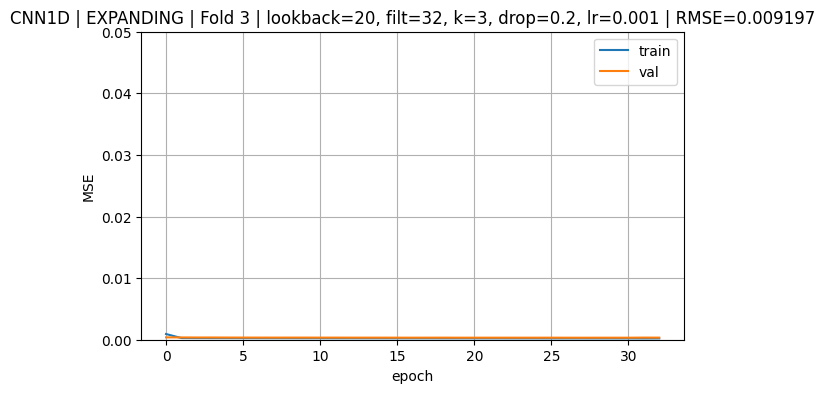

[CNN1D][expanding] fold 3/5 RMSE=0.009197


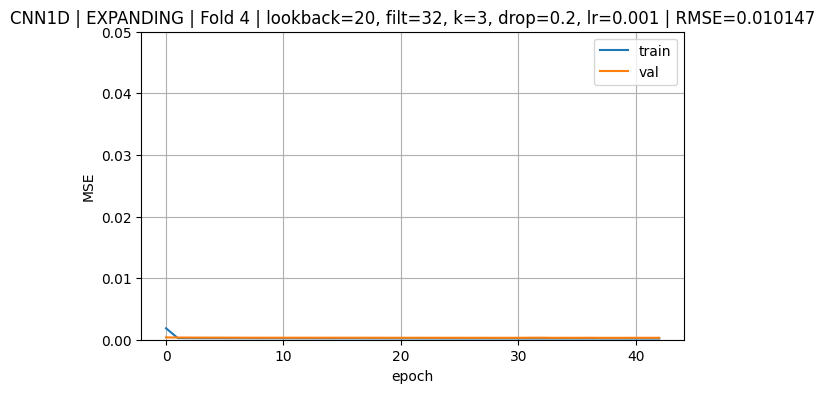

[CNN1D][expanding] fold 4/5 RMSE=0.010147


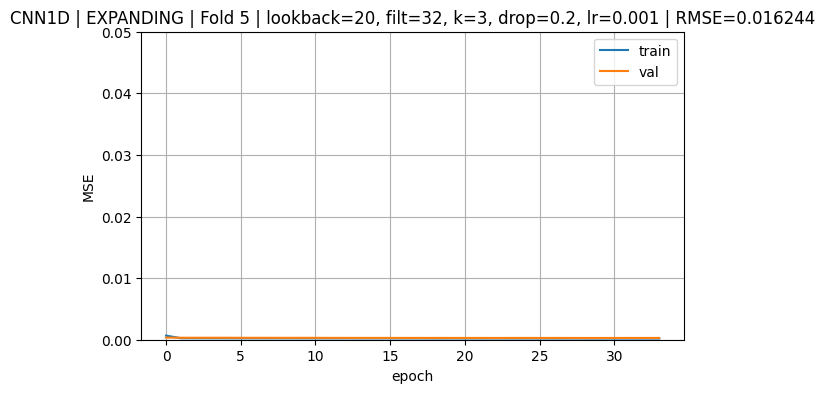

[CNN1D][expanding] fold 5/5 RMSE=0.016244

Summary: CNN1D expanding


,fold,rmse,n_train,n_test
0,1,0.015797,140000,16900
1,2,0.011373,158900,16900
2,3,0.009197,177800,16900
3,4,0.010147,196700,16900
4,5,0.016244,215600,16900


Mean RMSE: 0.012551459257837318 Std RMSE: 0.003263089488750663

CNN1D RISK config 3: {'lookback': 30, 'filters': 32, 'kernel_size': 5, 'dropout': 0.2, 'lr': 0.001}


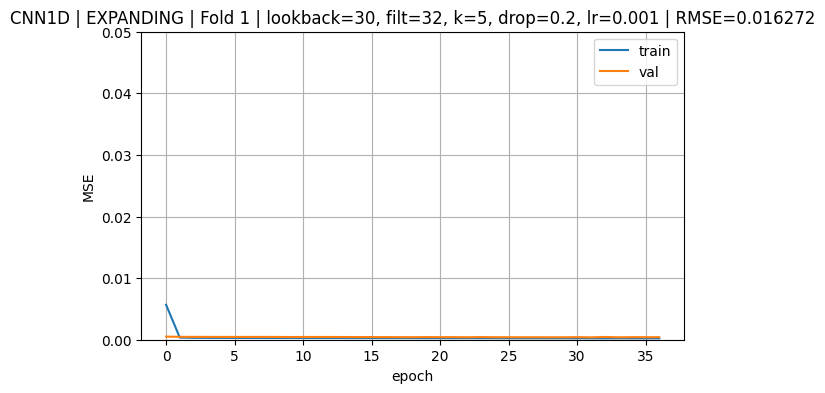

[CNN1D][expanding] fold 1/5 RMSE=0.016272


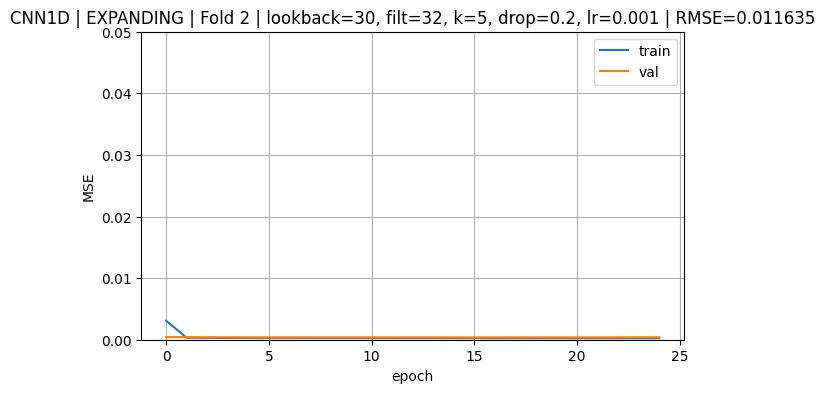

[CNN1D][expanding] fold 2/5 RMSE=0.011635


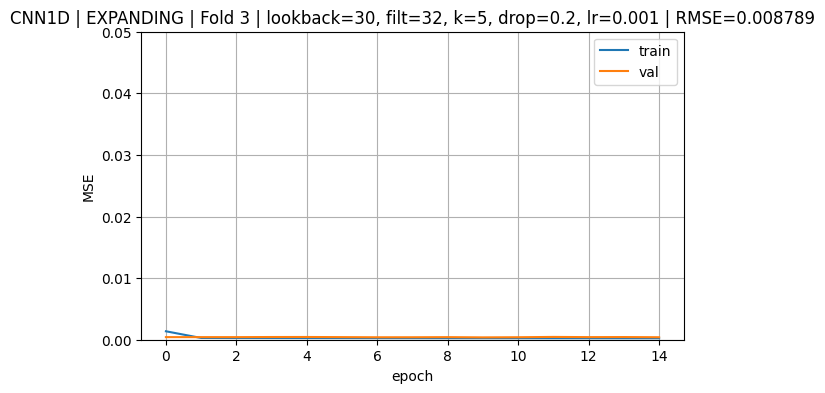

[CNN1D][expanding] fold 3/5 RMSE=0.008789


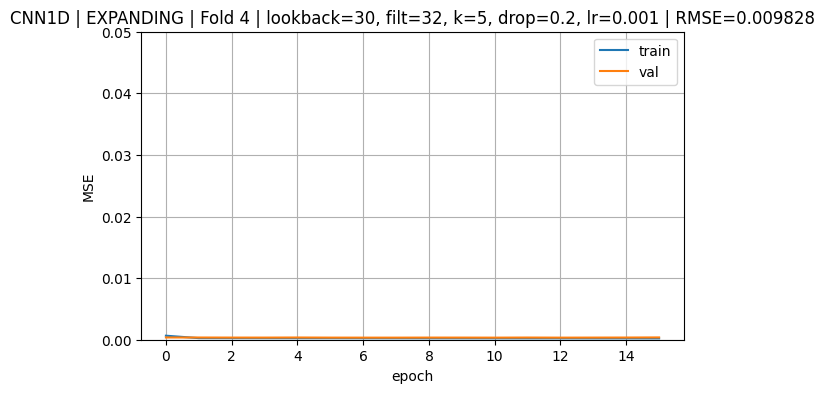

[CNN1D][expanding] fold 4/5 RMSE=0.009828


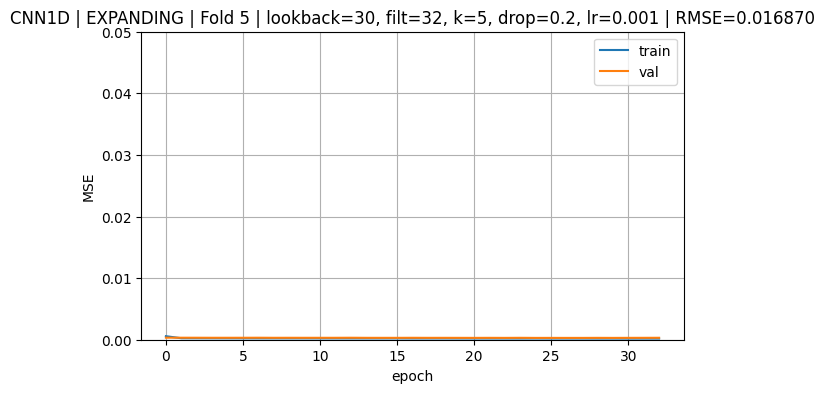

[CNN1D][expanding] fold 5/5 RMSE=0.016870

Summary: CNN1D expanding


,fold,rmse,n_train,n_test
0,1,0.016272,139000,15900
1,2,0.011635,157900,15900
2,3,0.008789,176800,15900
3,4,0.009828,195700,15900
4,5,0.016870,214600,15900


Mean RMSE: 0.0126786669582269 Std RMSE: 0.0037022071794317905

=== CNN1D RISK Summary (Expanding CV) ===


,config_id,lookback,filters,kernel_size,dropout,lr,mean_rmse,std_rmse
1,2,20,32,3,0.2,0.001,0.012551,0.003263
2,3,30,32,5,0.2,0.001,0.012679,0.003702
0,1,20,16,3,0.2,0.001,0.012701,0.003214


In [66]:
# =========================
# CNN1D on RISK — Expanding (PRIMARY)
# =========================
cnn_risk_results = []
for i, cfg in enumerate(CNN_GRID, start=1):
    print("\n" + "="*90)
    print(f"CNN1D RISK config {i}: {cfg}")
    print("="*90)

    df = run_cnn1d_cv(
        panel_risk_clean,
        scheme="expanding",
        n_splits=5,
        lookback=cfg["lookback"],
        filters=cfg["filters"],
        kernel_size=cfg["kernel_size"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        epochs=50,
        batch_size=512,
        patience=5,
        seed=42,
        plot_curves=True
    )

    cnn_risk_results.append({
        "config_id": i,
        **cfg,
        "mean_rmse": df["rmse"].mean(),
        "std_rmse": df["rmse"].std()
    })

cnn_summary_risk = pd.DataFrame(cnn_risk_results).sort_values("mean_rmse")
print("\n=== CNN1D RISK Summary (Expanding CV) ===")
display(cnn_summary_risk)


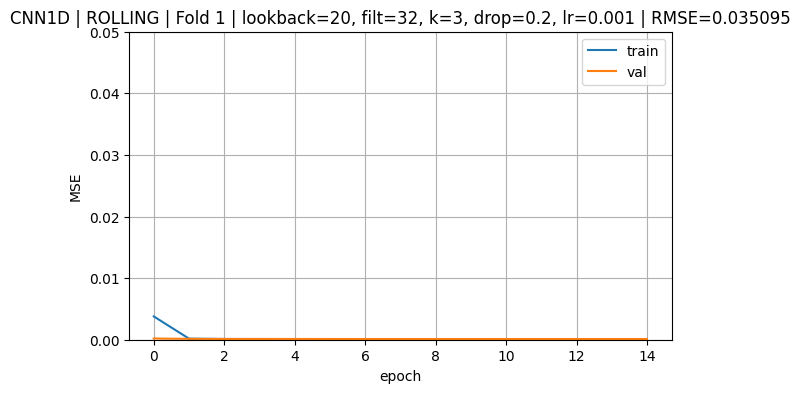

[CNN1D][rolling] fold 1/5 RMSE=0.035095


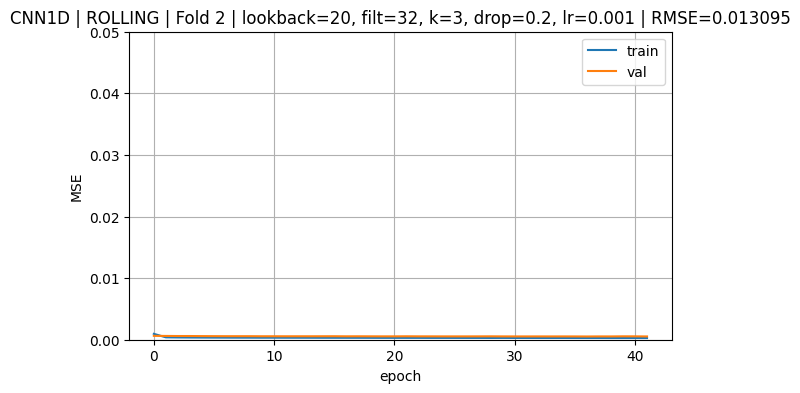

[CNN1D][rolling] fold 2/5 RMSE=0.013095


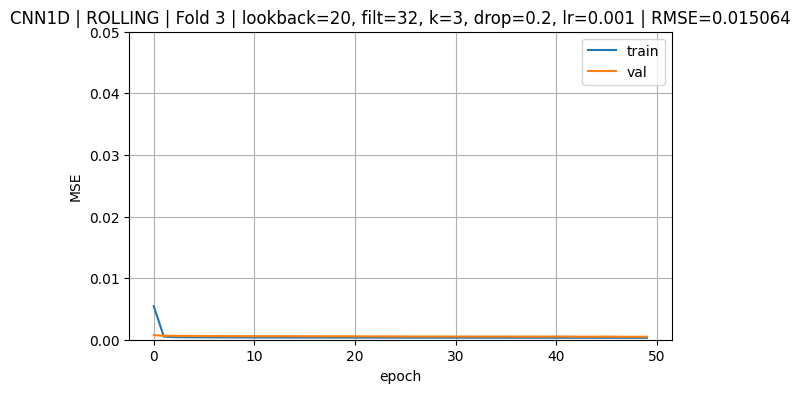

[CNN1D][rolling] fold 3/5 RMSE=0.015064


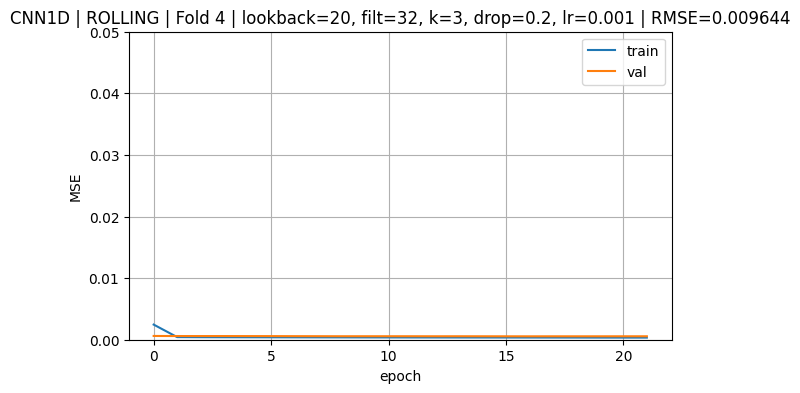

[CNN1D][rolling] fold 4/5 RMSE=0.009644


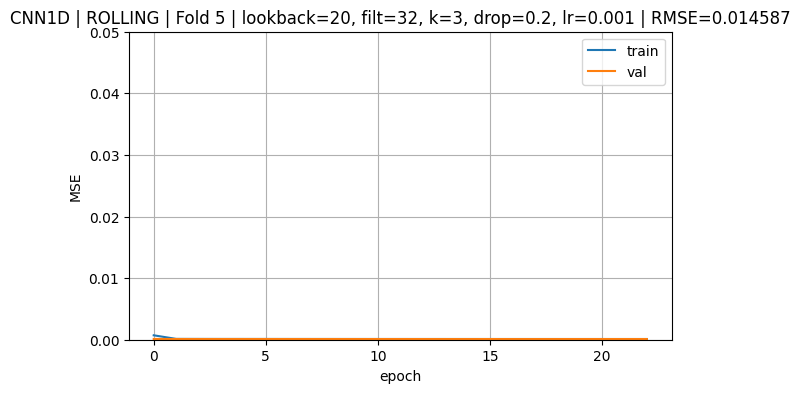

[CNN1D][rolling] fold 5/5 RMSE=0.014587

Summary: CNN1D rolling


,fold,rmse,n_train,n_test
0,1,0.035095,92700,26400
1,2,0.013095,92700,26400
2,3,0.015064,92700,26400
3,4,0.009644,92700,26400
4,5,0.014587,92700,26400


Mean RMSE: 0.017497115324835215 Std RMSE: 0.010063830189280053


In [67]:
# =========================
# CNN1D on RISK — Rolling (ROBUSTNESS) using best config
# =========================
best_cfg_risk = cnn_summary_risk.iloc[0].to_dict()

df_cnn_risk_rolling = run_cnn1d_cv(
    panel_risk_clean,
    scheme="rolling",
    n_splits=5,
    lookback=int(best_cfg_risk["lookback"]),
    filters=int(best_cfg_risk["filters"]),
    kernel_size=int(best_cfg_risk["kernel_size"]),
    dropout=float(best_cfg_risk["dropout"]),
    lr=float(best_cfg_risk["lr"]),
    epochs=50,
    batch_size=512,
    patience=5,
    seed=42,
    plot_curves=True
)


**5. BNN**

BNN (MC Dropout) model builder

In [68]:
# =========================
# BNN (MC Dropout): model builder
# =========================
def build_bnn_mc_dropout(input_shape, hidden=(64, 32), dropout=0.3, lr=1e-3):
    # input_shape for tabular = (n_features,)
    inp = layers.Input(shape=input_shape)
    x = inp
    for h in hidden:
        x = layers.Dense(h, activation="relu")(x)
        x = layers.Dropout(dropout)(x)  # keep dropout active at inference for MC sampling
    out = layers.Dense(1)(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model


MC prediction helper (mean + std)

In [69]:
# =========================
# BNN (MC Dropout): predictive mean and std
# =========================
def mc_predict(model, X, mc_samples=30):
    preds = []
    for _ in range(mc_samples):
        # training=True keeps dropout active at inference
        preds.append(model(X, training=True).numpy().ravel())
    preds = np.vstack(preds)
    mean = preds.mean(axis=0)
    std  = preds.std(axis=0)
    return mean, std


Fit one fold + curve + uncertainty

In [70]:
# =========================
# BNN: train one fold + training curve + fold RMSE + avg uncertainty
# =========================
def fit_bnn_one_fold(
    Xtr, ytr, Xte, yte,
    hidden=(64, 32), dropout=0.3, lr=1e-3,
    epochs=50, batch_size=1024, patience=5,
    seed=42, verbose=0,
    plot=True, title="",
    mc_samples=30
):
    set_seed(seed)

    # fold-internal train/val split (last 10% = val)
    n = len(Xtr)
    cut = int(n * 0.9)
    X_train, y_train = Xtr[:cut], ytr[:cut]
    X_val,   y_val   = Xtr[cut:], ytr[cut:]

    model = build_bnn_mc_dropout(
        input_shape=X_train.shape[1:],
        hidden=hidden,
        dropout=dropout,
        lr=lr
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose
    )

    # MC predictions
    pred_mean, pred_std = mc_predict(model, Xte, mc_samples=mc_samples)
    fold_rmse = rmse(yte, pred_mean)
    avg_uncertainty = float(np.mean(pred_std))

    if plot:
        plot_fold_curve(hist, f"{title} | RMSE={fold_rmse:.6f} | avg_std={avg_uncertainty:.6f}")

    return fold_rmse, avg_uncertainty


BNN CV runner (Expanding / Rolling)

In [71]:
# =========================
# BNN: run CV on a panel (tabular only)
# NOTE: BNN here is tabular (MC Dropout MLP). That's the standard practical BNN baseline.
# =========================
def run_bnn_cv(
    panel_clean,
    scheme="expanding",
    n_splits=5,
    hidden=(64, 32), dropout=0.3, lr=1e-3,
    epochs=50, batch_size=1024, patience=5,
    seed=42,
    plot_curves=True,
    mc_samples=30
):
    if scheme == "expanding":
        folds = expanding_window_folds(panel_clean, n_splits=n_splits)
    elif scheme == "rolling":
        folds = rolling_window_folds(panel_clean, n_splits=n_splits)
    else:
        raise ValueError("scheme must be 'expanding' or 'rolling'")

    fold_rows = []

    for k, (train_dates, test_dates) in enumerate(folds, start=1):
        train_fold, test_fold = slice_by_dates(panel_clean, train_dates, test_dates)

        # Tabular tensors per fold (scaled within fold)
        Xtr, ytr, Xte, yte = make_tabular_tensors(train_fold, test_fold)

        fold_rmse, avg_std = fit_bnn_one_fold(
            Xtr, ytr, Xte, yte,
            hidden=hidden, dropout=dropout, lr=lr,
            epochs=epochs, batch_size=batch_size, patience=patience,
            seed=seed, verbose=0,
            plot=plot_curves,
            title=f"BNN(MC-Dropout) | {scheme.upper()} | Fold {k} | hidden={hidden}, drop={dropout}, lr={lr}",
            mc_samples=mc_samples
        )

        fold_rows.append({
            "fold": k,
            "rmse": fold_rmse,
            "avg_pred_std": avg_std,
            "n_train": len(Xtr),
            "n_test": len(Xte)
        })

        print(f"[BNN][{scheme}] fold {k}/{len(folds)} RMSE={fold_rmse:.6f} | avg_std={avg_std:.6f}")

    df = pd.DataFrame(fold_rows)
    print("\nSummary: BNN", scheme)
    display(df)
    print("Mean RMSE:", df["rmse"].mean(), "Std RMSE:", df["rmse"].std())
    print("Mean avg_pred_std:", df["avg_pred_std"].mean())
    return df


3-config tuning grid for BNN

In [72]:
# =========================
# BNN grid (3 configs)
# =========================
BNN_GRID = [
    {"hidden": (64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden": (128, 64), "dropout": 0.3, "lr": 1e-3},
    {"hidden": (64, 64, 32), "dropout": 0.4, "lr": 5e-4},
]


Run BNN on RETURN (Expanding + Rolling)


BNN RETURN config 1: {'hidden': (64, 32), 'dropout': 0.3, 'lr': 0.001}


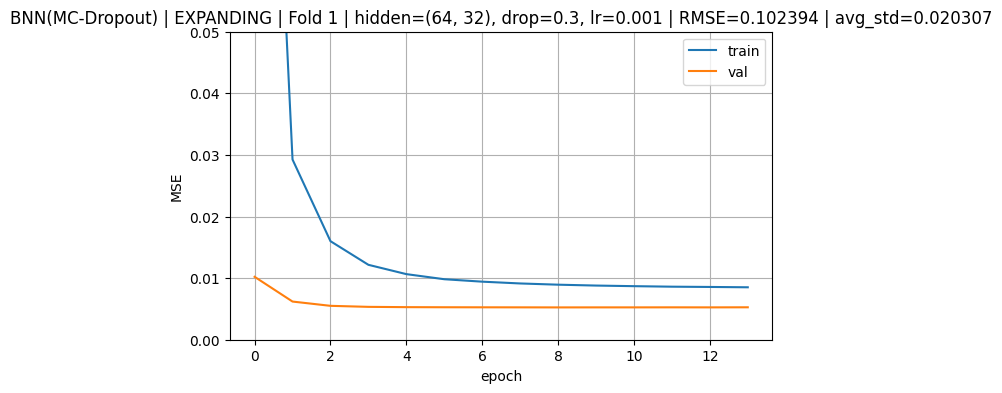

[BNN][expanding] fold 1/5 RMSE=0.102394 | avg_std=0.020307


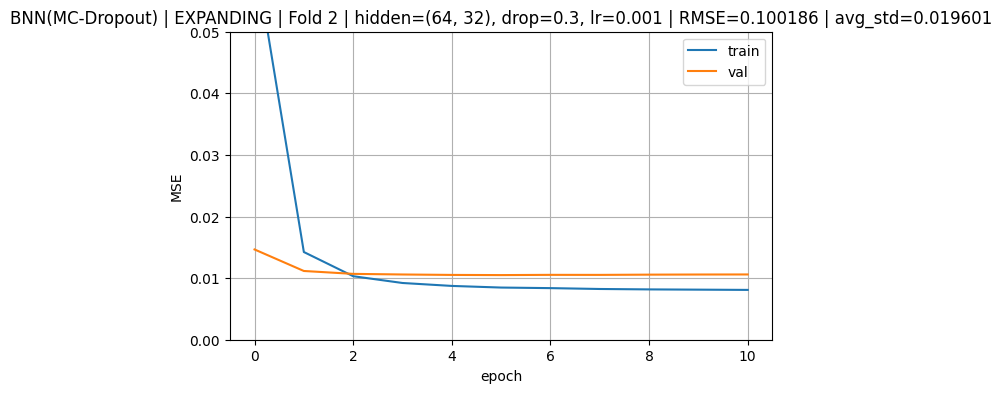

[BNN][expanding] fold 2/5 RMSE=0.100186 | avg_std=0.019601


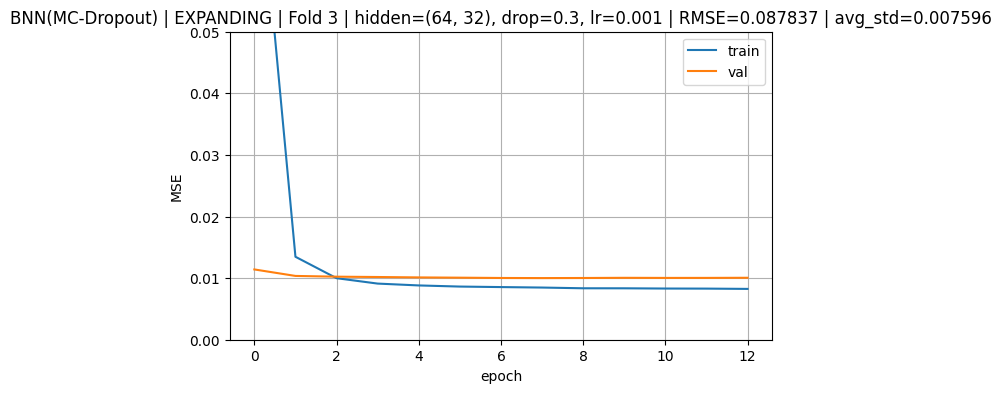

[BNN][expanding] fold 3/5 RMSE=0.087837 | avg_std=0.007596


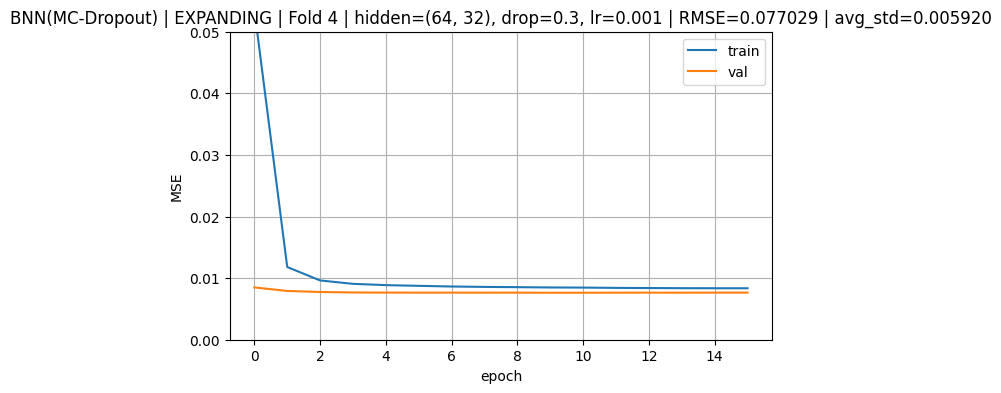

[BNN][expanding] fold 4/5 RMSE=0.077029 | avg_std=0.005920


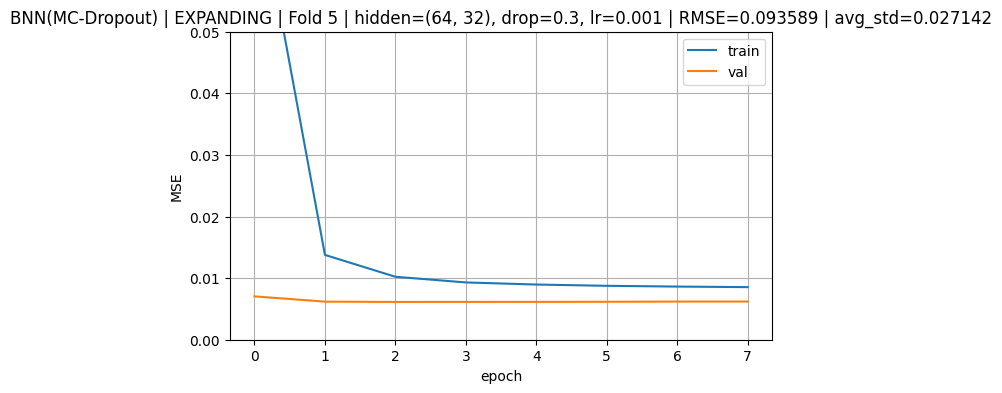

[BNN][expanding] fold 5/5 RMSE=0.093589 | avg_std=0.027142

Summary: BNN expanding


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.102394,0.020307,131556,17721
1,2,0.100186,0.019601,149277,17721
2,3,0.087837,0.007596,166998,17721
3,4,0.077029,0.005920,184719,17834
4,5,0.093589,0.027142,202553,17900


Mean RMSE: 0.09220675570335465 Std RMSE: 0.010232349322981902
Mean avg_pred_std: 0.016112985089421272

BNN RETURN config 2: {'hidden': (128, 64), 'dropout': 0.3, 'lr': 0.001}


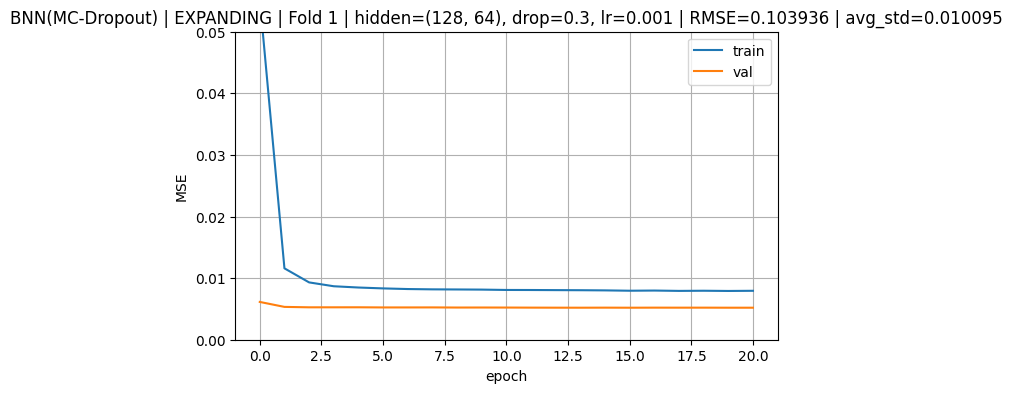

[BNN][expanding] fold 1/5 RMSE=0.103936 | avg_std=0.010095


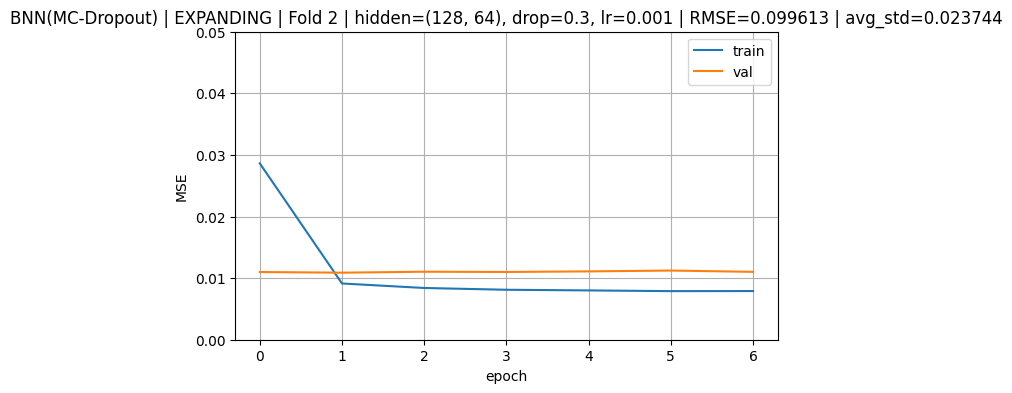

[BNN][expanding] fold 2/5 RMSE=0.099613 | avg_std=0.023744


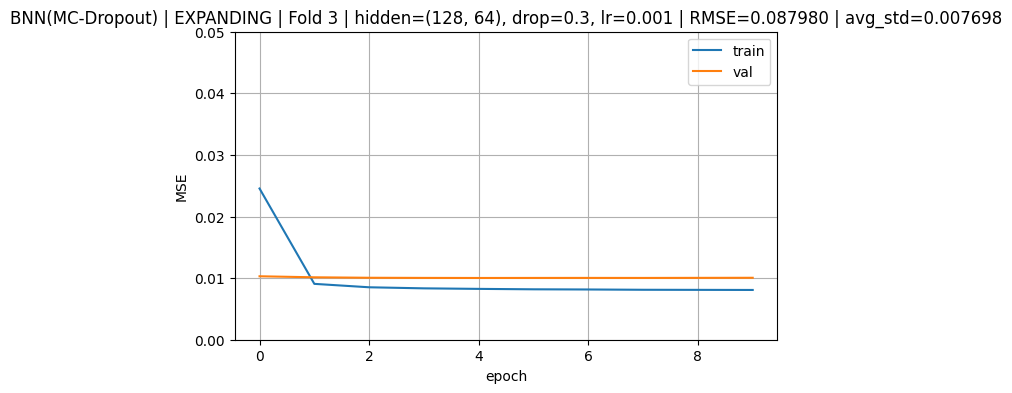

[BNN][expanding] fold 3/5 RMSE=0.087980 | avg_std=0.007698


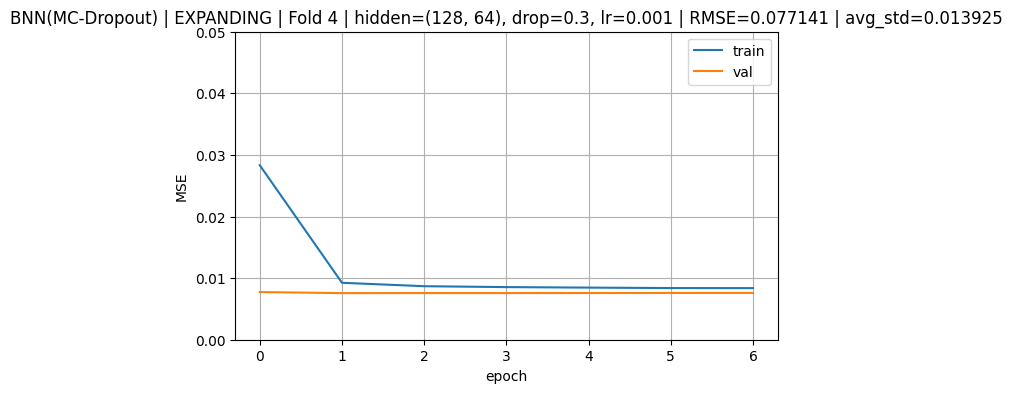

[BNN][expanding] fold 4/5 RMSE=0.077141 | avg_std=0.013925


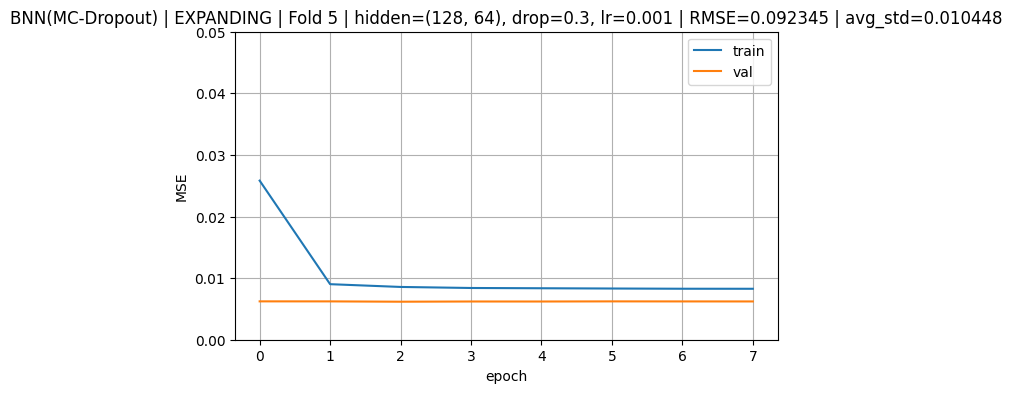

[BNN][expanding] fold 5/5 RMSE=0.092345 | avg_std=0.010448

Summary: BNN expanding


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.103936,0.010095,131556,17721
1,2,0.099613,0.023744,149277,17721
2,3,0.087980,0.007698,166998,17721
3,4,0.077141,0.013925,184719,17834
4,5,0.092345,0.010448,202553,17900


Mean RMSE: 0.09220300955464204 Std RMSE: 0.010455925864310248
Mean avg_pred_std: 0.013181898556649686

BNN RETURN config 3: {'hidden': (64, 64, 32), 'dropout': 0.4, 'lr': 0.0005}


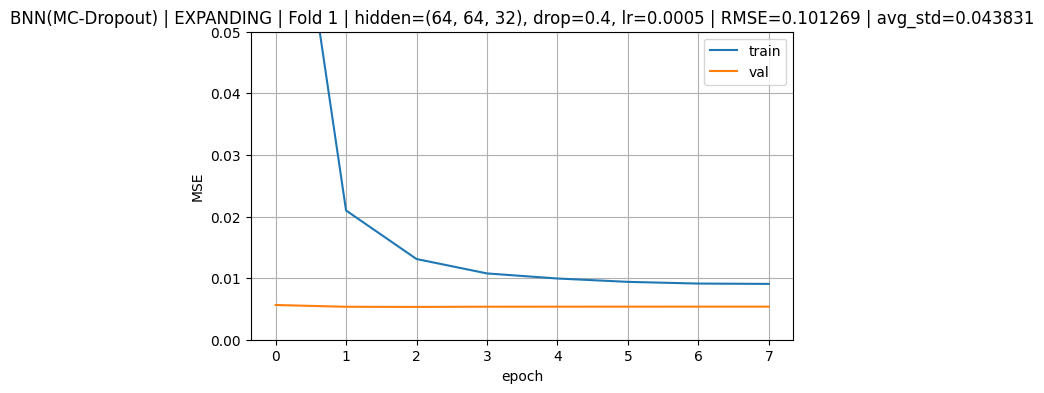

[BNN][expanding] fold 1/5 RMSE=0.101269 | avg_std=0.043831


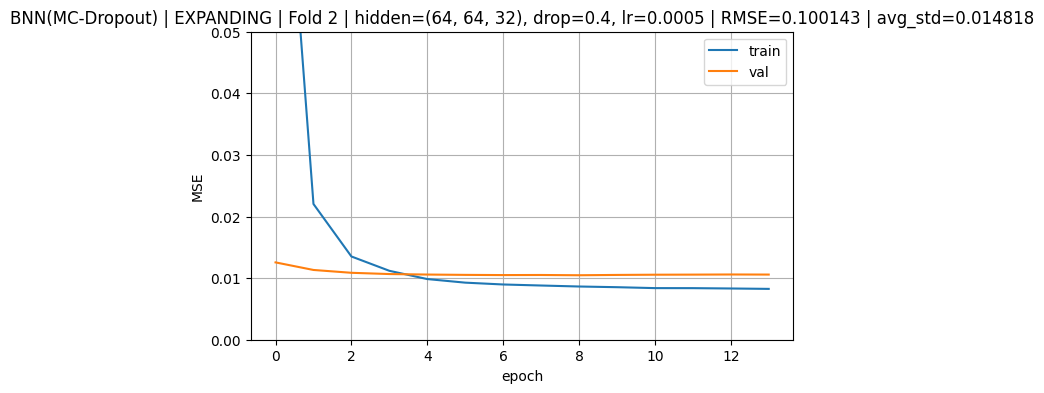

[BNN][expanding] fold 2/5 RMSE=0.100143 | avg_std=0.014818


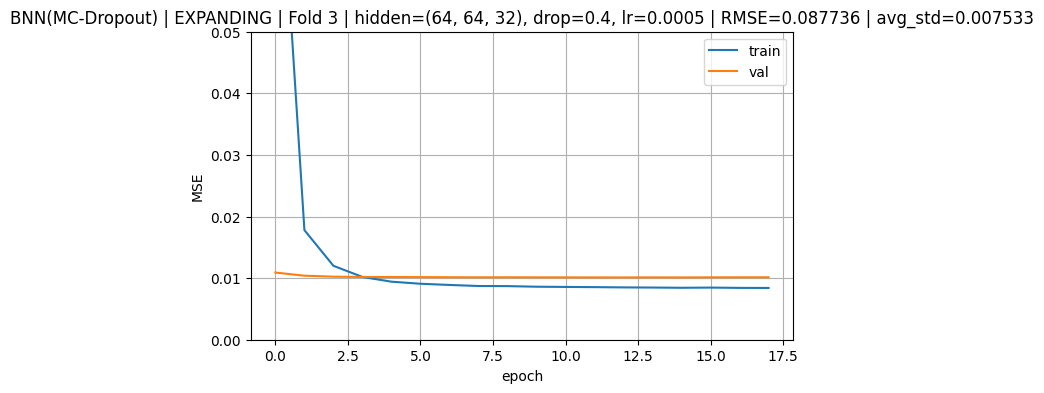

[BNN][expanding] fold 3/5 RMSE=0.087736 | avg_std=0.007533


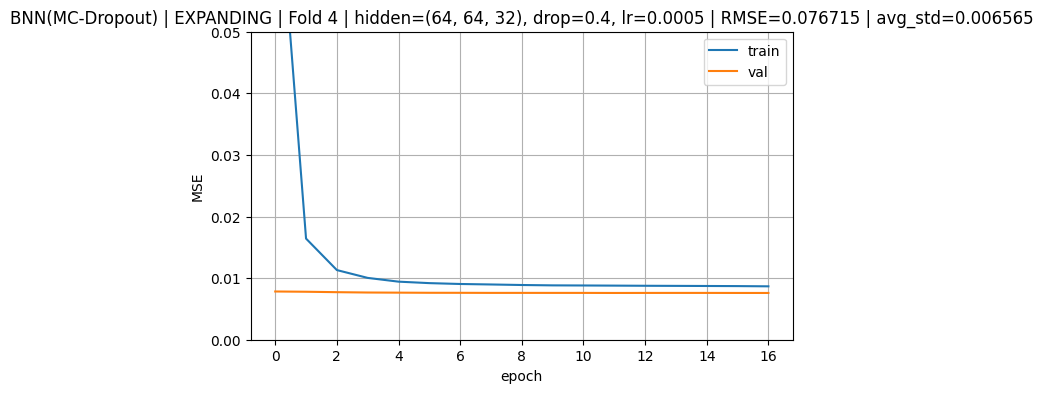

[BNN][expanding] fold 4/5 RMSE=0.076715 | avg_std=0.006565


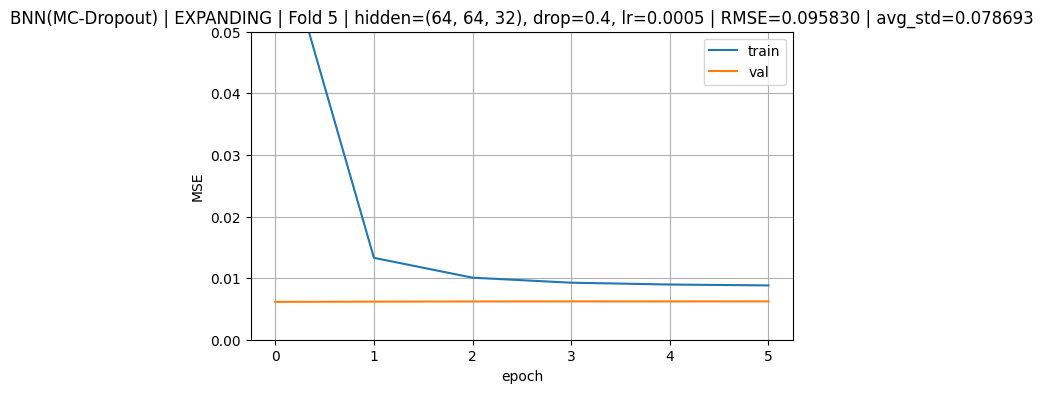

[BNN][expanding] fold 5/5 RMSE=0.095830 | avg_std=0.078693

Summary: BNN expanding


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.101269,0.043831,131556,17721
1,2,0.100143,0.014818,149277,17721
2,3,0.087736,0.007533,166998,17721
3,4,0.076715,0.006565,184719,17834
4,5,0.095830,0.078693,202553,17900


Mean RMSE: 0.0923384772118292 Std RMSE: 0.010224394806601656
Mean avg_pred_std: 0.030288056284189225

=== BNN RETURN Summary (Expanding CV) ===


,config_id,hidden,dropout,lr,mean_rmse,std_rmse,mean_pred_std
1,2,"(128, 64)",0.3,0.0010,0.092203,0.010456,0.013182
0,1,"(64, 32)",0.3,0.0010,0.092207,0.010232,0.016113
2,3,"(64, 64, 32)",0.4,0.0005,0.092338,0.010224,0.030288


In [73]:
# =========================
# BNN on RETURN — Expanding (PRIMARY)
# =========================
bnn_return_results = []
for i, cfg in enumerate(BNN_GRID, start=1):
    print("\n" + "="*90)
    print(f"BNN RETURN config {i}: {cfg}")
    print("="*90)

    df = run_bnn_cv(
        panel_return_clean,
        scheme="expanding",
        n_splits=5,
        hidden=cfg["hidden"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        epochs=50,
        batch_size=1024,
        patience=5,
        seed=42,
        plot_curves=True,
        mc_samples=30
    )

    bnn_return_results.append({
        "config_id": i,
        **cfg,
        "mean_rmse": df["rmse"].mean(),
        "std_rmse": df["rmse"].std(),
        "mean_pred_std": df["avg_pred_std"].mean()
    })

bnn_summary_return = pd.DataFrame(bnn_return_results).sort_values("mean_rmse")
print("\n=== BNN RETURN Summary (Expanding CV) ===")
display(bnn_summary_return)


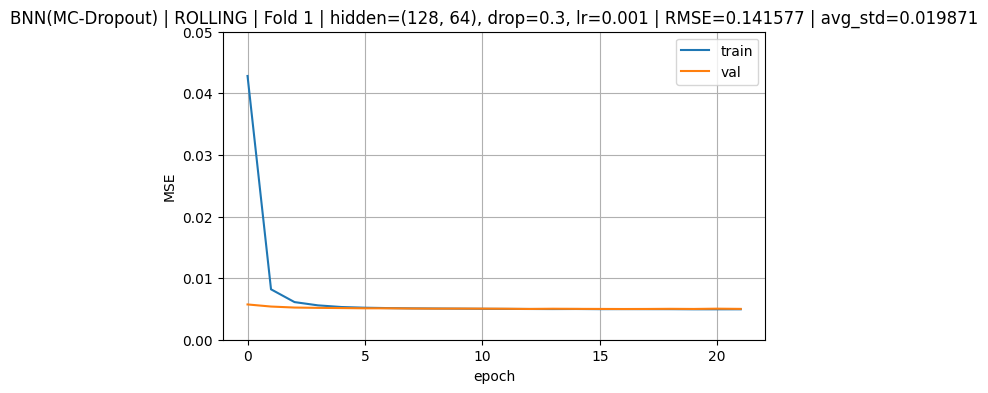

[BNN][rolling] fold 1/5 RMSE=0.141577 | avg_std=0.019871


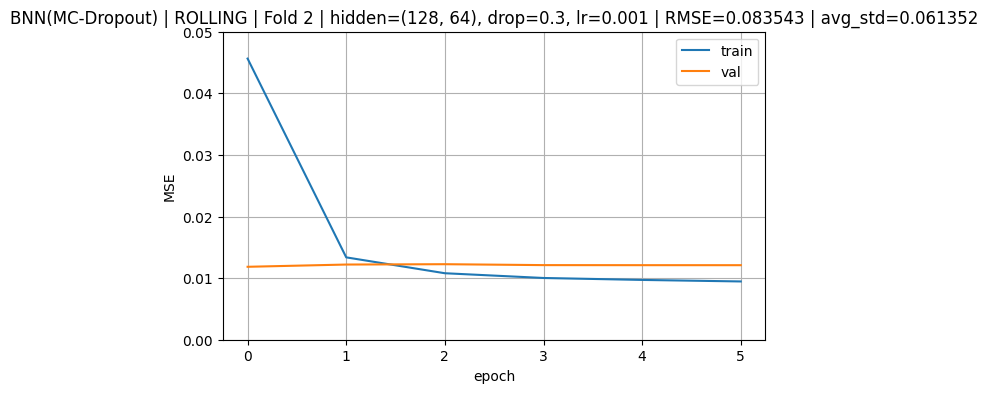

[BNN][rolling] fold 2/5 RMSE=0.083543 | avg_std=0.061352


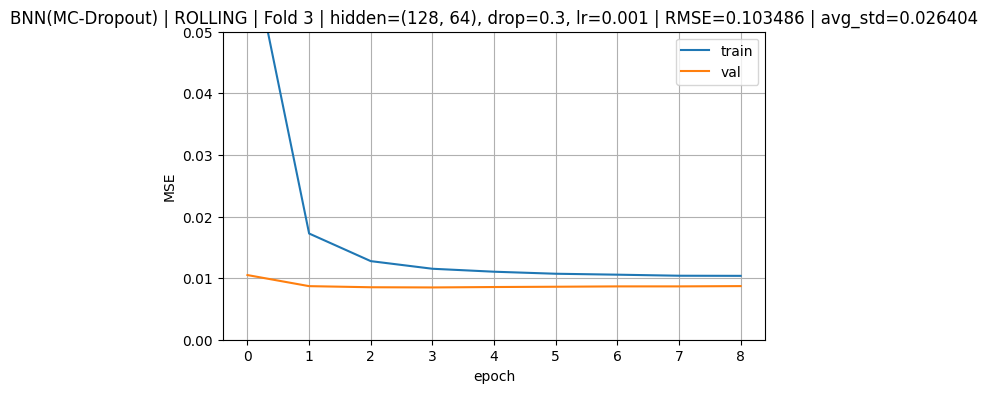

[BNN][rolling] fold 3/5 RMSE=0.103486 | avg_std=0.026404


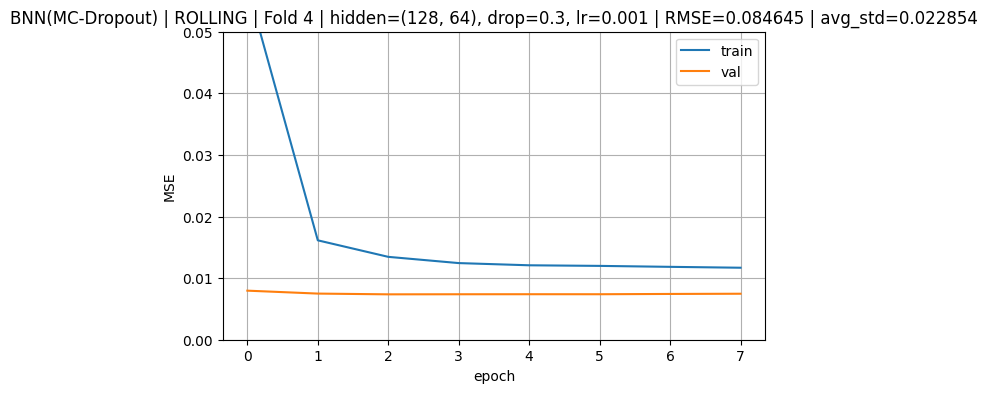

[BNN][rolling] fold 4/5 RMSE=0.084645 | avg_std=0.022854


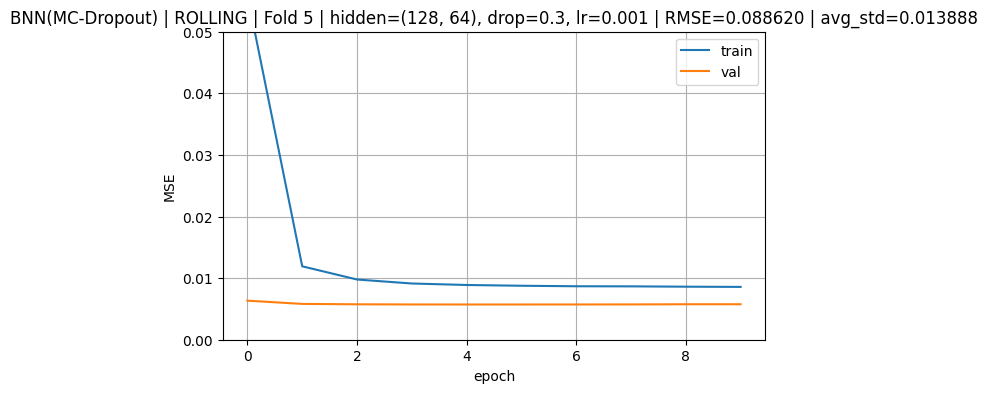

[BNN][rolling] fold 5/5 RMSE=0.088620 | avg_std=0.013888

Summary: BNN rolling


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.141577,0.019871,87428,26407
1,2,0.083543,0.061352,87742,26631
2,3,0.103486,0.026404,88122,26631
3,4,0.084645,0.022854,88391,26656
4,5,0.088620,0.013888,88685,26900


Mean RMSE: 0.10037417905508346 Std RMSE: 0.024373472056569832
Mean avg_pred_std: 0.02887369804084301


In [74]:
# =========================
# BNN on RETURN — Rolling (ROBUSTNESS) using best config
# =========================
best_cfg_return = bnn_summary_return.iloc[0].to_dict()

df_bnn_return_rolling = run_bnn_cv(
    panel_return_clean,
    scheme="rolling",
    n_splits=5,
    hidden=best_cfg_return["hidden"],
    dropout=float(best_cfg_return["dropout"]),
    lr=float(best_cfg_return["lr"]),
    epochs=50,
    batch_size=1024,
    patience=5,
    seed=42,
    plot_curves=True,
    mc_samples=30
)


Run BNN on RISK (Expanding + Rolling)


BNN RISK config 1: {'hidden': (64, 32), 'dropout': 0.3, 'lr': 0.001}


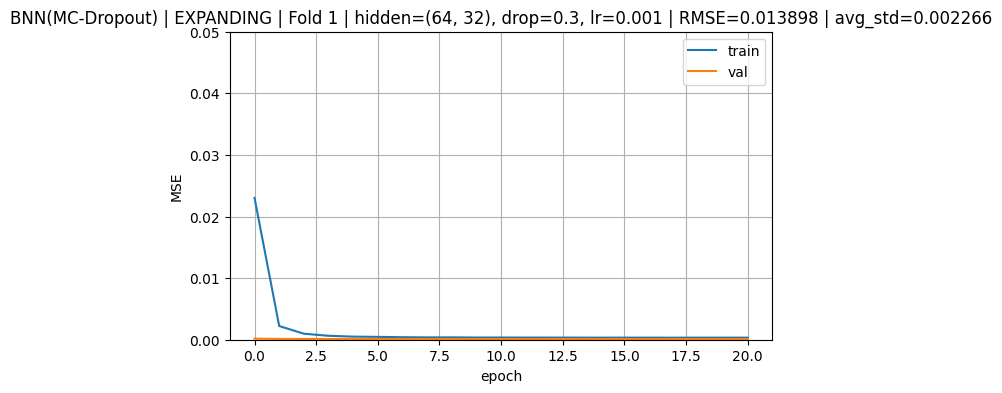

[BNN][expanding] fold 1/5 RMSE=0.013898 | avg_std=0.002266


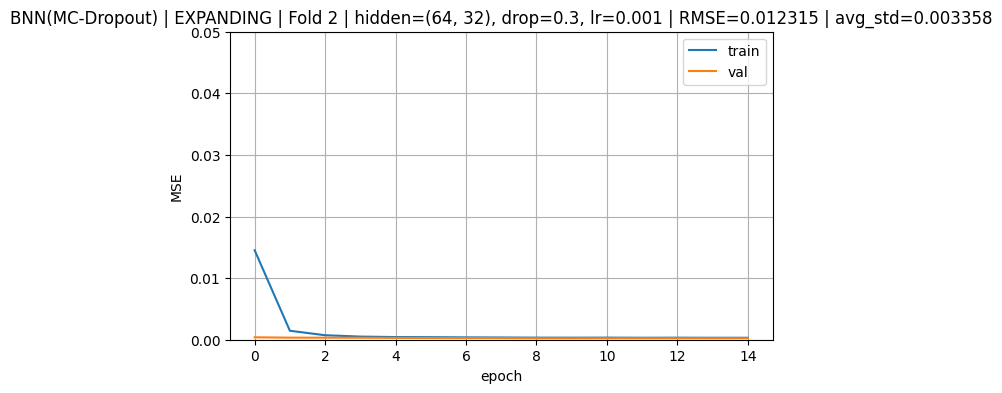

[BNN][expanding] fold 2/5 RMSE=0.012315 | avg_std=0.003358


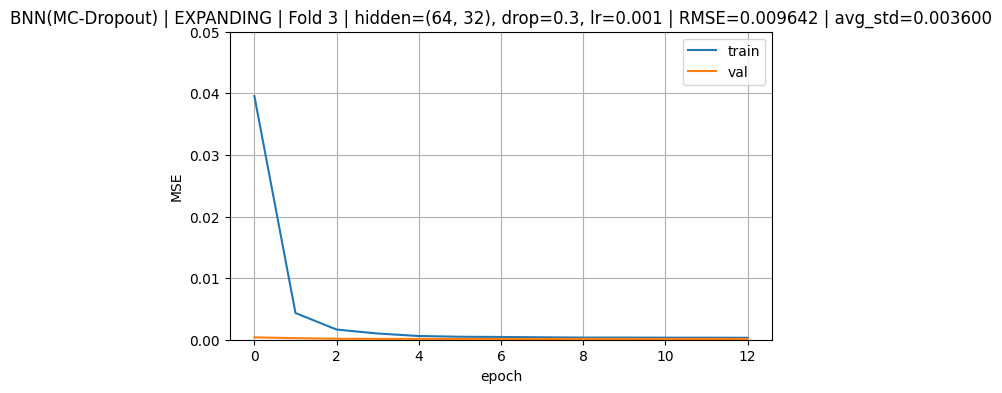

[BNN][expanding] fold 3/5 RMSE=0.009642 | avg_std=0.003600


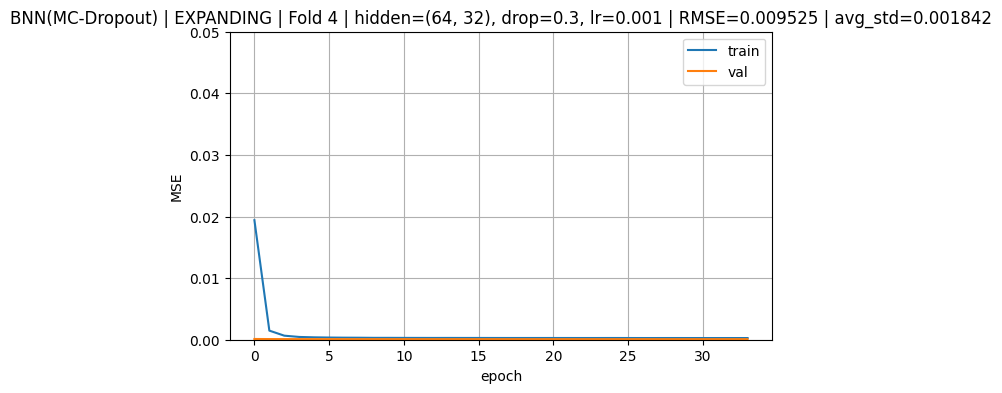

[BNN][expanding] fold 4/5 RMSE=0.009525 | avg_std=0.001842


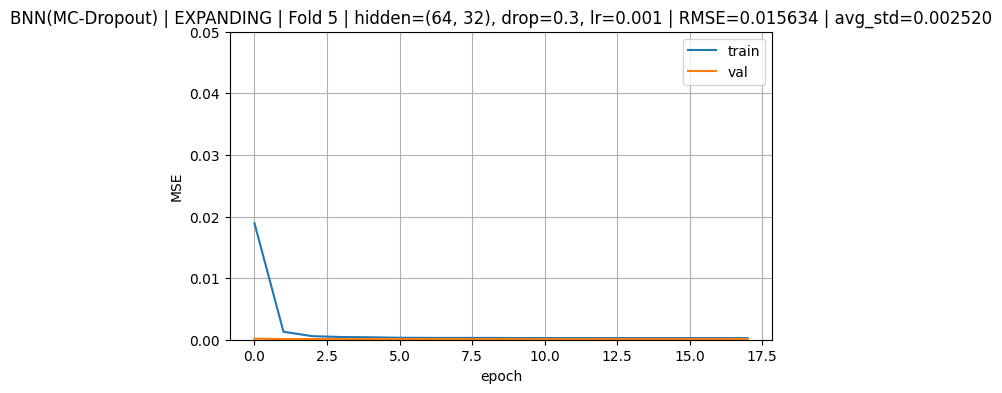

[BNN][expanding] fold 5/5 RMSE=0.015634 | avg_std=0.002520

Summary: BNN expanding


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.013898,0.002266,142000,18900
1,2,0.012315,0.003358,160900,18900
2,3,0.009642,0.003600,179800,18900
3,4,0.009525,0.001842,198700,18900
4,5,0.015634,0.002520,217600,18900


Mean RMSE: 0.01220294653944387 Std RMSE: 0.0026640806156772324
Mean avg_pred_std: 0.00271714988630265

BNN RISK config 2: {'hidden': (128, 64), 'dropout': 0.3, 'lr': 0.001}


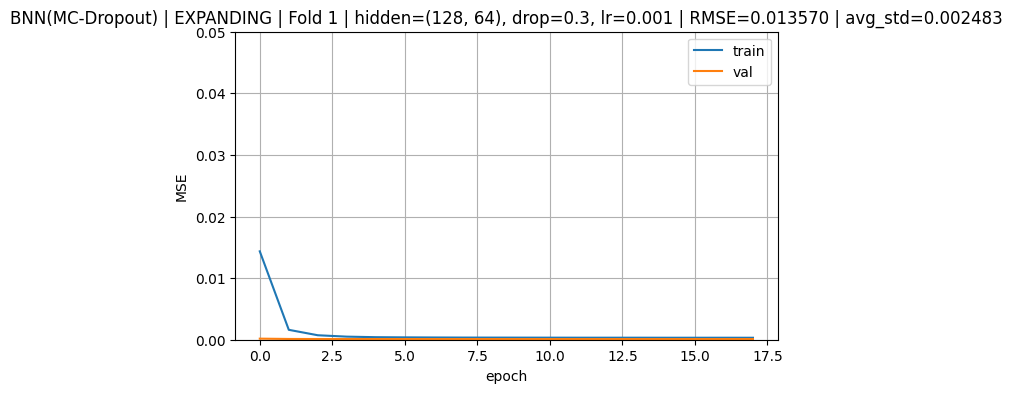

[BNN][expanding] fold 1/5 RMSE=0.013570 | avg_std=0.002483


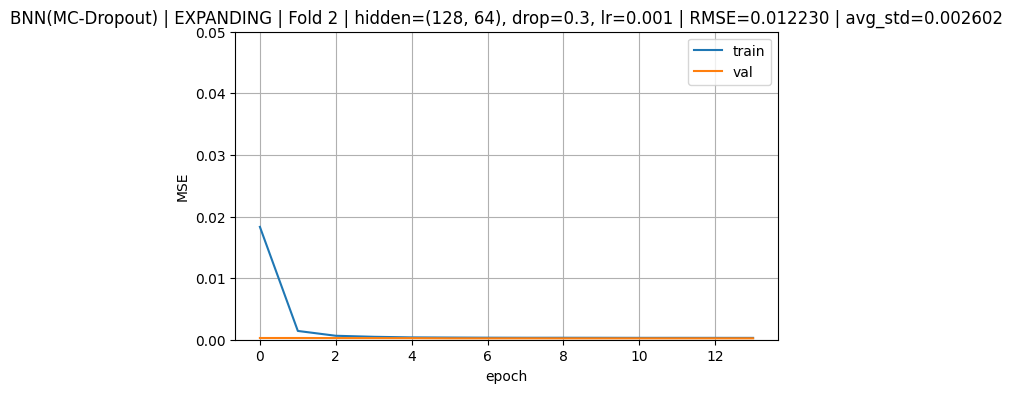

[BNN][expanding] fold 2/5 RMSE=0.012230 | avg_std=0.002602


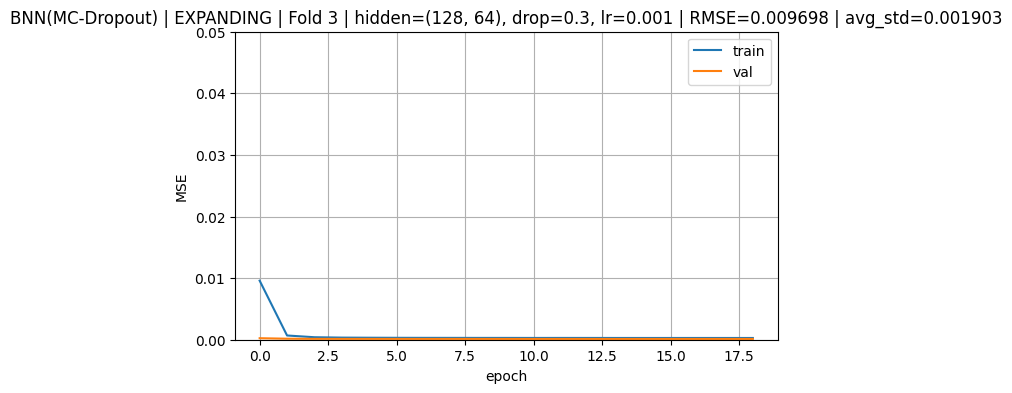

[BNN][expanding] fold 3/5 RMSE=0.009698 | avg_std=0.001903


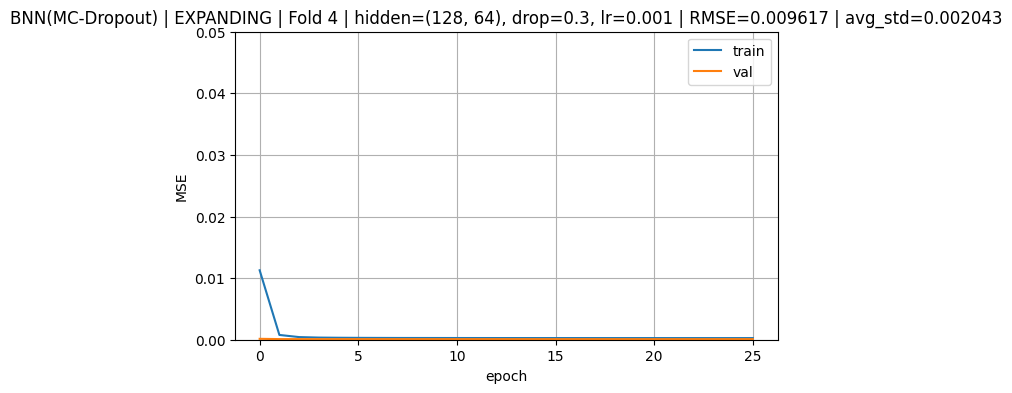

[BNN][expanding] fold 4/5 RMSE=0.009617 | avg_std=0.002043


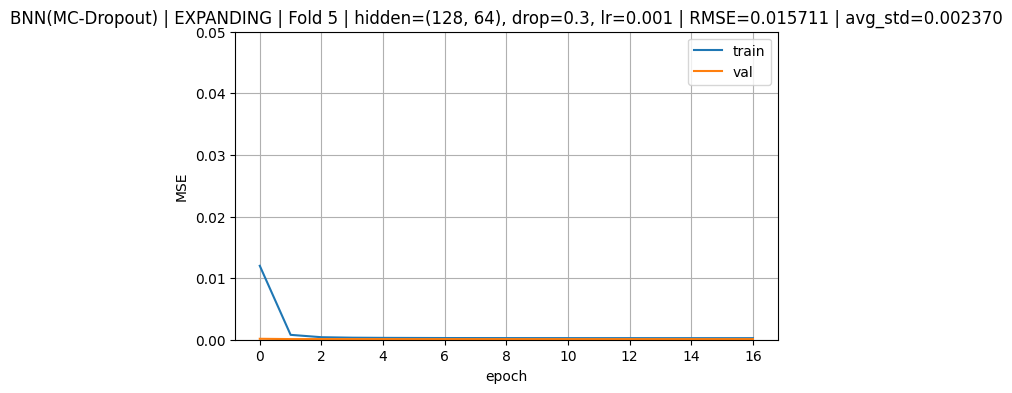

[BNN][expanding] fold 5/5 RMSE=0.015711 | avg_std=0.002370

Summary: BNN expanding


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.013570,0.002483,142000,18900
1,2,0.012230,0.002602,160900,18900
2,3,0.009698,0.001903,179800,18900
3,4,0.009617,0.002043,198700,18900
4,5,0.015711,0.002370,217600,18900


Mean RMSE: 0.012165293330940805 Std RMSE: 0.002604263063320388
Mean avg_pred_std: 0.0022802611580118536

BNN RISK config 3: {'hidden': (64, 64, 32), 'dropout': 0.4, 'lr': 0.0005}


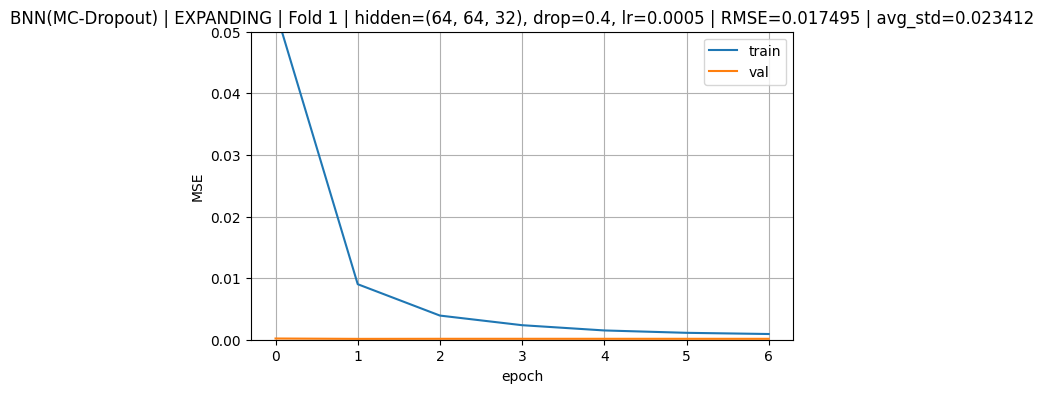

[BNN][expanding] fold 1/5 RMSE=0.017495 | avg_std=0.023412


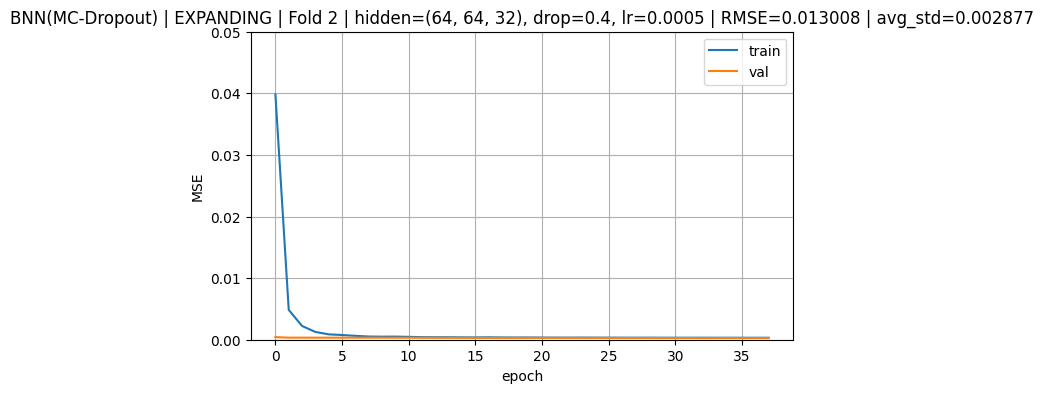

[BNN][expanding] fold 2/5 RMSE=0.013008 | avg_std=0.002877


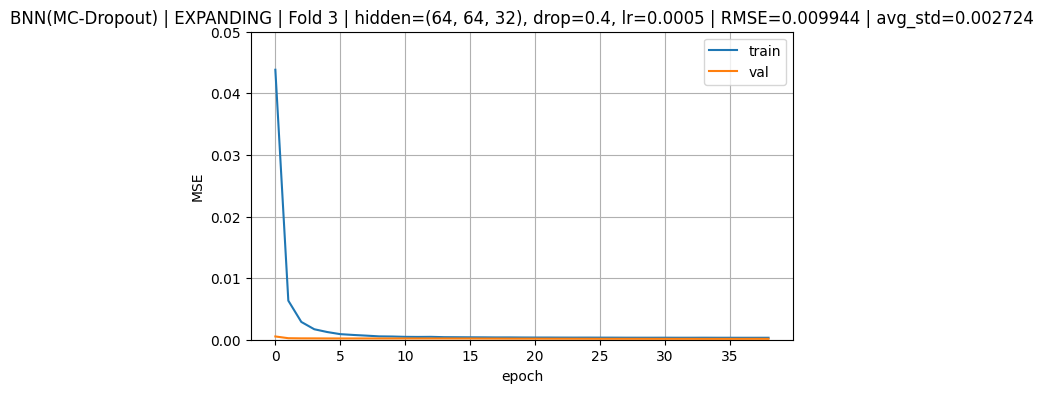

[BNN][expanding] fold 3/5 RMSE=0.009944 | avg_std=0.002724


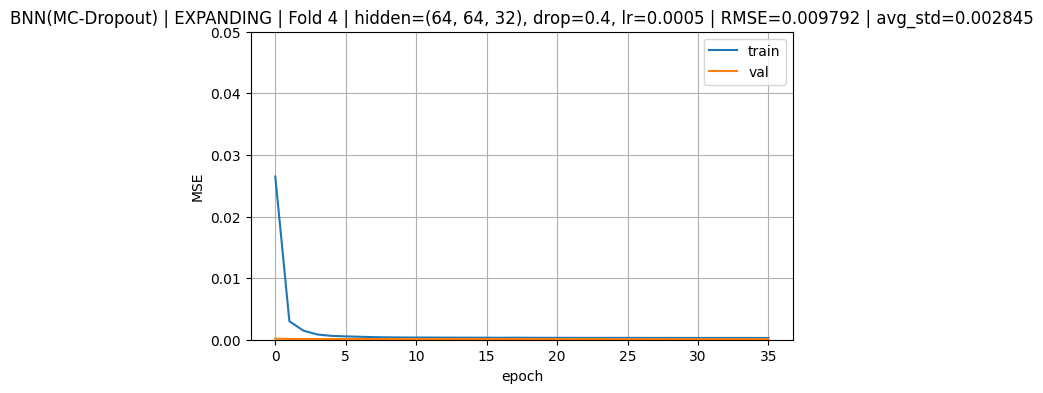

[BNN][expanding] fold 4/5 RMSE=0.009792 | avg_std=0.002845


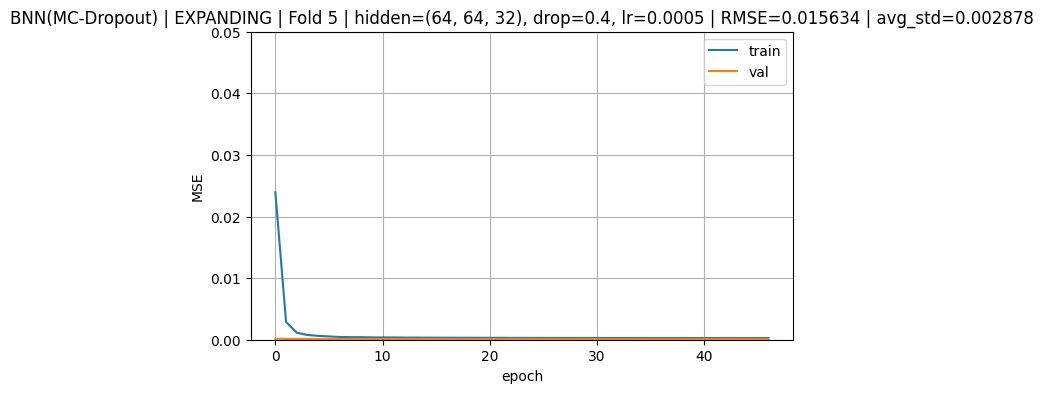

[BNN][expanding] fold 5/5 RMSE=0.015634 | avg_std=0.002878

Summary: BNN expanding


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.017495,0.023412,142000,18900
1,2,0.013008,0.002877,160900,18900
2,3,0.009944,0.002724,179800,18900
3,4,0.009792,0.002845,198700,18900
4,5,0.015634,0.002878,217600,18900


Mean RMSE: 0.013174587675592708 Std RMSE: 0.0034140121953279952
Mean avg_pred_std: 0.006947099976241588

=== BNN RISK Summary (Expanding CV) ===


,config_id,hidden,dropout,lr,mean_rmse,std_rmse,mean_pred_std
1,2,"(128, 64)",0.3,0.0010,0.012165,0.002604,0.002280
0,1,"(64, 32)",0.3,0.0010,0.012203,0.002664,0.002717
2,3,"(64, 64, 32)",0.4,0.0005,0.013175,0.003414,0.006947


In [75]:
# =========================
# BNN on RISK — Expanding (PRIMARY)
# =========================
bnn_risk_results = []
for i, cfg in enumerate(BNN_GRID, start=1):
    print("\n" + "="*90)
    print(f"BNN RISK config {i}: {cfg}")
    print("="*90)

    df = run_bnn_cv(
        panel_risk_clean,
        scheme="expanding",
        n_splits=5,
        hidden=cfg["hidden"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        epochs=50,
        batch_size=1024,
        patience=5,
        seed=42,
        plot_curves=True,
        mc_samples=30
    )

    bnn_risk_results.append({
        "config_id": i,
        **cfg,
        "mean_rmse": df["rmse"].mean(),
        "std_rmse": df["rmse"].std(),
        "mean_pred_std": df["avg_pred_std"].mean()
    })

bnn_summary_risk = pd.DataFrame(bnn_risk_results).sort_values("mean_rmse")
print("\n=== BNN RISK Summary (Expanding CV) ===")
display(bnn_summary_risk)


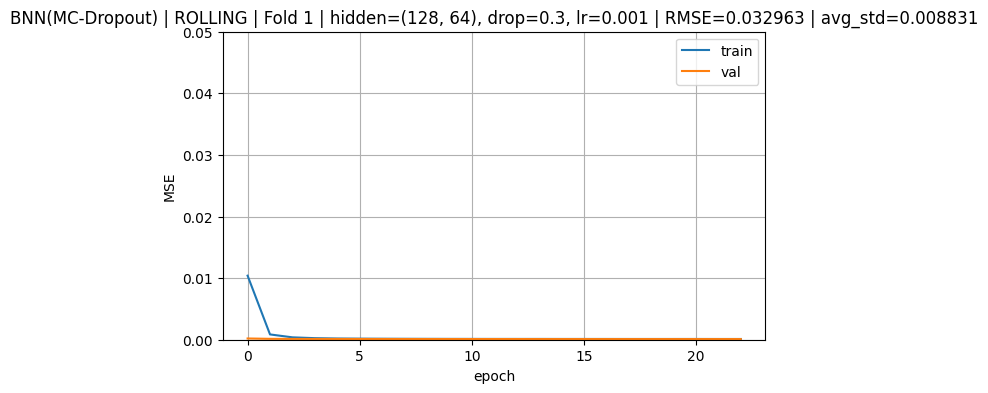

[BNN][rolling] fold 1/5 RMSE=0.032963 | avg_std=0.008831


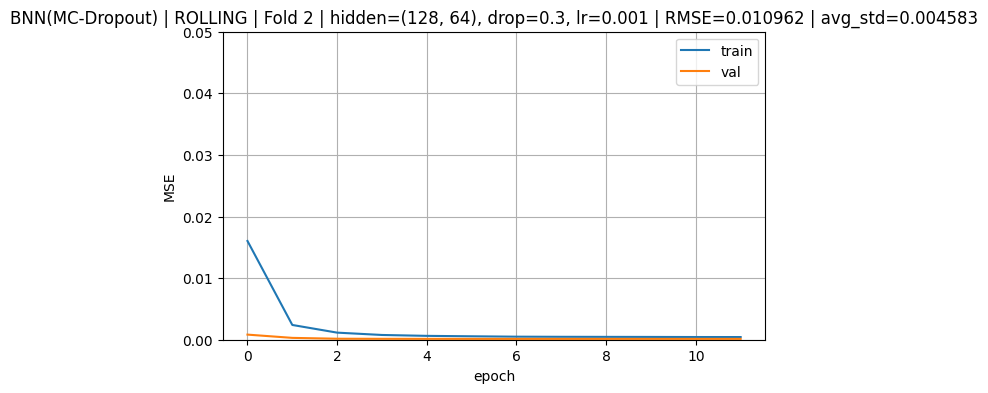

[BNN][rolling] fold 2/5 RMSE=0.010962 | avg_std=0.004583


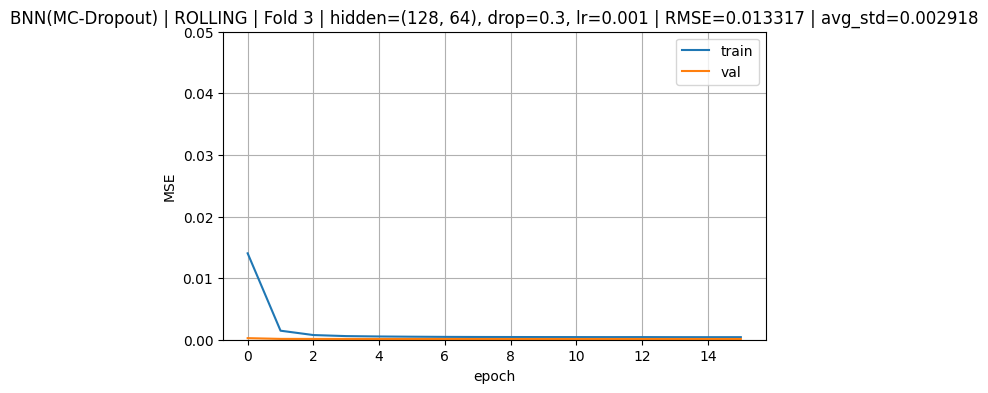

[BNN][rolling] fold 3/5 RMSE=0.013317 | avg_std=0.002918


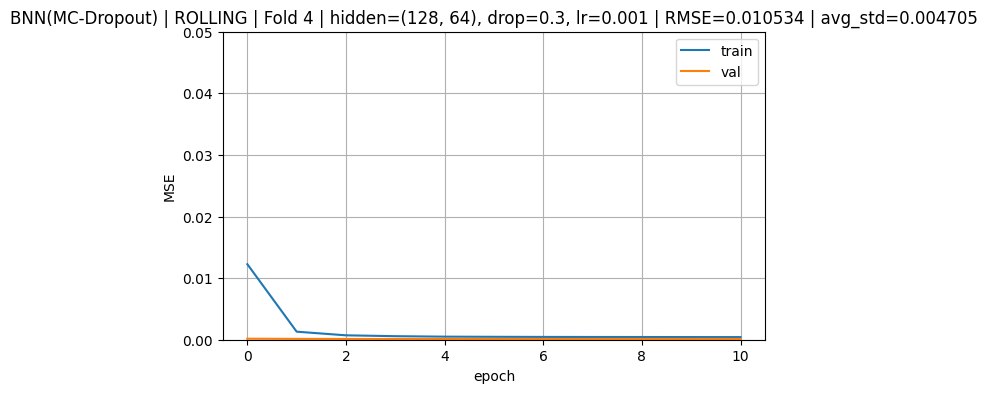

[BNN][rolling] fold 4/5 RMSE=0.010534 | avg_std=0.004705


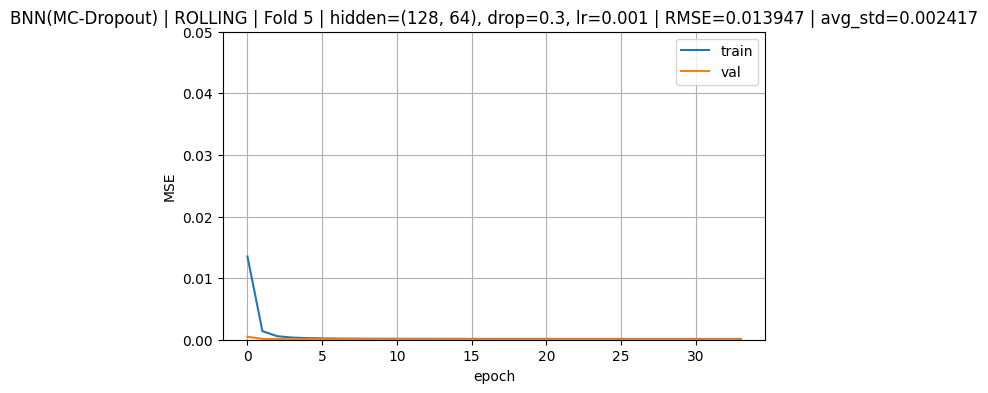

[BNN][rolling] fold 5/5 RMSE=0.013947 | avg_std=0.002417

Summary: BNN rolling


,fold,rmse,avg_pred_std,n_train,n_test
0,1,0.032963,0.008831,94700,28400
1,2,0.010962,0.004583,94700,28400
2,3,0.013317,0.002918,94700,28400
3,4,0.010534,0.004705,94700,28400
4,5,0.013947,0.002417,94700,28400


Mean RMSE: 0.016344483012059756 Std RMSE: 0.009405245248521512
Mean avg_pred_std: 0.0046907332725822926


In [76]:
# =========================
# BNN on RISK — Rolling (ROBUSTNESS) using best config
# =========================
best_cfg_risk = bnn_summary_risk.iloc[0].to_dict()

df_bnn_risk_rolling = run_bnn_cv(
    panel_risk_clean,
    scheme="rolling",
    n_splits=5,
    hidden=best_cfg_risk["hidden"],
    dropout=float(best_cfg_risk["dropout"]),
    lr=float(best_cfg_risk["lr"]),
    epochs=50,
    batch_size=1024,
    patience=5,
    seed=42,
    plot_curves=True,
    mc_samples=30
)
